# Entrenamiento de Modelos — MFCCs Aumentados Diarizados

Versión del notebook que utiliza los datos diarizados aumentados ( / ).

In [4]:
import pickle
import numpy as np
import pandas as pd

#Tablas y Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Modelos
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import PredefinedSplit
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

In [5]:
ruta_train = '../datos_entrenamiento/train_mfcc_chunked_aumentado_diarizado.pkl'
ruta_test = '../datos_entrenamiento/test_mfcc_chunked_aumentado_diarizado.pkl'

datos_train = pickle.load(open(ruta_train, 'rb'))
datos_test = pickle.load(open(ruta_test, 'rb'))

df_train = pd.DataFrame(datos_train)
df_test = pd.DataFrame(datos_test)

print("Forma del Dataset de entrenamiento:", df_train.shape)
print()
print("Encontrar datos nulos --->", df_train.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_train.isnull().any().any())

print("Forma del Dataset de test:", df_test.shape)
print()
print("Encontrar datos nulos --->", df_test.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_test.isnull().any().any())

Forma del Dataset de entrenamiento: (1692, 5)

Encontrar datos nulos ---> nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False
Forma del Dataset de test: (78, 5)

Encontrar datos nulos ---> nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False


In [6]:
df_train.head()

,nombre_archivo,mfccs,caja_toracica,grupo,fold
0,Nueva grabación 35_chunk000_original.wav,"[[-509.01492, -486.2265, -471.39362, -478.1155...",Mixto,Oxigeno Bajo Flujo,4
1,Nueva grabación 35_chunk000_noise.wav,"[[-436.23666, -393.16245, -400.73334, -401.104...",Mixto,Oxigeno Bajo Flujo,4
2,Nueva grabación 35_chunk000_pitch.wav,"[[-505.59192, -474.11838, -464.56128, -457.322...",Mixto,Oxigeno Bajo Flujo,4
3,Nueva grabación 35_chunk000_stretch.wav,"[[-516.53595, -492.094, -474.74338, -478.84897...",Mixto,Oxigeno Bajo Flujo,4
4,Nueva grabación 35_chunk001_original.wav,"[[-458.3255, -471.12286, -474.46725, -450.0719...",Mixto,Oxigeno Bajo Flujo,4


Al igual que en el notebook de datos chunkeados, todas las entradas tienen la misma dimensionalidad de entrada gracias al preprocesado previo (segmentación a 10 segundos y padding aplicado al time stretch para garantizar uniformidad). Las muestras aumentadas conservan la misma forma MFCC que las originales: **(30 coeficientes × 1001 frames)**.

## Extracción Características

Al igual que en el notebook anterior, necesitamos transformar las matrices MFCC (30 × 1001) en vectores unidimensionales para poder trabajar con modelos clásicos de ML. Aplicaremos las dos mismas estrategias:

- **Mean+Std pooling**: comprime cada muestra en 60 características (30 medias + 30 desviaciones típicas). Mitiga la maldición de la dimensionalidad y es la representación más robusta para datasets de tamaño moderado.
- **Flatten completo**: genera ~30.030 características por muestra. Con 4296 muestras la relación muestras/características mejora significativamente respecto al notebook anterior, aunque sigue siendo necesario aplicar reducción agresiva (PCA o SelectKBest).

In [10]:
def generar_datasets_aplanados(df):
    metadatos = df[['nombre_archivo', 'grupo', 'caja_toracica', 'fold']]
    n_mfcc = df['mfccs'].iloc[0].shape[0]

    # Dataset 1: Mean + Std (60 features)
    medias = pd.DataFrame(
        df['mfccs'].apply(lambda x: np.mean(x, axis=1)).tolist(),
        columns=[f'mfcc_media_{i+1}' for i in range(n_mfcc)],
        index=df.index
    )
    stds = pd.DataFrame(
        df['mfccs'].apply(lambda x: np.std(x, axis=1)).tolist(),
        columns=[f'mfcc_std_{i+1}' for i in range(n_mfcc)],
        index=df.index
    )
    df_pooling = pd.concat([metadatos, medias, stds], axis=1)

    # Dataset 2: Flatten completo (~30k features)
    df_flatten_features = pd.DataFrame(
        df['mfccs'].apply(lambda x: x.flatten()).tolist(),
        index=df.index
    )
    df_flatten = pd.concat([metadatos, df_flatten_features], axis=1)

    return df_pooling, df_flatten

df_train_pool, df_train_flat = generar_datasets_aplanados(df_train)
df_test_pool, df_test_flat = generar_datasets_aplanados(df_test)

In [11]:
print(f"Shape Train Plano: {df_train_flat.shape} + Shape Test Plano: {df_test_flat.shape}")
print(f"Shape Train Pooleado: {df_train_pool.shape} + Shape Test Pooleado: {df_test_pool.shape}")

Shape Train Plano: (1692, 30034) + Shape Test Plano: (78, 30034)
Shape Train Pooleado: (1692, 64) + Shape Test Pooleado: (78, 64)


#### PCA en FLAT

A diferencia del notebook de datos aumentados no diarizados (donde el PCA era inviable con ~4.296 muestras), este dataset diarizado aumentado cuenta con 1.692 muestras de entrenamiento — aproximadamente una cuarta parte. Con 1.692 × 30.030 la descomposición SVD es tratable en un tiempo razonable. Aplicamos PCA como alternativa no supervisada a SelectKBest y comparamos los resultados.

In [18]:
columnas_a_quitar_pca = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

scaler_pca = StandardScaler()
subset_X = df_train_flat.drop(columns=columnas_a_quitar_pca)
df_train_flat_transformed = scaler_pca.fit_transform(subset_X)

pca_full = PCA()
pca_full.fit_transform(df_train_flat_transformed)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
print(cumulative_variance)

[0.02924865 0.05348195 0.07641526 ... 0.99998707 1.0000002  1.0000002 ]


In [19]:
n_components_base = df_train_flat.drop(columns=columnas_a_quitar_pca).shape[1]
print(f"Nº Componentes de base: {n_components_base}")
n_components_95 = np.argmax(cumulative_variance >= 0.95)
print(f"Componentes necesarios para explicar el 95%: {n_components_95}")
n_components_90 = np.argmax(cumulative_variance >= 0.90)
print(f"Componentes necesarios para explicar el 90%: {n_components_90}")
n_components_88 = np.argmax(cumulative_variance >= 0.88)
print(f"Componentes necesarios para explicar el 88%: {n_components_88}")
n_components_85 = np.argmax(cumulative_variance >= 0.85)
print(f"Componentes necesarios para explicar el 85%: {n_components_85}")
n_components_80 = np.argmax(cumulative_variance >= 0.80)
print(f"Componentes necesarios para explicar el 80%: {n_components_80}")
n_components_75 = np.argmax(cumulative_variance >= 0.75)
print(f"Componentes necesarios para explicar el 75%: {n_components_75}")

Nº Componentes de base: 30030
Componentes necesarios para explicar el 95%: 1139
Componentes necesarios para explicar el 90%: 943
Componentes necesarios para explicar el 88%: 877
Componentes necesarios para explicar el 85%: 788
Componentes necesarios para explicar el 80%: 662
Componentes necesarios para explicar el 75%: 556


Podemos observar como, pese a reducir en cierta medida el % de varianza, nos seguimos encontrando con un gran número de predictores. Lo idóneo, teniendo en cuenta la cantidad de muestras (1692), sería intentar reducir el nº de componentes a unos 125-150 predictores. Seguirá aun así siendo una gran cantidad de predictores, que puede que lleve a cierto sobreentrenamiento, o en un mejor caso, solo nos lleve a un entrenamiento con elevado coste computacional, sin embargo, este número de características representa una relación muestras/predictores que puede ser útil.

Vamos a observar con que % de varianza nos debemos quedar si queremos quedarnos con 125 o 150 componentes principales:

In [26]:
print(f"Varianza explicada con 125 componentes: {cumulative_variance[125]:.4f}")

print(f"Varianza explicada con 150 componentes: {cumulative_variance[150]:.4f}")

Varianza explicada con 125 componentes: 0.3997
Varianza explicada con 150 componentes: 0.4322


Lo mejor en este caso para pdoer alcanzar esta relación de un número moderado de muestras por características (unas 10 muestras/predictor), sin perder una cantidad enorme de información podría ser en sí quedarnos con aquellos componentes que representen el 45 % de varianza

In [29]:
X_train_num_pca = df_train_flat.drop(columns=columnas_a_quitar_pca)
X_test_num_pca = df_test_flat.drop(columns=columnas_a_quitar_pca)

scaler_flat = StandardScaler()
X_train_scaled_pca = scaler_flat.fit_transform(X_train_num_pca)
X_test_scaled_pca = scaler_flat.transform(X_test_num_pca)

n_componentes = 0.45 #Nos quedamos con el 45% de la varianza
pca = PCA(n_components=n_componentes, random_state=42)
X_train_pca_flat = pca.fit_transform(X_train_scaled_pca)
X_test_pca_flat = pca.transform(X_test_scaled_pca)

n_componentes_finales = X_train_pca_flat.shape[1]
print(f"El PCA ha seleccionado {n_componentes_finales} componentes principales.")

df_pca_train_flat = pd.DataFrame(
    X_train_pca_flat,
    columns=[f'MFCC_flat_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_train_flat.index
)
df_train_flat_1 = pd.concat([df_train_flat[columnas_a_quitar_pca], df_pca_train_flat], axis=1)

df_pca_test_flat = pd.DataFrame(
    X_test_pca_flat,
    columns=[f'MFCC_flat_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_test_flat.index
)
df_test_flat_1 = pd.concat([df_test_flat[columnas_a_quitar_pca], df_pca_test_flat], axis=1)

print("\nVista previa del conjunto de ENTRENAMIENTO post-pca:")
display(df_train_flat_1.head())

El PCA ha seleccionado 166 componentes principales.

Vista previa del conjunto de ENTRENAMIENTO post-pca:


,nombre_archivo,grupo,caja_toracica,fold,MFCC_flat_pca1,MFCC_flat_pca2,MFCC_flat_pca3,MFCC_flat_pca4,MFCC_flat_pca5,MFCC_flat_pca6,...,MFCC_flat_pca157,MFCC_flat_pca158,MFCC_flat_pca159,MFCC_flat_pca160,MFCC_flat_pca161,MFCC_flat_pca162,MFCC_flat_pca163,MFCC_flat_pca164,MFCC_flat_pca165,MFCC_flat_pca166
0,Nueva grabación 35_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,4,-7.742688,1.198244,-26.681009,4.414736,-0.309552,20.205666,...,-2.018397,-3.103582,-6.645500,5.700214,0.061376,2.329355,4.063972,0.589700,-0.859714,-5.388236
1,Nueva grabación 35_chunk000_noise.wav,Oxigeno Bajo Flujo,Mixto,4,-48.051250,-12.774197,-23.882090,0.302426,-10.174494,18.680281,...,-2.674404,-3.420150,-3.729606,4.679378,-0.742588,1.654966,3.210537,-0.105425,-0.919790,-5.045808
2,Nueva grabación 35_chunk000_pitch.wav,Oxigeno Bajo Flujo,Mixto,4,-6.357975,8.217407,-26.957108,-0.350121,2.154485,23.063473,...,3.185071,-3.044784,4.283280,5.839399,-1.975723,4.256164,4.784974,-3.094934,-0.241793,-5.617579
3,Nueva grabación 35_chunk000_stretch.wav,Oxigeno Bajo Flujo,Mixto,4,3.481118,4.807693,-42.585812,-3.158017,-17.863821,0.564543,...,-3.363497,1.382587,-5.450723,-0.092450,0.060681,0.952478,4.421395,-4.297861,1.741891,-2.241579
4,Nueva grabación 35_chunk001_original.wav,Oxigeno Bajo Flujo,Mixto,4,15.669702,14.172396,-27.550407,5.990135,7.444017,16.713472,...,2.224705,0.917987,-0.416485,4.366357,6.253522,-7.575727,2.305488,-0.732595,4.544973,6.657008


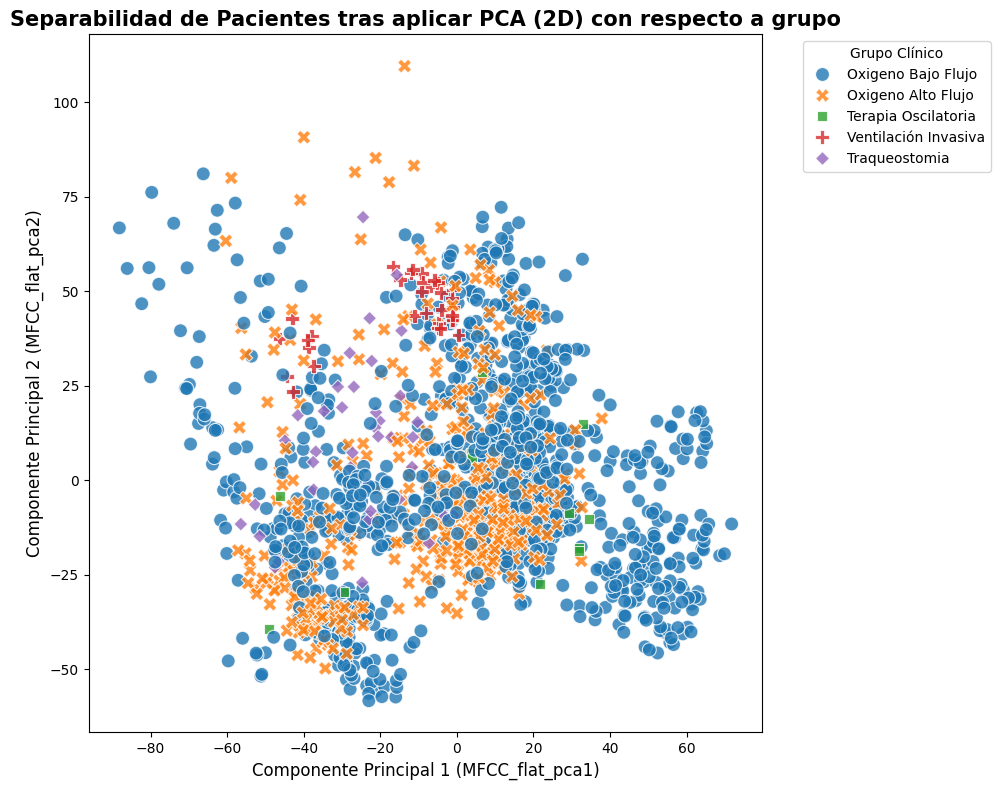

In [30]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_train_flat_1,
    x='MFCC_flat_pca1',
    y='MFCC_flat_pca2',
    hue='grupo',
    style='grupo',
    s=100,
    alpha=0.8
)
plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a grupo', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_flat_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_flat_pca2)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Grupo Clínico')
plt.tight_layout()
plt.show()

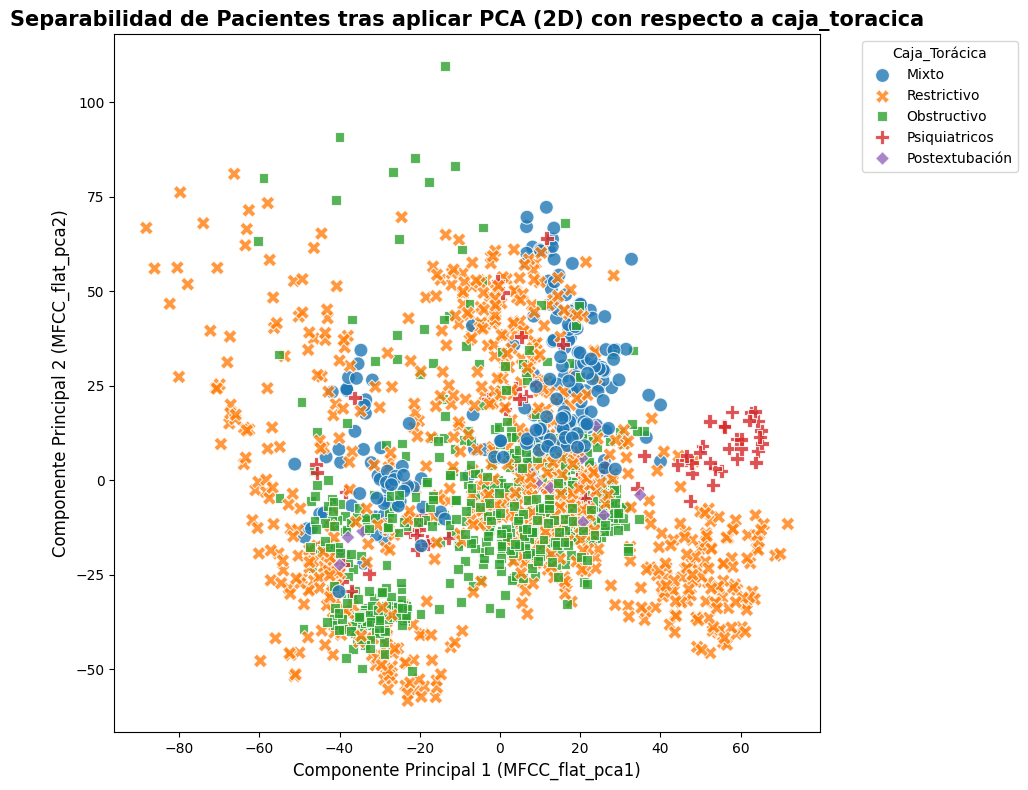

In [31]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_train_flat_1,
    x='MFCC_flat_pca1',
    y='MFCC_flat_pca2',
    hue='caja_toracica',
    style='caja_toracica',
    s=100,
    alpha=0.8
)
plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a caja_toracica', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_flat_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_flat_pca2)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Caja_Torácica')
plt.tight_layout()
plt.show()

Con estos gráficos de dispersión buscamos representar cada chunk como un punto en un gráfico de coordenadas, teniendo en cuenta los valores de MFCC_flat_pca1 y MFCC_flat_pca2. Los 2 primeros componentes principales de un PCA son aquellas que agrupan mayor cantidad de información (varianza). En ambos gráficos podemos observar que no hay nubes de puntos claramente separadas.

En este caso podemos observar que los datos presentan una extrema complejidad acústica. El nivel de solapamiento entre las clases de mayor volumen confirma que los diferentes grupos y patologías no son linealmente separables utilizando únicamente sus dos componentes de mayor varianza.

Sin embargo, esta misma densidad de puntos contiene patrones subyacentes valiosos. Aunque a nivel global observemos una gran mezcla, la concentración de datos sugiere que en el espacio multidimensional del PCA existen vecindarios muy poblados de chunks. La existencia de estas densidades locales justifica el uso, de nuevo, de modelos como K-Nearest Neighbors (KNN).

#### Entrenamiento Modelos Flat con PCA

Para este caso aplicaremos modelos básicos como SVM, RF o LightGBM sobre los datos procesados con PCA. Como hemos observado, los datos no presentan separación lineal clara usando las dos primeras componentes. Esperamos resultados moderados que compararemos con SelectKBest.

In [37]:
def evaluar_modelo_pca_flat(grid_grupo, grid_caja, nombre_modelo):
    print(f"Mejores Hiperparámetros para Grupo Clínico: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros para Torácica: {grid_caja.best_params_}")

    pred_grupo = grid_grupo.predict(X_test_pca_model)
    pred_caja = grid_caja.predict(X_test_pca_model)

    acc_grupo = accuracy_score(y_test_grupo_pca, pred_grupo)
    f1_grupo = f1_score(y_test_grupo_pca, pred_grupo, average='macro', zero_division=0)
    print(f"GRUPOS -> Accuracy: {acc_grupo*100:.2f}% | F1-Score (Macro): {f1_grupo*100:.2f}%")

    acc_caja = accuracy_score(y_test_caja_pca, pred_caja)
    f1_caja = f1_score(y_test_caja_pca, pred_caja, average='macro', zero_division=0)
    print(f"CAJA TORÁCICA -> Accuracy: {acc_caja*100:.2f}% | F1-Score (Macro): {f1_caja*100:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Matrices de Confusión - {nombre_modelo}', fontsize=16, fontweight='bold')

    cm_grupo = confusion_matrix(y_test_grupo_pca, pred_grupo, labels=grid_grupo.classes_)
    sns.heatmap(cm_grupo, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=grid_grupo.classes_, yticklabels=grid_grupo.classes_)
    axes[0].set_title('Predicción: Grupo Clínico')
    axes[0].set_ylabel('Etiqueta Real')
    axes[0].set_xlabel('Predicción')
    axes[0].tick_params(axis='x', rotation=45)

    cm_caja = confusion_matrix(y_test_caja_pca, pred_caja, labels=grid_caja.classes_)
    sns.heatmap(cm_caja, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=grid_caja.classes_, yticklabels=grid_caja.classes_)
    axes[1].set_title('Predicción: Caja Torácica')
    axes[1].set_ylabel('Etiqueta Real')
    axes[1].set_xlabel('Predicción')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [39]:
columnas_pca = [col for col in df_train_flat_1.columns if 'pca' in col]

X_train_pca_model = df_train_flat_1[columnas_pca]
X_test_pca_model = df_test_flat_1[columnas_pca]

y_train_grupo_pca = df_train_flat_1['grupo']
y_test_grupo_pca = df_test_flat_1['grupo']

y_train_caja_pca = df_train_flat_1['caja_toracica']
y_test_caja_pca = df_test_flat_1['caja_toracica']

folds_pca = df_train_flat_1['fold'].values
ps_pca = PredefinedSplit(test_fold=folds_pca)

##### Random Forest

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 55.13% | F1-Score (Macro): 30.57%
CAJA TORÁCICA -> Accuracy: 51.28% | F1-Score (Macro): 37.15%


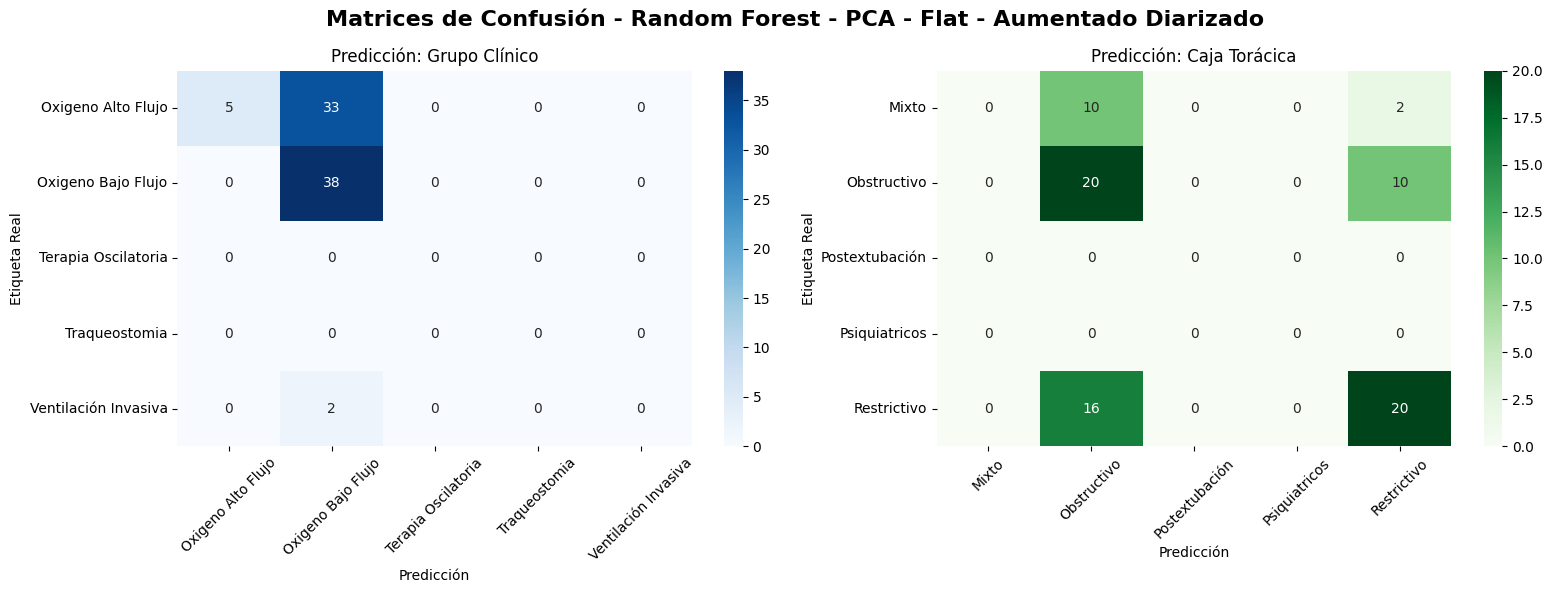

In [42]:
param_grid_rf_pca = {
    'n_estimators': [100],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_grupo.fit(X_train_pca_model, y_train_grupo_pca)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 53.85% | F1-Score (Macro): 30.92%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 36.25%


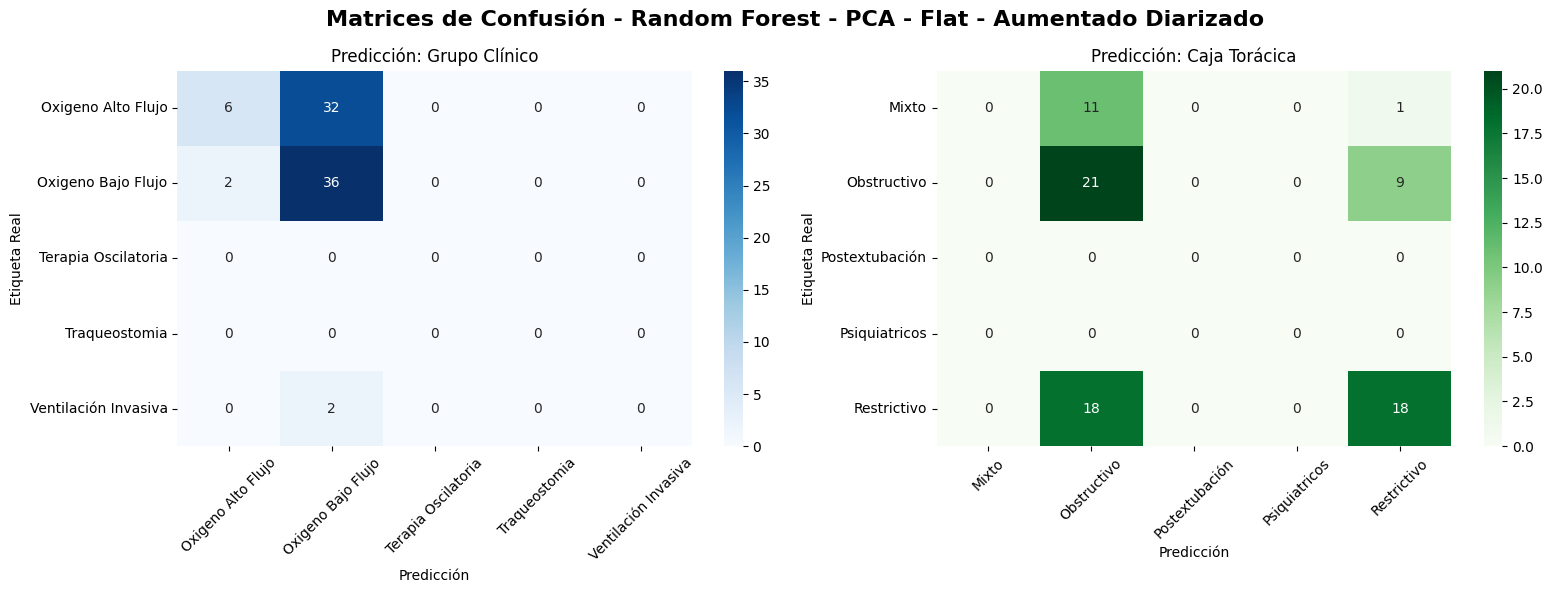

In [43]:
param_grid_rf_1_pca = {
    'n_estimators': [100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_grupo.fit(X_train_pca_model, y_train_grupo_pca)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 200}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 200}
GRUPOS -> Accuracy: 56.41% | F1-Score (Macro): 33.75%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 36.55%


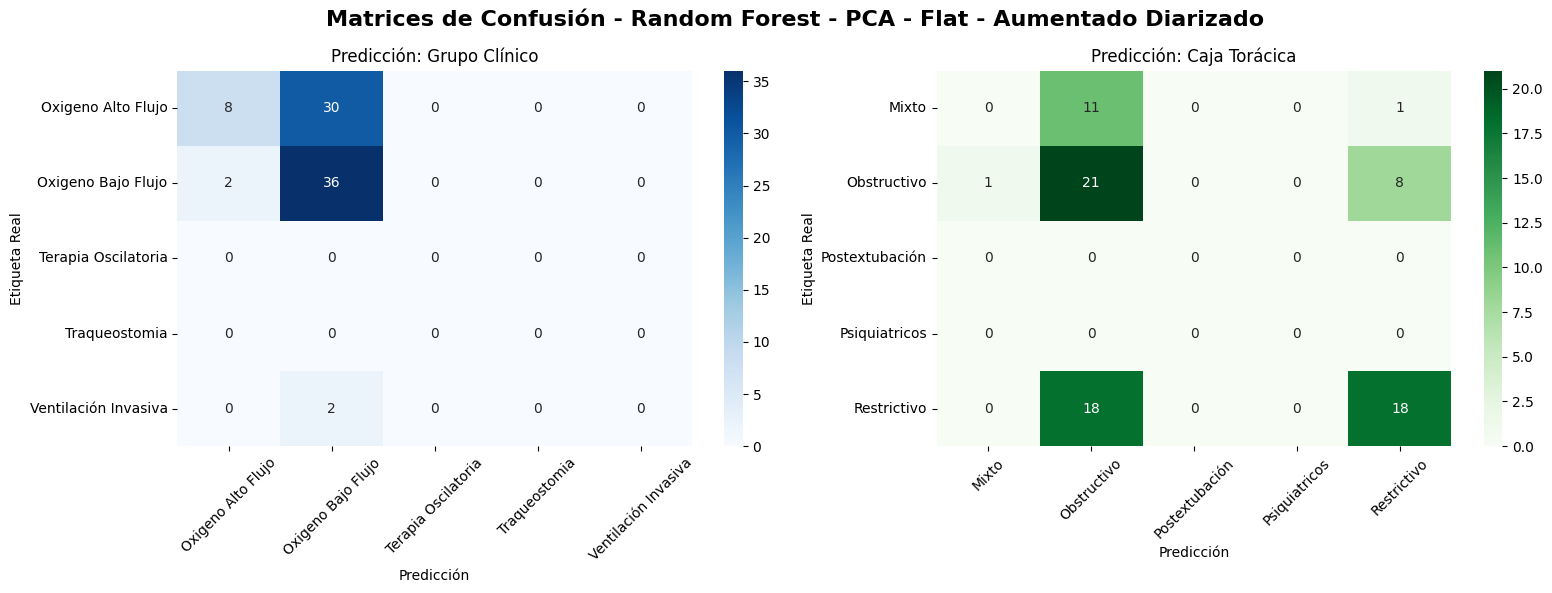

In [46]:
param_grid_rf_2_pca = {
    'n_estimators': [100, 200],
    'max_depth': [None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 6],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_grupo.fit(X_train_pca_model, y_train_grupo_pca)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 300}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 300}
GRUPOS -> Accuracy: 57.69% | F1-Score (Macro): 35.10%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 38.37%


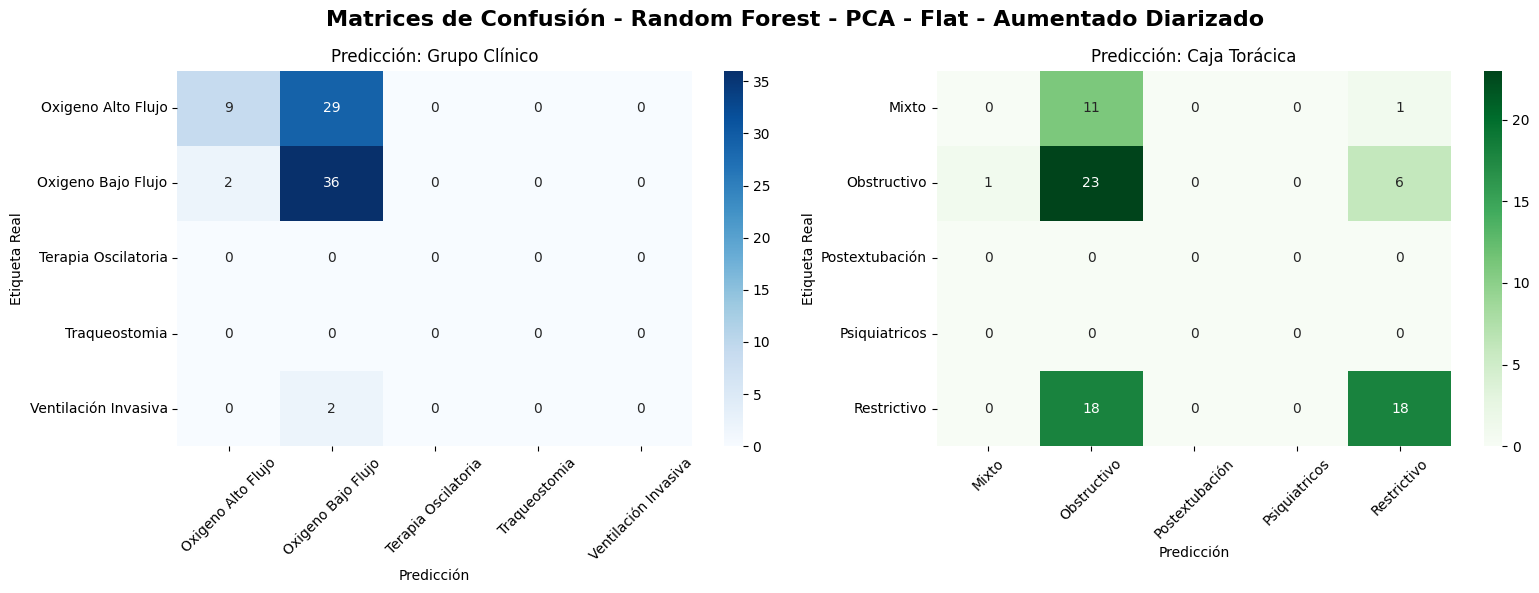

In [48]:
param_grid_rf_3_pca = {
    'n_estimators': [200, 300],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [6, 8],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}


rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_3_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_grupo.fit(X_train_pca_model, y_train_grupo_pca)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_3_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 350}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 350}
GRUPOS -> Accuracy: 70.51% | F1-Score (Macro): 46.48%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 27.64%


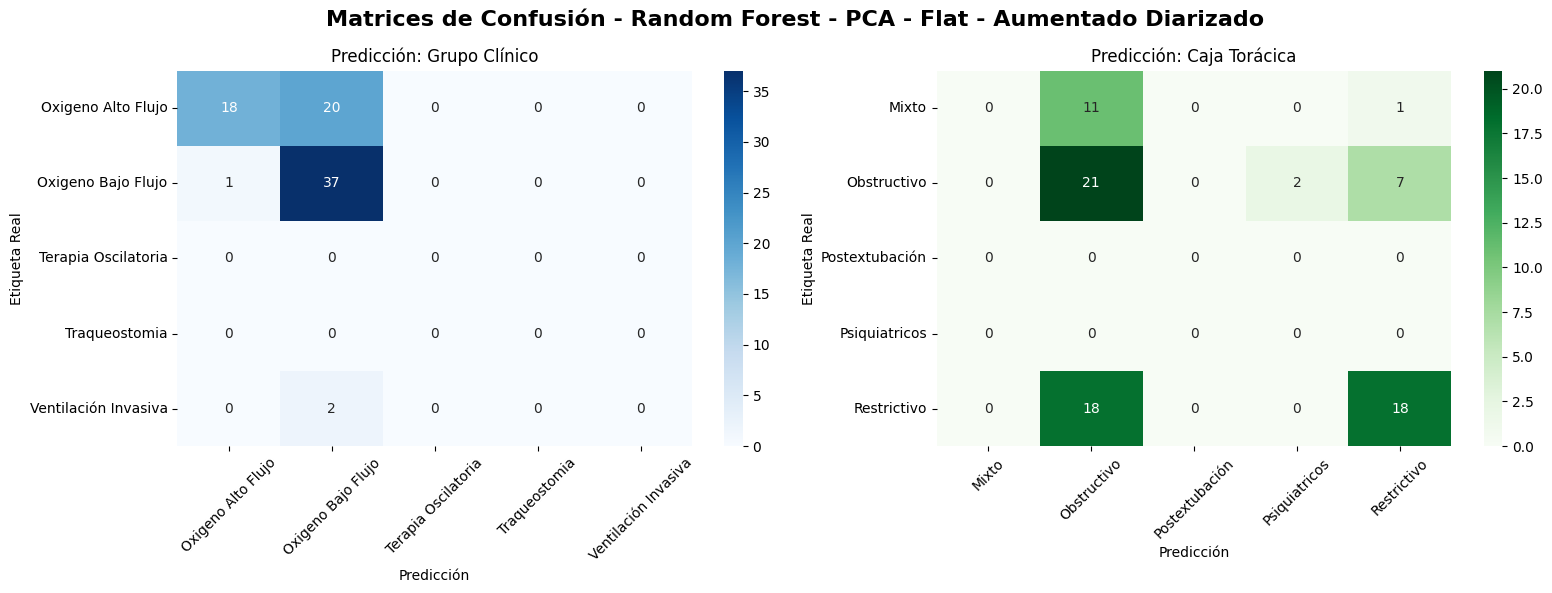

In [50]:
param_grid_rf_4_pca = {
    'n_estimators': [200, 300, 350],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [8, 10],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}


rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_4_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_grupo.fit(X_train_pca_model, y_train_grupo_pca)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_4_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 400}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 300}
GRUPOS -> Accuracy: 71.79% | F1-Score (Macro): 47.53%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 38.37%


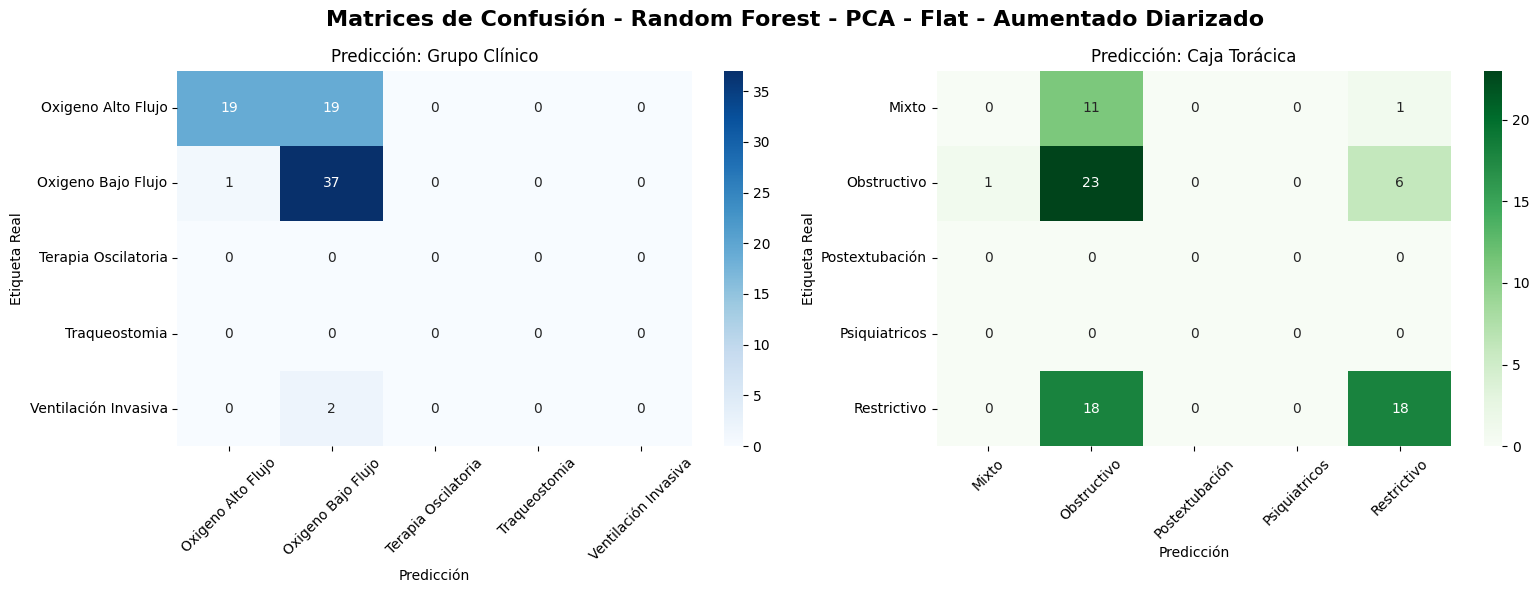

In [54]:
param_grid_rf_5_grupo_pca = {
    'n_estimators': [300, 350, 400],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [10, 12],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

param_grid_rf_5_caja_pca = {
    'n_estimators': [300, 350, 400],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [6, 12],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_5_grupo_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_grupo.fit(X_train_pca_model, y_train_grupo_pca)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_5_caja_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 400}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 300}
GRUPOS -> Accuracy: 71.79% | F1-Score (Macro): 47.53%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 38.37%


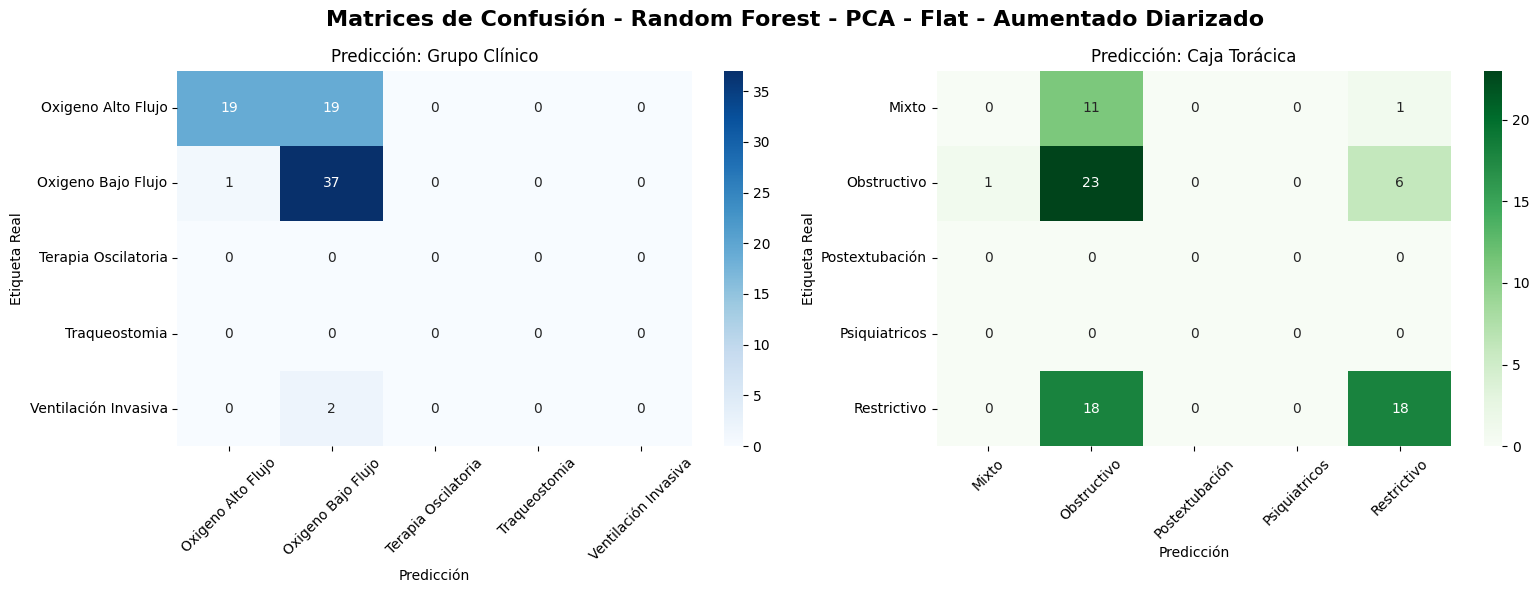

In [56]:
param_grid_rf_final_grupo_pca = {
    'n_estimators': [400],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [10],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

param_grid_rf_final_caja_pca = {
    'n_estimators': [300],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [6],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_grupo.fit(X_train_pca_model, y_train_grupo_pca)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_rf_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

##### SVM

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 55.13% | F1-Score (Macro): 28.21%
CAJA TORÁCICA -> Accuracy: 55.13% | F1-Score (Macro): 40.53%


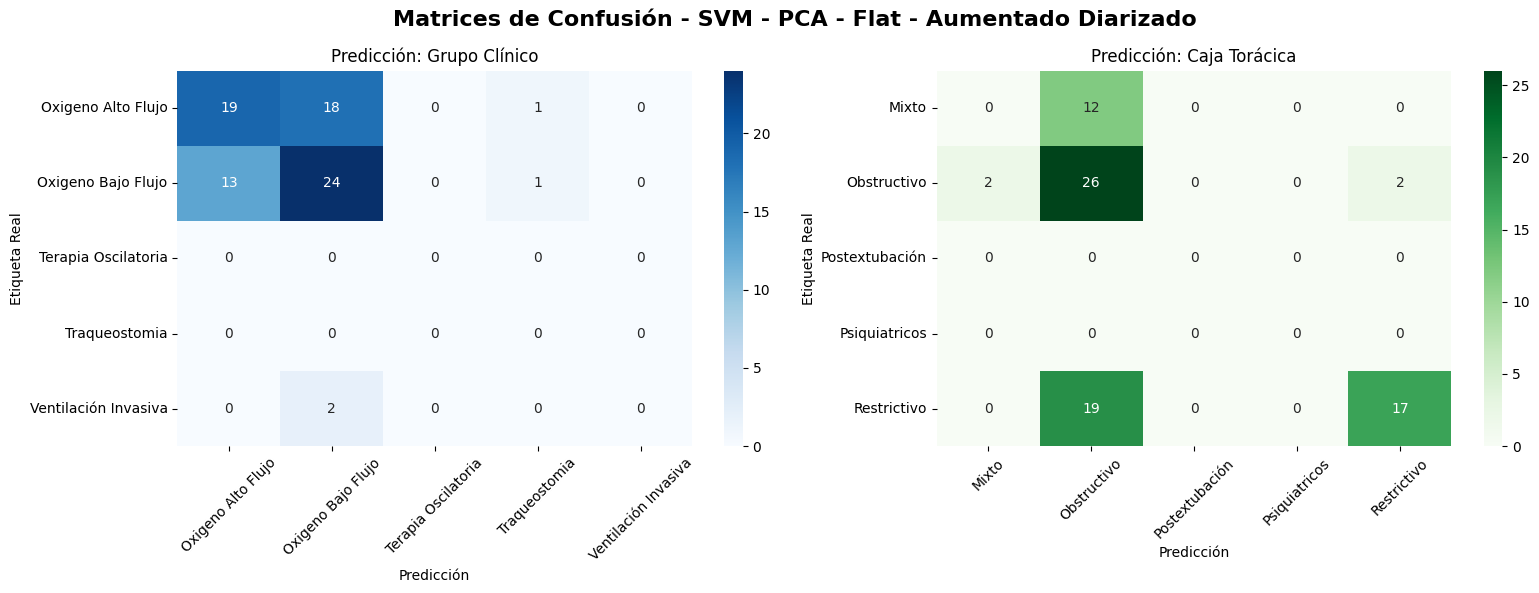

In [58]:
param_grid_svm_pca = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 57.69% | F1-Score (Macro): 29.13%
CAJA TORÁCICA -> Accuracy: 55.13% | F1-Score (Macro): 40.53%


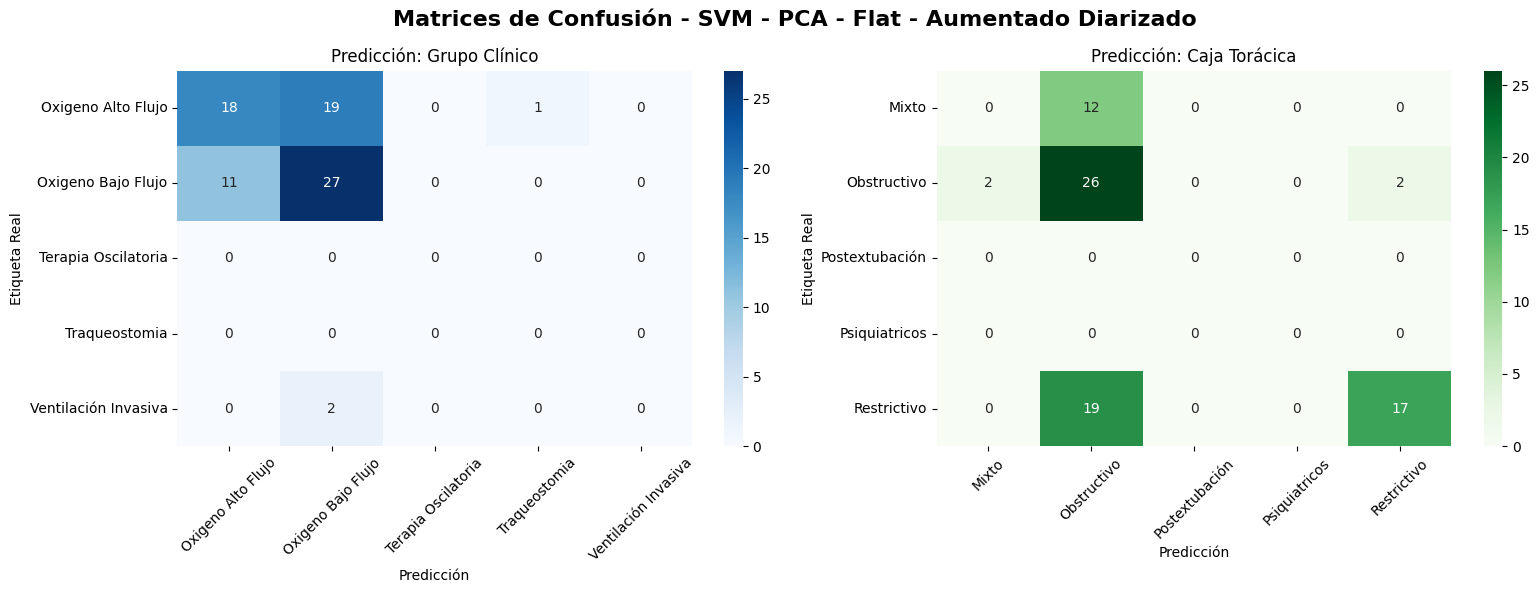

In [59]:
param_grid_svm_1_pca = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'C': 2.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 60.26% | F1-Score (Macro): 30.32%
CAJA TORÁCICA -> Accuracy: 55.13% | F1-Score (Macro): 40.53%


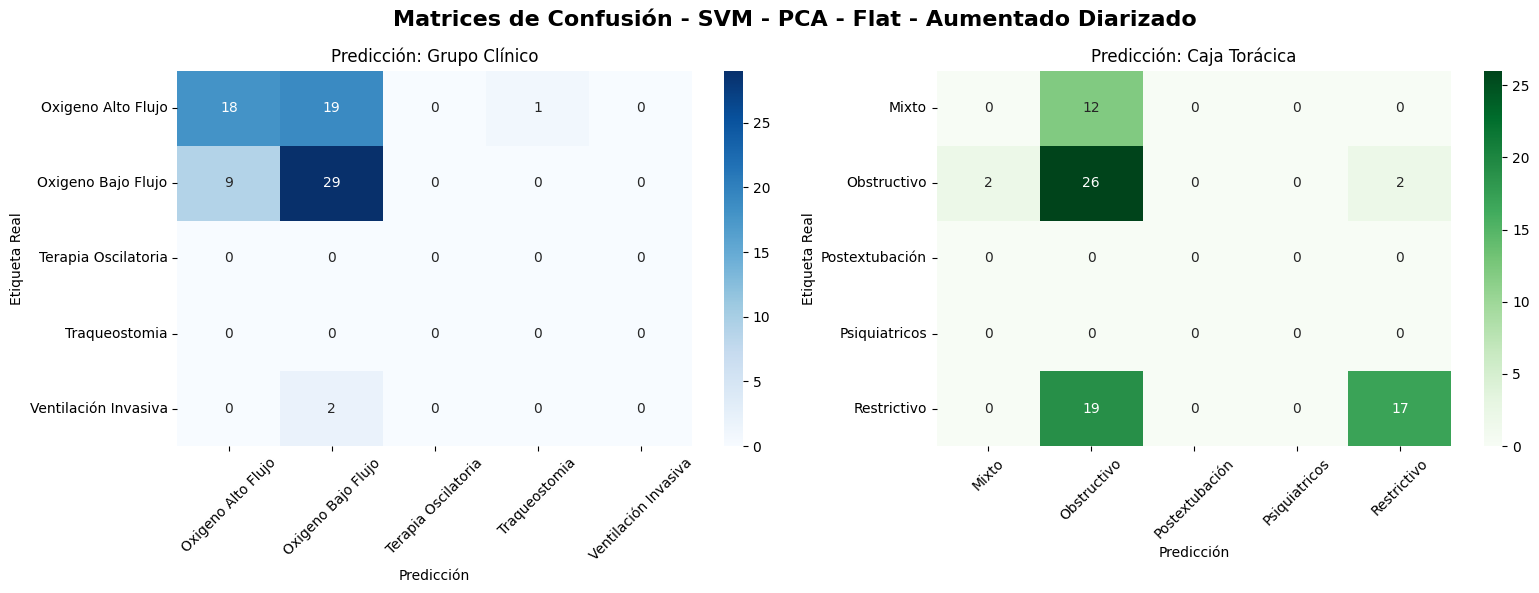

In [63]:
param_grid_svm_2_grupo_pca = {
    'C': [1.5, 2.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_2_caja_pca = {
    'C': [1.0, 2.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_2_grupo_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_2_caja_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'C': 3.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 58.97% | F1-Score (Macro): 29.57%
CAJA TORÁCICA -> Accuracy: 55.13% | F1-Score (Macro): 40.66%


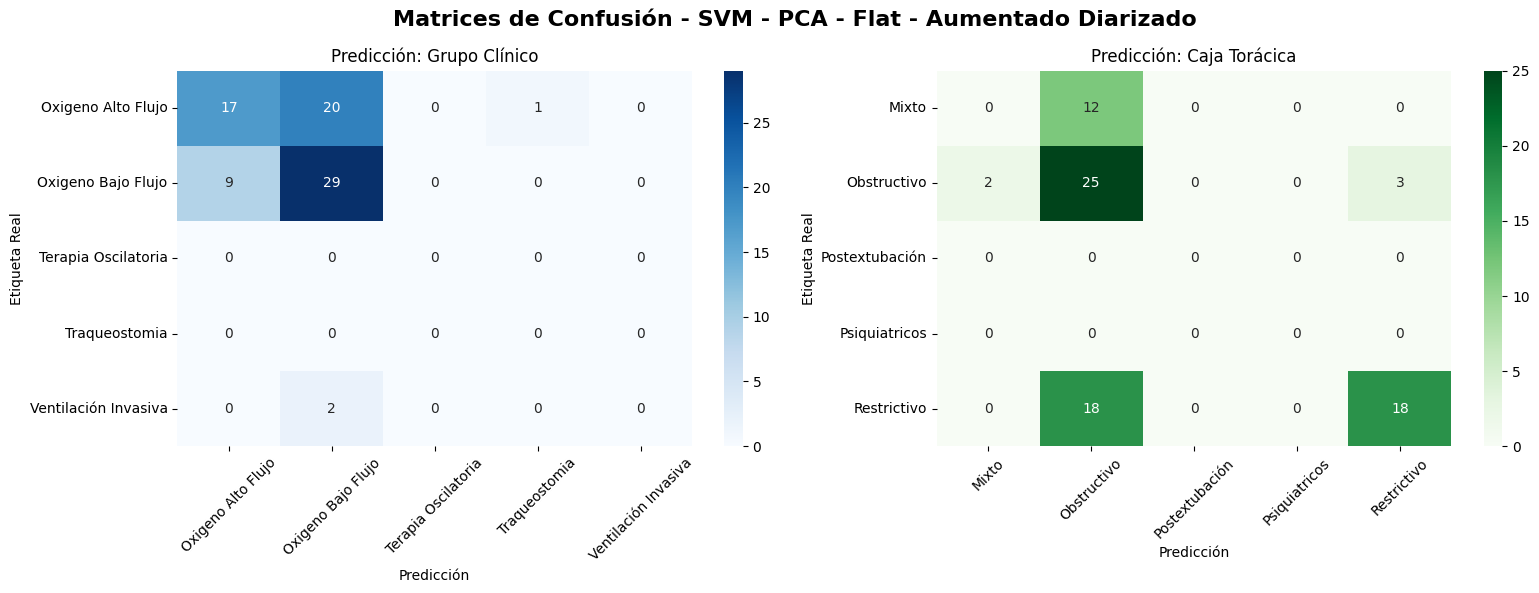

In [65]:
param_grid_svm_3_grupo_pca = {
    'C': [2.0, 2.5, 3.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_3_caja_pca = {
    'C': [2.0, 2.5, 3.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_3_grupo_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_3_caja_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'C': 2.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 60.26% | F1-Score (Macro): 30.32%
CAJA TORÁCICA -> Accuracy: 55.13% | F1-Score (Macro): 40.66%


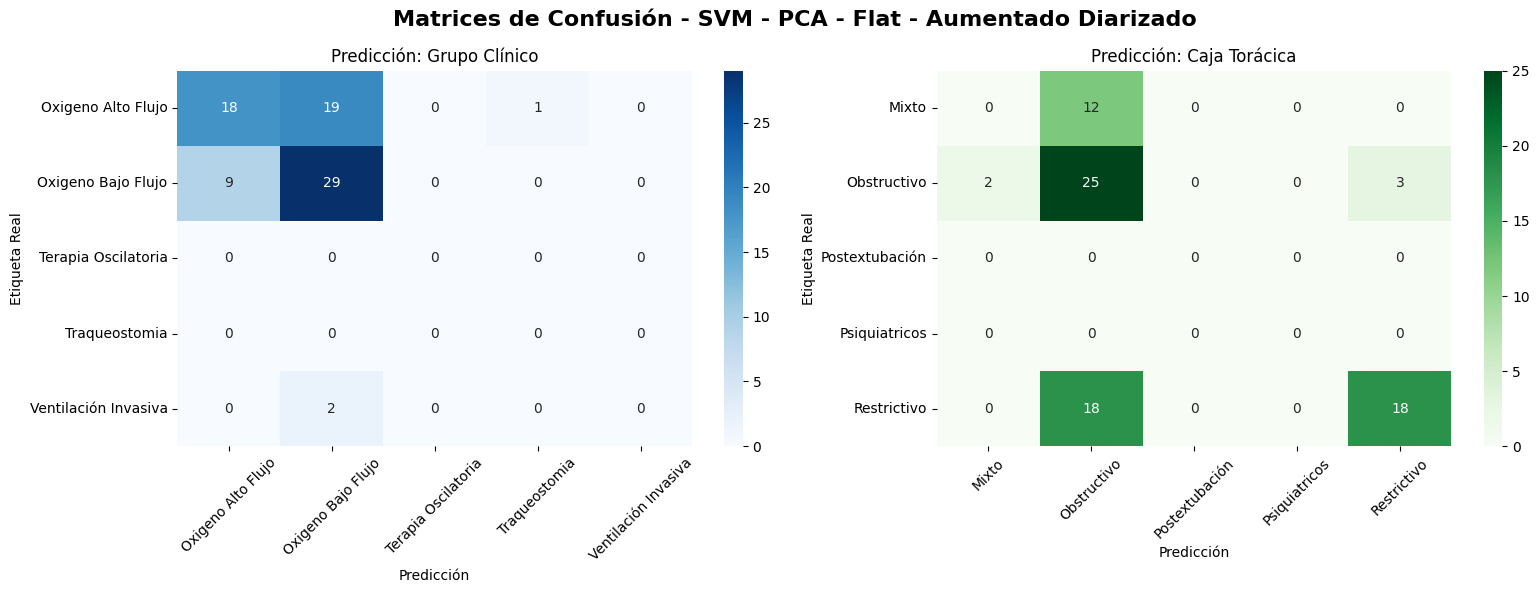

In [67]:
param_grid_svm_final_grupo_pca = {
    'C': [2.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_final_caja_pca = {
    'C': [2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_final_grupo_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_final_caja_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_svm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

##### LightGBM

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 53.85% | F1-Score (Macro): 33.68%
CAJA TORÁCICA -> Accuracy: 51.28% | F1-Score (Macro): 28.65%


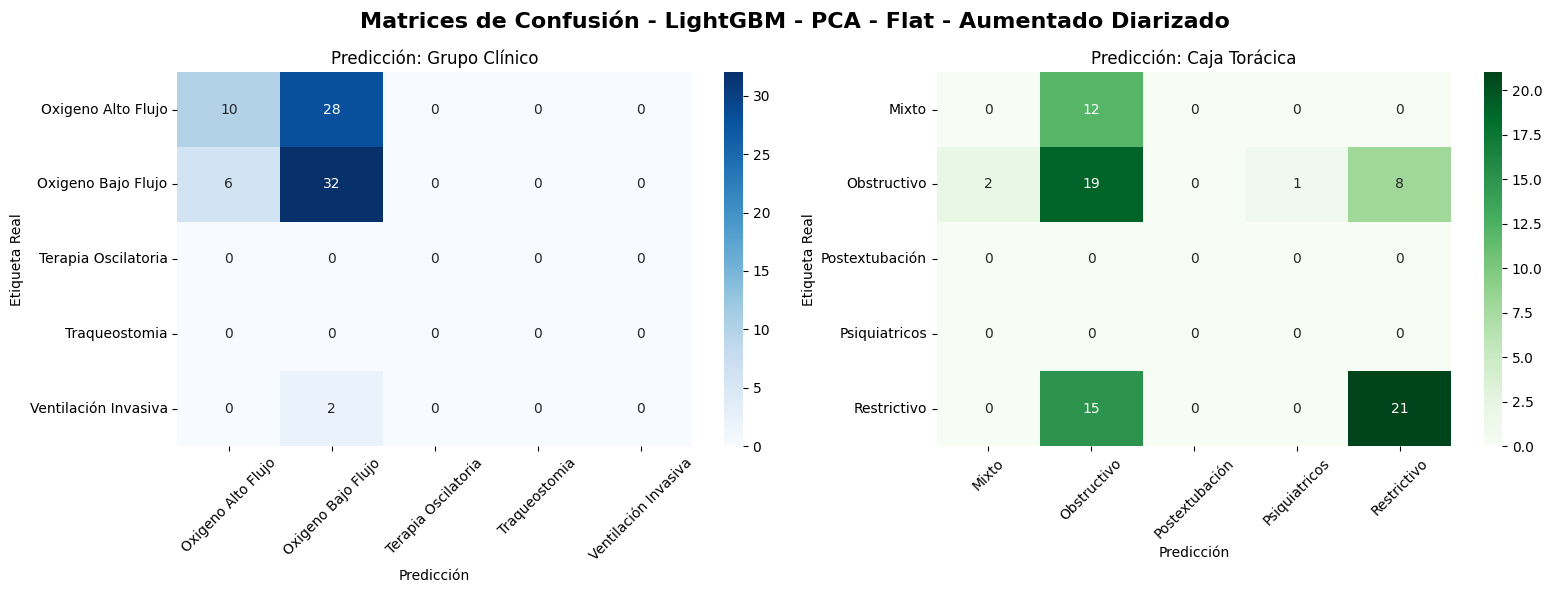

In [69]:
param_grid_lgbm_pca = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_lgbm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 63}
GRUPOS -> Accuracy: 53.85% | F1-Score (Macro): 33.11%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 28.21%


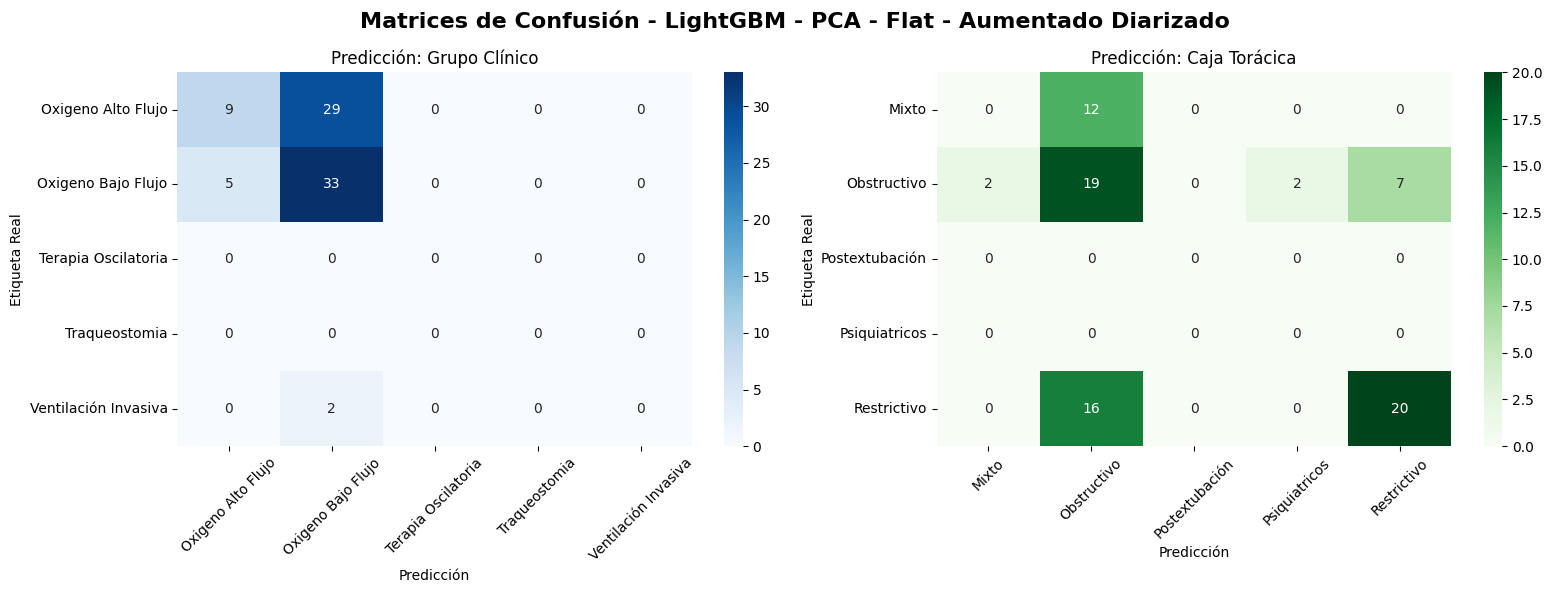

In [71]:
param_grid_lgbm_1_pca = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_lgbm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.15, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.15, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 63}
GRUPOS -> Accuracy: 51.28% | F1-Score (Macro): 31.17%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 28.15%


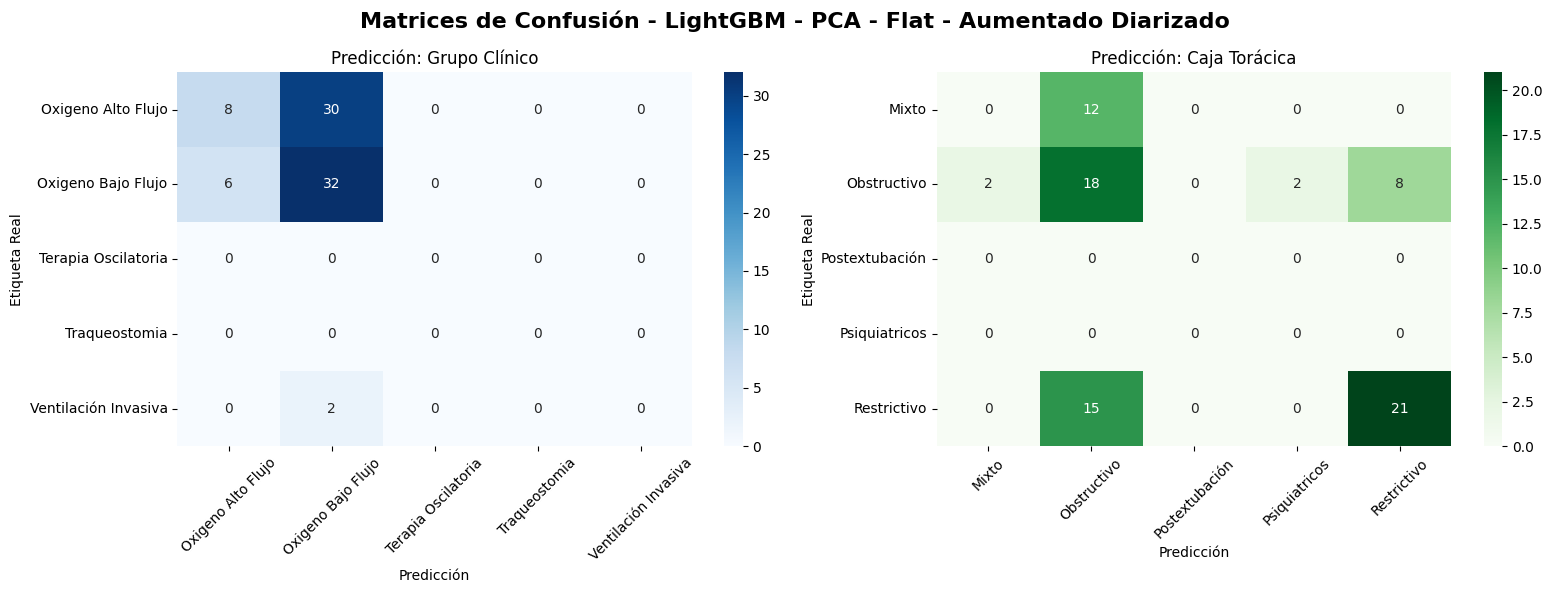

In [74]:
param_grid_lgbm_2_grupo_pca = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1],
    'min_child_samples': [20]
}

param_grid_lgbm_2_caja_pca = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1],
    'min_child_samples': [20, 50]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_grupo_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_caja_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_lgbm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 53.85% | F1-Score (Macro): 33.68%
CAJA TORÁCICA -> Accuracy: 51.28% | F1-Score (Macro): 28.65%


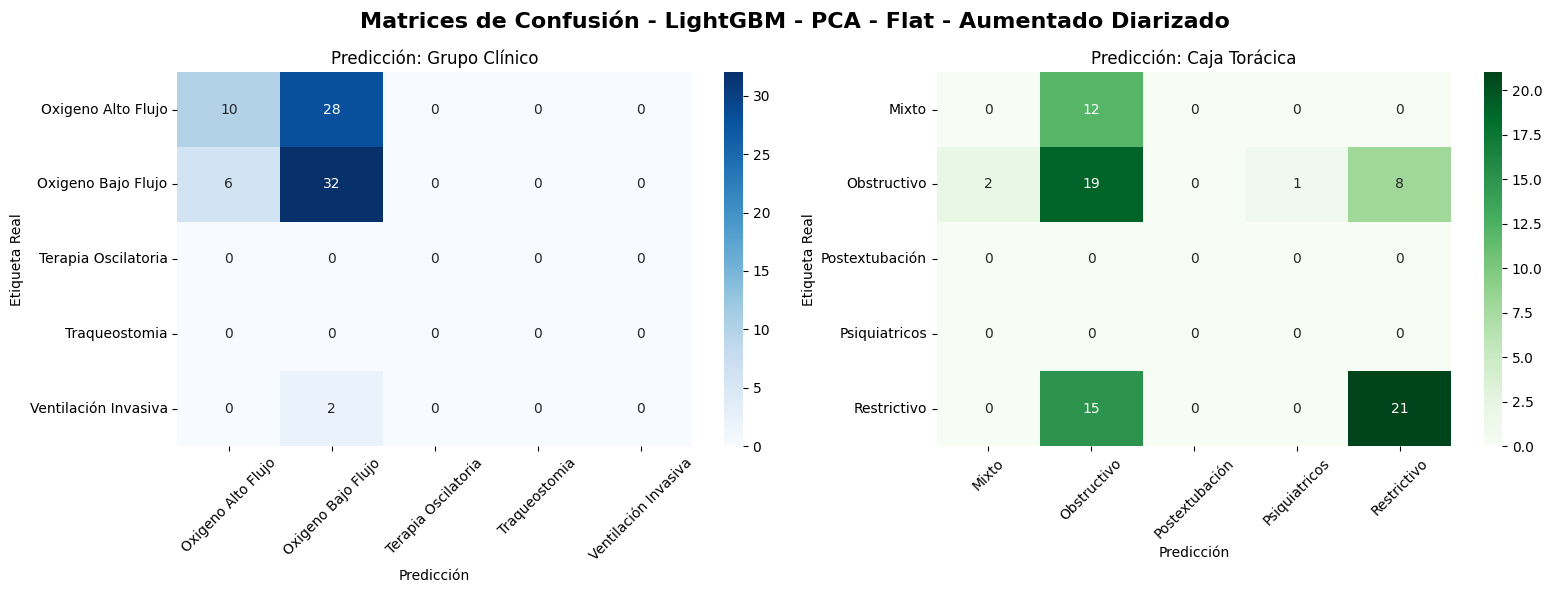

In [76]:
param_grid_lgbm_final_pca = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_pca_model, y_train_grupo_pca)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_pca, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_lgbm_caja.fit(X_train_pca_model, y_train_caja_pca)

evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

##### KNN

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 73.08% | F1-Score (Macro): 49.31%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 25.09%


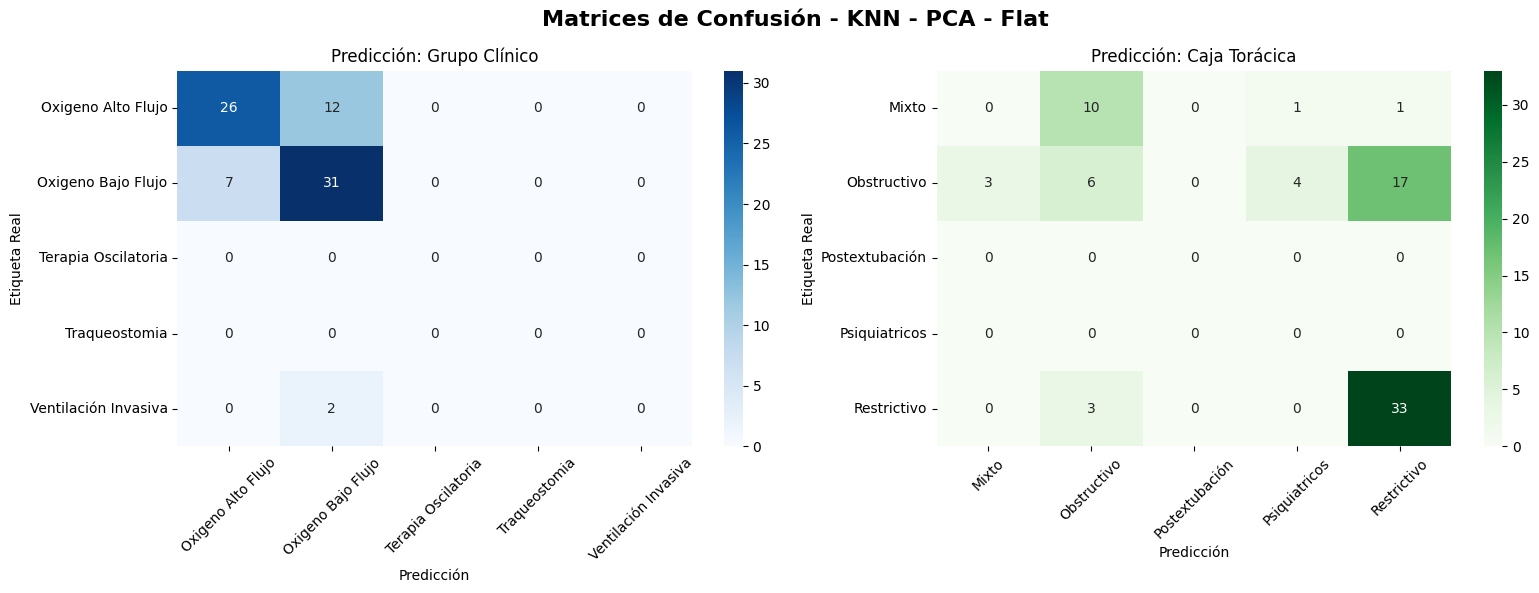

In [86]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_grupo.fit(X_train_pca_model, y_train_grupo_pca)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_caja.fit(X_train_pca_model, y_train_caja_pca)

# Evaluamos usando tu función personalizada
evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 9, 'weights': 'uniform'}
GRUPOS -> Accuracy: 51.28% | F1-Score (Macro): 34.44%
CAJA TORÁCICA -> Accuracy: 42.31% | F1-Score (Macro): 23.14%


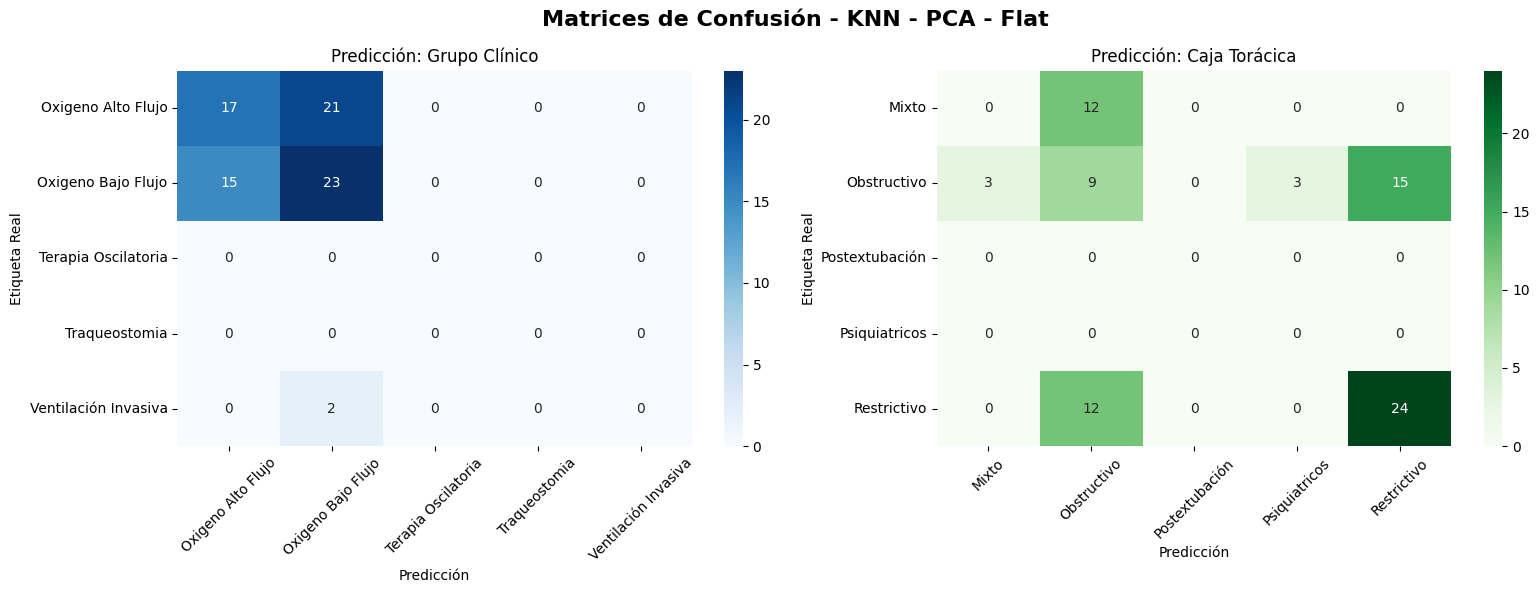

In [89]:
param_grid_knn_2 = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_grupo.fit(X_train_pca_model, y_train_grupo_pca)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_caja.fit(X_train_pca_model, y_train_caja_pca)

# Evaluamos usando tu función personalizada
evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 3, 'weights': 'uniform'}
GRUPOS -> Accuracy: 51.28% | F1-Score (Macro): 34.44%
CAJA TORÁCICA -> Accuracy: 53.85% | F1-Score (Macro): 35.08%


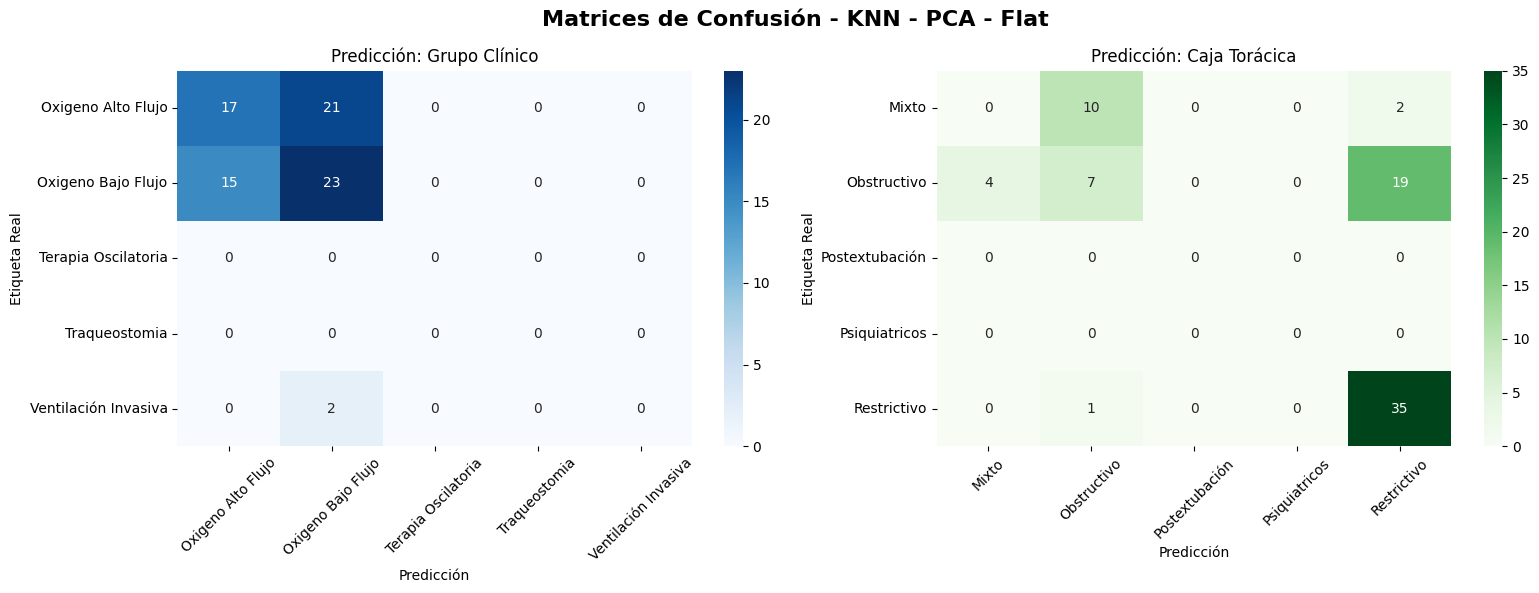

In [91]:
param_grid_knn_2_minkowski = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'p': [1, 2, 3],
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_minkowski, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_grupo.fit(X_train_pca_model, y_train_grupo_pca)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_minkowski, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_caja.fit(X_train_pca_model, y_train_caja_pca)

# Evaluamos usando tu función personalizada
evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 11, 'p': 3, 'weights': 'uniform'}
GRUPOS -> Accuracy: 71.79% | F1-Score (Macro): 48.46%
CAJA TORÁCICA -> Accuracy: 46.15% | F1-Score (Macro): 22.72%


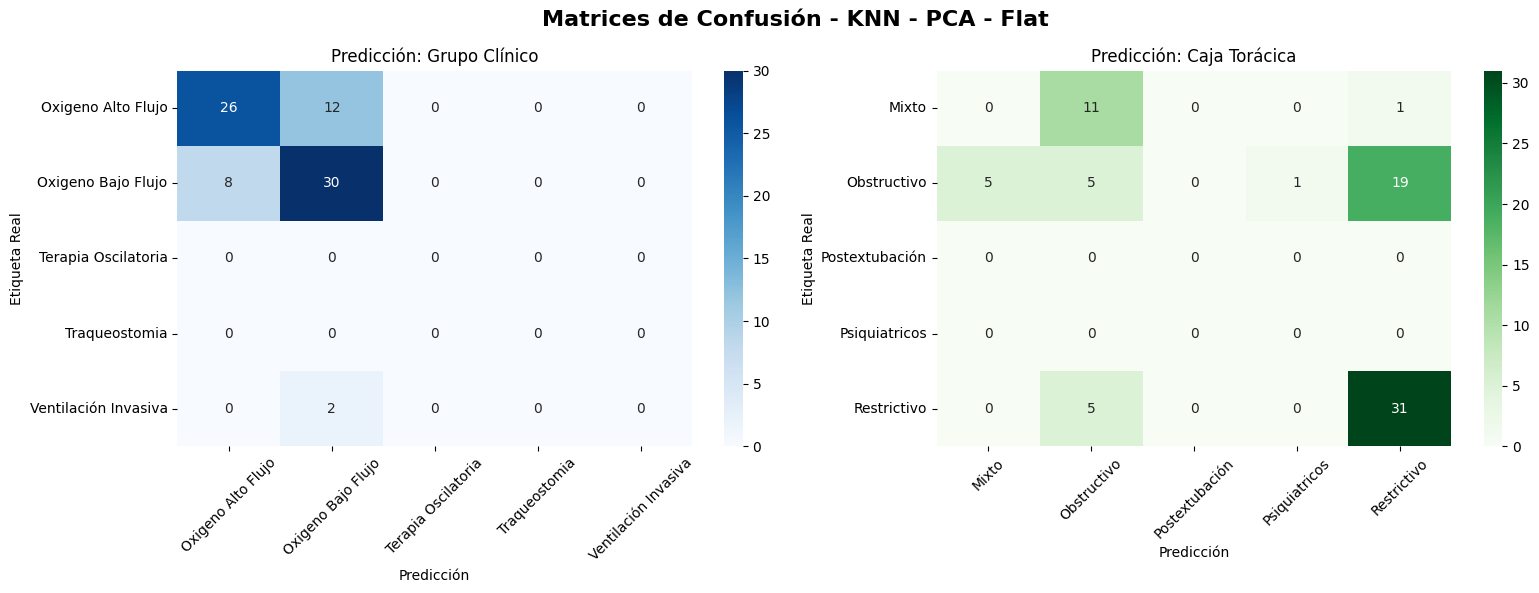

In [96]:
#Seguiremos probando con minkowski
param_grid_knn_3_minkowski = { 
    'n_neighbors': [5, 9, 11],   
    'weights': ['uniform'],     
    'p': [2, 3],
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_3_minkowski, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_grupo.fit(X_train_pca_model, y_train_grupo_pca)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_3_minkowski, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_caja.fit(X_train_pca_model, y_train_caja_pca)

# Evaluamos usando tu función personalizada
evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 3, 'weights': 'uniform'}
GRUPOS -> Accuracy: 73.08% | F1-Score (Macro): 49.31%
CAJA TORÁCICA -> Accuracy: 53.85% | F1-Score (Macro): 35.08%


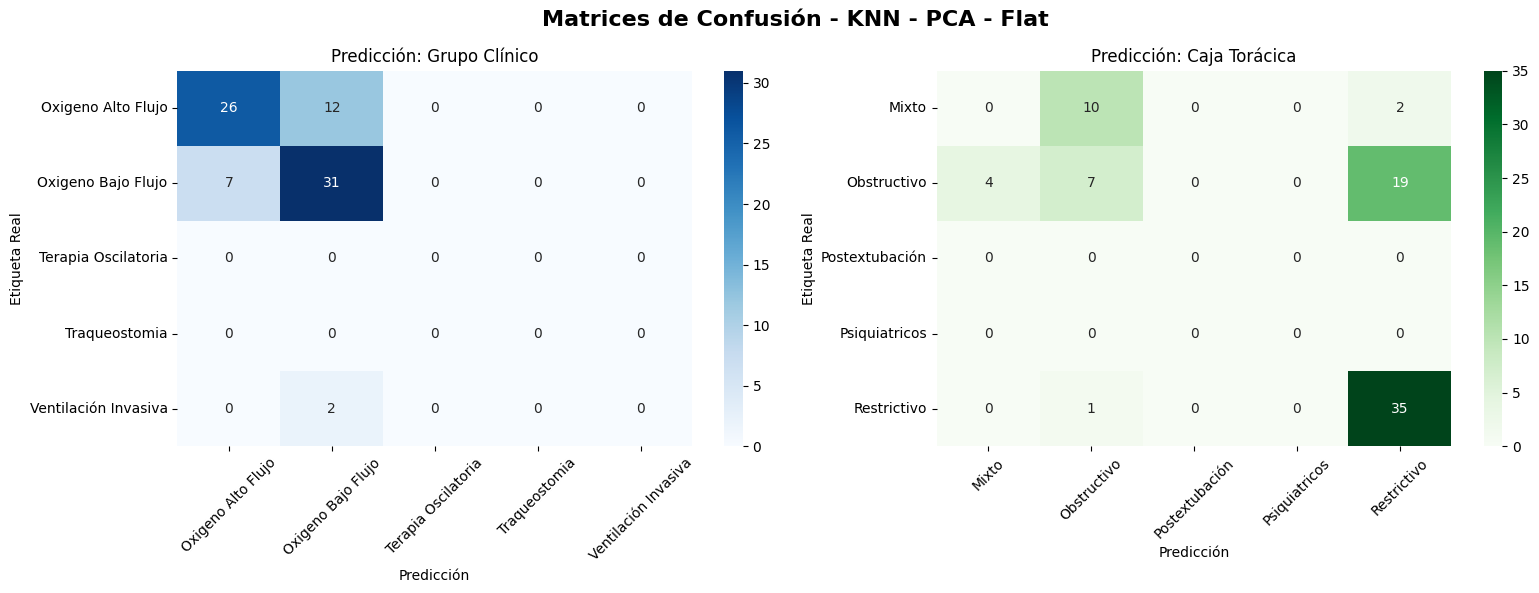

In [99]:
#El mejor es el de base:
param_grid_final_grupo_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}


param_grid_final_caja_knn = {
    'n_neighbors': [9],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [3]                 
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_final_grupo_knn, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_grupo.fit(X_train_pca_model, y_train_grupo_pca)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_final_caja_knn, scoring='f1_macro', cv=ps_pca, n_jobs=-1)
grid_knn_caja.fit(X_train_pca_model, y_train_caja_pca)

# Evaluamos usando tu función personalizada
evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat")

#### SelectKBest en FLAT

Selección supervisada de características mediante ANOVA F-test, independiente para cada objetivo. Con 4296 muestras y 75 características seleccionadas, la relación 4296/75 ≈ 57:1 es muy favorable para modelos clásicos.

In [102]:
columnas_a_quitar = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

X_train_num = df_train_flat.drop(columns=columnas_a_quitar)
X_test_num = df_test_flat.drop(columns=columnas_a_quitar)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

meta_train = df_train_flat[columnas_a_quitar].reset_index(drop=True)
meta_test = df_test_flat[columnas_a_quitar].reset_index(drop=True)

In [105]:
y_train_grupo = meta_train['grupo']
y_test_grupo = meta_test['grupo']

y_train_caja = meta_train['caja_toracica']
y_test_caja = meta_test['caja_toracica']

K_FEATURES = 75
# Seleccionamos 75 características. Con 1692 muestras la relación muestras/características
# (≈23:1) es muy favorable. Al ser SelectKBest supervisado (ANOVA F-test), estas 75
# características son las de mayor correlación estadística con la variable objetivo,
# a diferencia del PCA que opera de forma no supervisada.

selector_grupo = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_grupo_selected = selector_grupo.fit_transform(X_train_scaled, y_train_grupo)
X_test_grupo_selected = selector_grupo.transform(X_test_scaled)

selector_caja = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_caja_selected = selector_caja.fit_transform(X_train_scaled, y_train_caja)
X_test_caja_selected = selector_caja.transform(X_test_scaled)

X_train_grupo_selected = np.array(X_train_grupo_selected)
X_test_grupo_selected  = np.array(X_test_grupo_selected)
X_train_caja_selected  = np.array(X_train_caja_selected)
X_test_caja_selected   = np.array(X_test_caja_selected)

#### Entrenamiento de modelos

In [108]:
def evaluar_modelo_kbest_flat(grid_grupo, grid_caja, X_test_grupo, X_test_caja, nombre_modelo):
    print(f"Mejores Hiperparámetros para Grupo Clínico: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros para Torácica: {grid_caja.best_params_}")

    pred_grupo = grid_grupo.predict(X_test_grupo)
    pred_caja = grid_caja.predict(X_test_caja)

    acc_grupo = accuracy_score(y_test_grupo, pred_grupo)
    f1_grupo = f1_score(y_test_grupo, pred_grupo, average='macro', zero_division=0)
    print(f"GRUPOS -> Accuracy: {acc_grupo*100:.2f}% | F1-Score (Macro): {f1_grupo*100:.2f}%")

    acc_caja = accuracy_score(y_test_caja, pred_caja)
    f1_caja = f1_score(y_test_caja, pred_caja, average='macro', zero_division=0)
    print(f"CAJA TORÁCICA -> Accuracy: {acc_caja*100:.2f}% | F1-Score (Macro): {f1_caja*100:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Matrices de Confusión - {nombre_modelo}', fontsize=16, fontweight='bold')

    cm_grupo = confusion_matrix(y_test_grupo, pred_grupo, labels=grid_grupo.classes_)
    sns.heatmap(cm_grupo, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=grid_grupo.classes_, yticklabels=grid_grupo.classes_)
    axes[0].set_title('Predicción: Grupo Clínico')
    axes[0].set_ylabel('Etiqueta Real')
    axes[0].set_xlabel('Predicción')
    axes[0].tick_params(axis='x', rotation=45)

    cm_caja = confusion_matrix(y_test_caja, pred_caja, labels=grid_caja.classes_)
    sns.heatmap(cm_caja, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=grid_caja.classes_, yticklabels=grid_caja.classes_)
    axes[1].set_title('Predicción: Caja Torácica')
    axes[1].set_ylabel('Etiqueta Real')
    axes[1].set_xlabel('Predicción')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [110]:
folds_oficiales = df_train_flat['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

##### Random Forest

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 50.00% | F1-Score (Macro): 26.27%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 38.09%


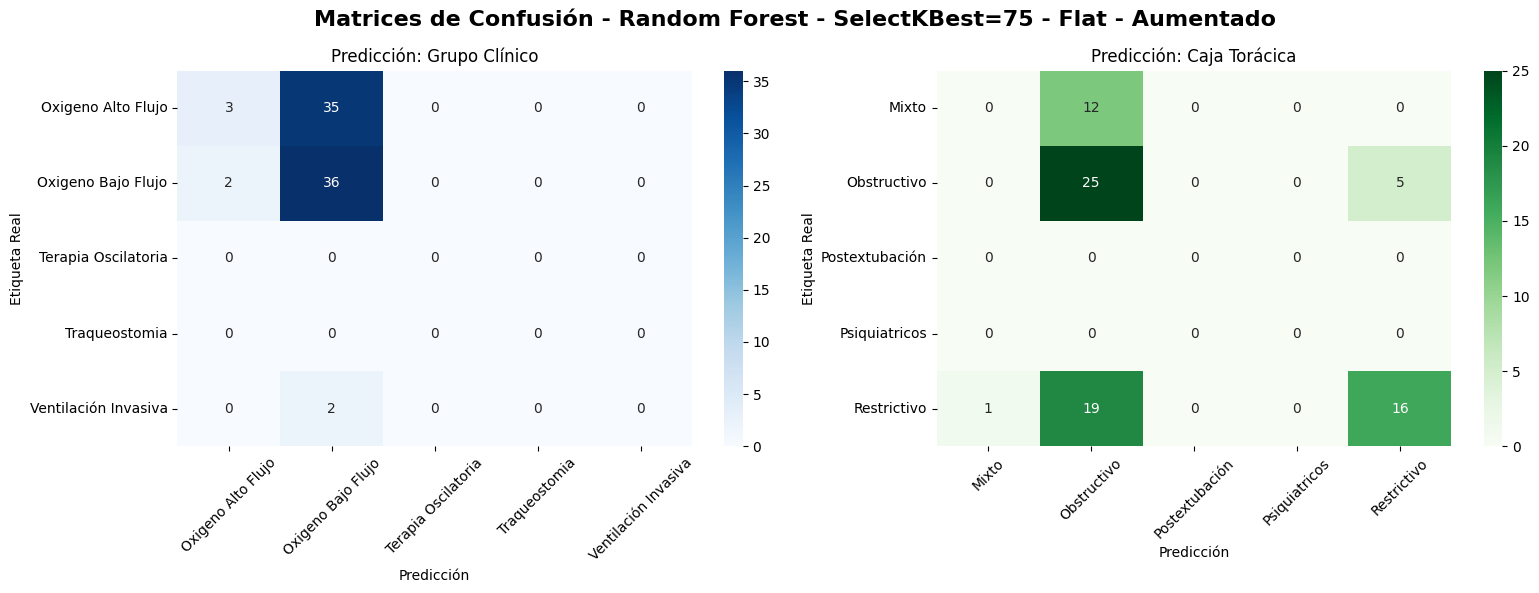

In [113]:
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(grid_rf_grupo, grid_rf_caja,
    X_test_grupo_selected, X_test_caja_selected,
    "Random Forest - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
GRUPOS -> Accuracy: 65.38% | F1-Score (Macro): 31.96%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 37.87%


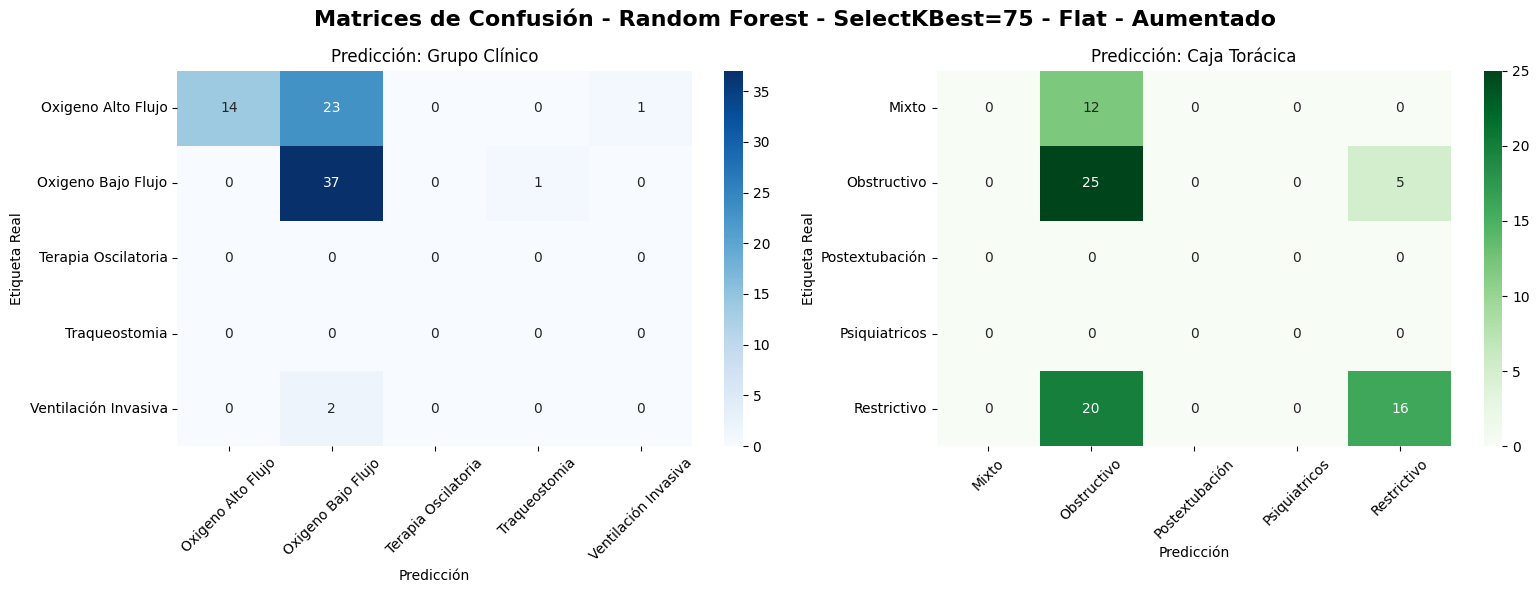

In [114]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 64.10% | F1-Score (Macro): 42.54%
CAJA TORÁCICA -> Accuracy: 47.44% | F1-Score (Macro): 34.70%


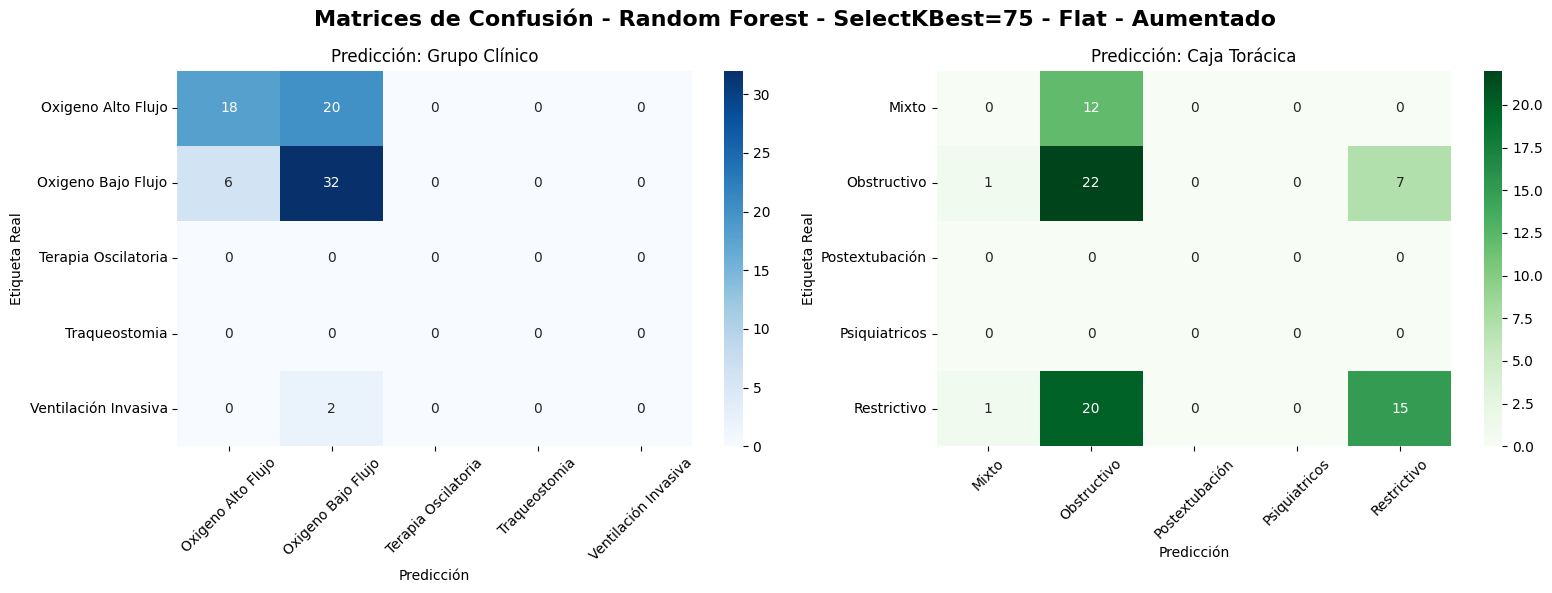

In [117]:
param_grid_rf_2_kbest = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 300}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
GRUPOS -> Accuracy: 67.95% | F1-Score (Macro): 34.69%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 37.66%


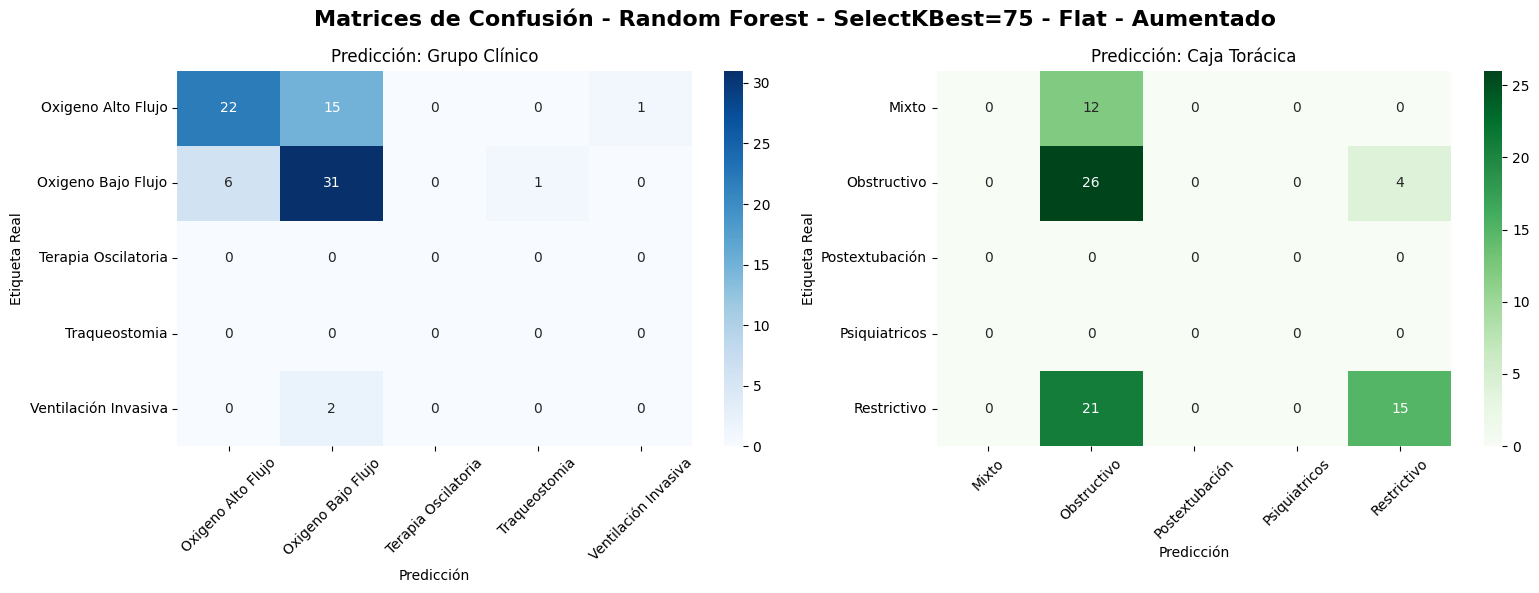

In [119]:
param_grid_rf_3_grupo_kbest = {
    'n_estimators': [100, 300],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [6, 8],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_3_caja_kbest = {
    'n_estimators': [100, 200, 300],      
    'max_depth': [None, 20],        
    'min_samples_split': [5],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_3_grupo_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_3_caja_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 12, 'min_samples_split': 2, 'n_estimators': 350}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
GRUPOS -> Accuracy: 75.64% | F1-Score (Macro): 39.32%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 37.87%


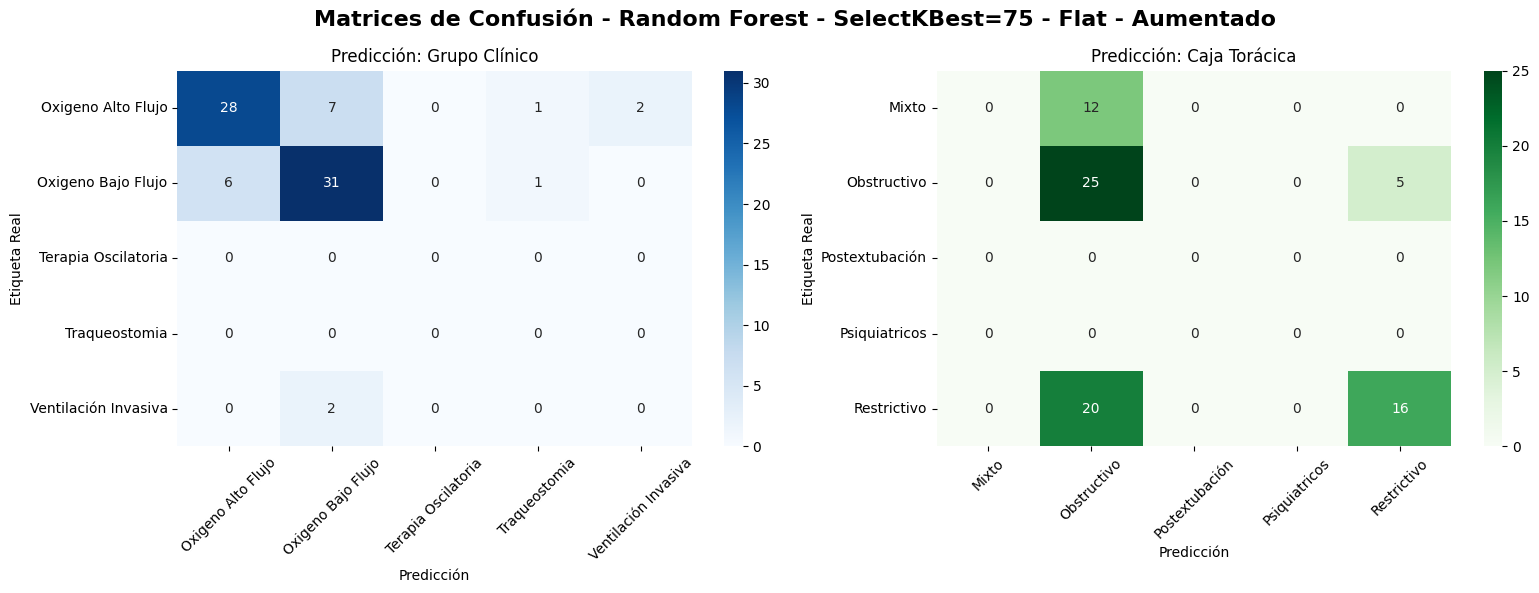

In [123]:
param_grid_rf_4_grupo_kbest = {
    'n_estimators': [300, 350],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [8, 12],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_final_caja_kbest = {
    'n_estimators': [150],
    'max_depth': [20],
    'min_samples_split': [5],
    'min_samples_leaf': [2],
    'max_features': ['sqrt'],
    'bootstrap': [True]    
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_4_grupo_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 12, 'min_samples_split': 2, 'n_estimators': 400}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
GRUPOS -> Accuracy: 74.36% | F1-Score (Macro): 38.66%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 37.87%


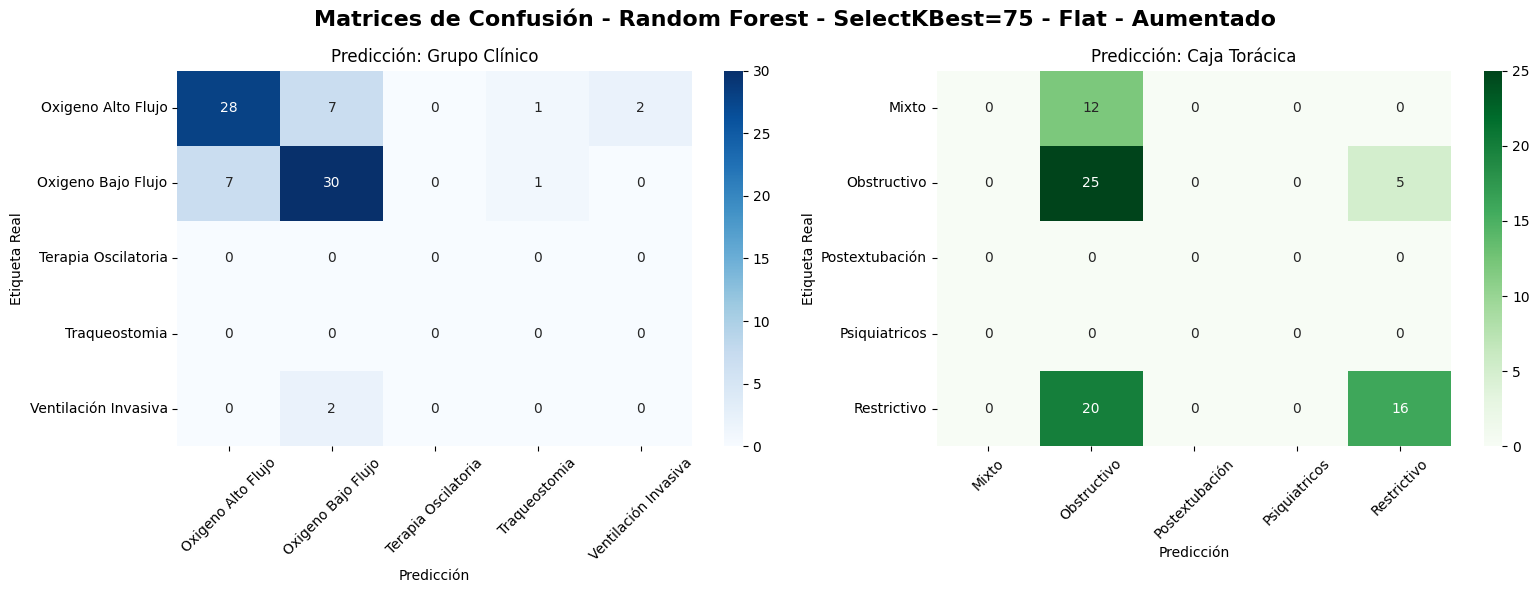

In [127]:
param_grid_rf_5_grupo_kbest = {
    'n_estimators': [350, 400],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [12, 14],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_final_caja_kbest = {
    'n_estimators': [150],
    'max_depth': [20],
    'min_samples_split': [5],
    'min_samples_leaf': [2],
    'max_features': ['sqrt'],
    'bootstrap': [True]    
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_5_grupo_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 12, 'min_samples_split': 2, 'n_estimators': 350}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
GRUPOS -> Accuracy: 75.64% | F1-Score (Macro): 39.32%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 37.87%


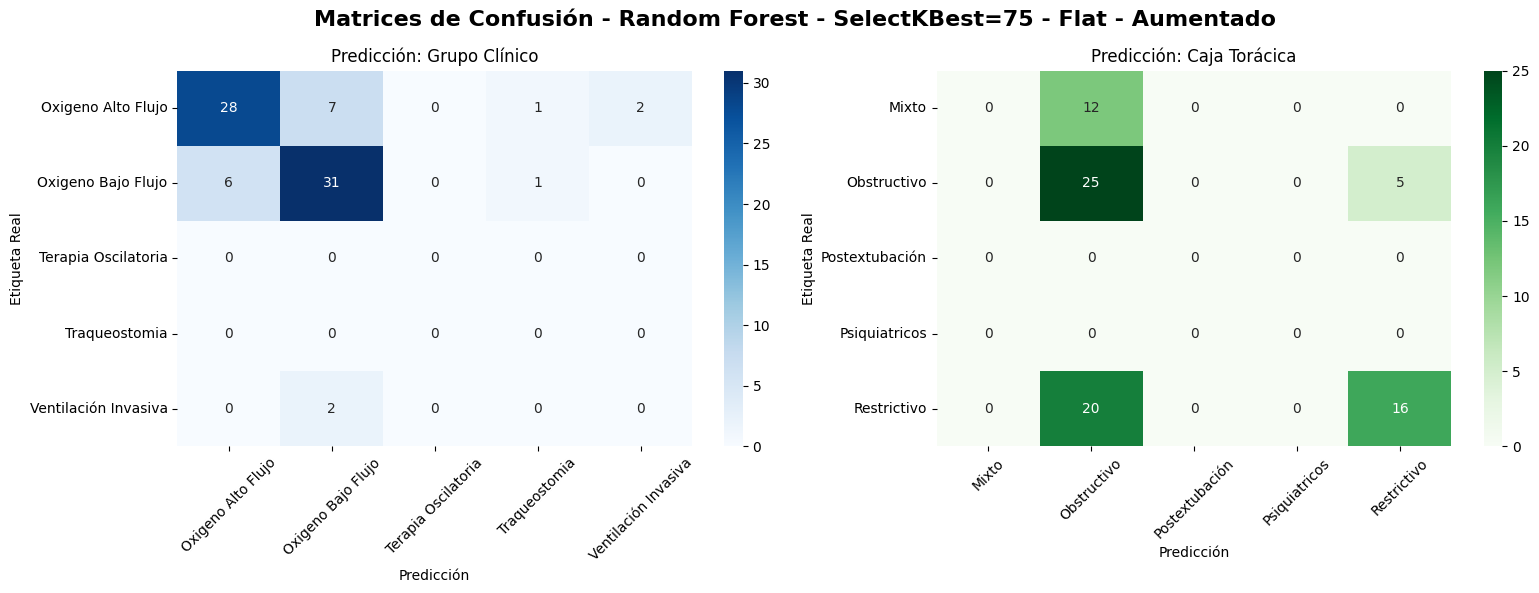

In [129]:
param_grid_rf_final_grupo_kbest = {
    'n_estimators': [350],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [12],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_final_caja_kbest = {
    'n_estimators': [150],
    'max_depth': [20],
    'min_samples_split': [5],
    'min_samples_leaf': [2],
    'max_features': ['sqrt'],
    'bootstrap': [True]    
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado"
)

##### SVM

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 58.97% | F1-Score (Macro): 27.98%
CAJA TORÁCICA -> Accuracy: 38.46% | F1-Score (Macro): 24.63%


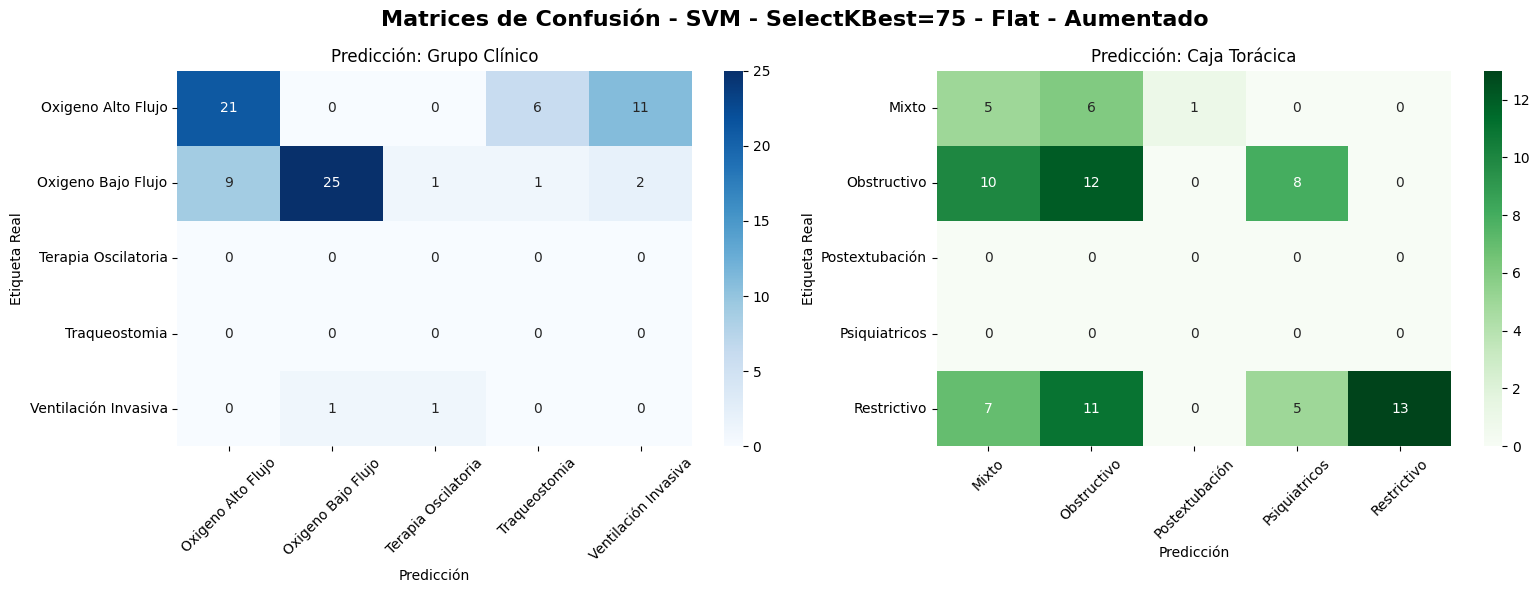

In [131]:
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(grid_svm_grupo, grid_svm_caja,
    X_test_grupo_selected, X_test_caja_selected,
    "SVM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 65.38% | F1-Score (Macro): 29.80%
CAJA TORÁCICA -> Accuracy: 41.03% | F1-Score (Macro): 25.67%


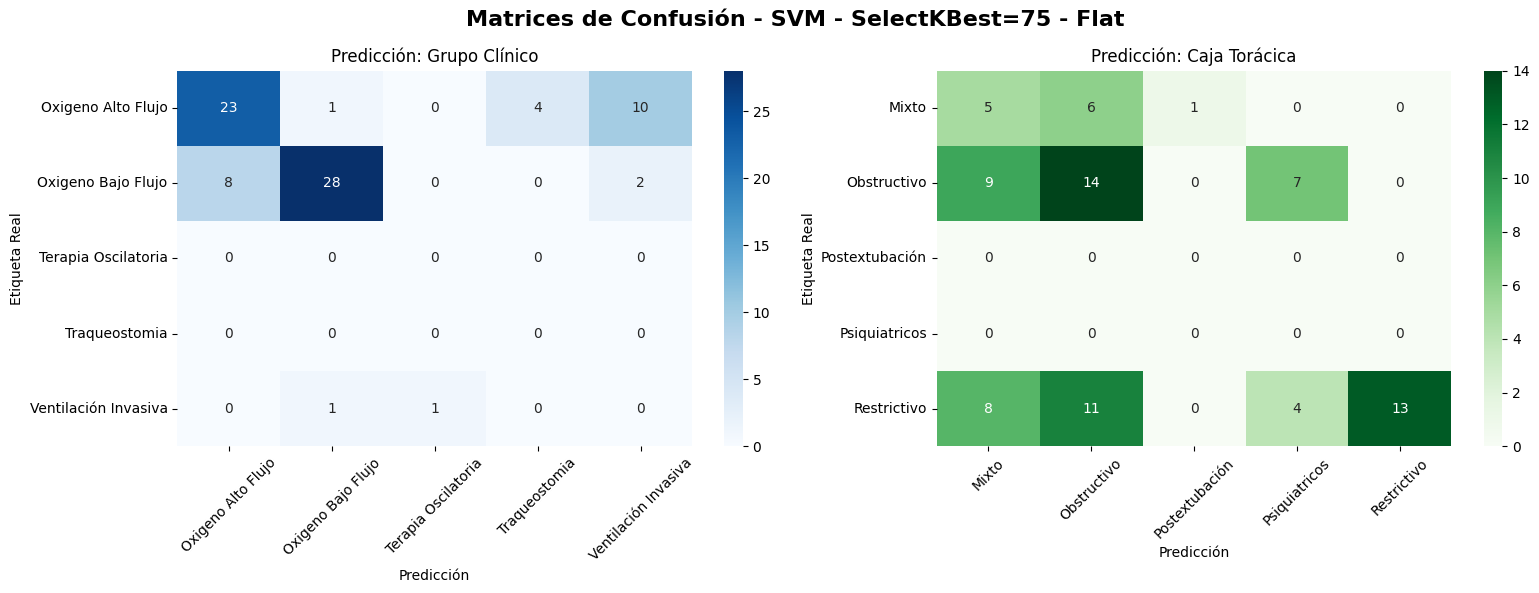

In [132]:
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_svm_grupo, 
    grid_caja=grid_svm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="SVM - SelectKBest=75 - Flat"
)

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 65.38% | F1-Score (Macro): 29.80%
CAJA TORÁCICA -> Accuracy: 41.03% | F1-Score (Macro): 25.67%


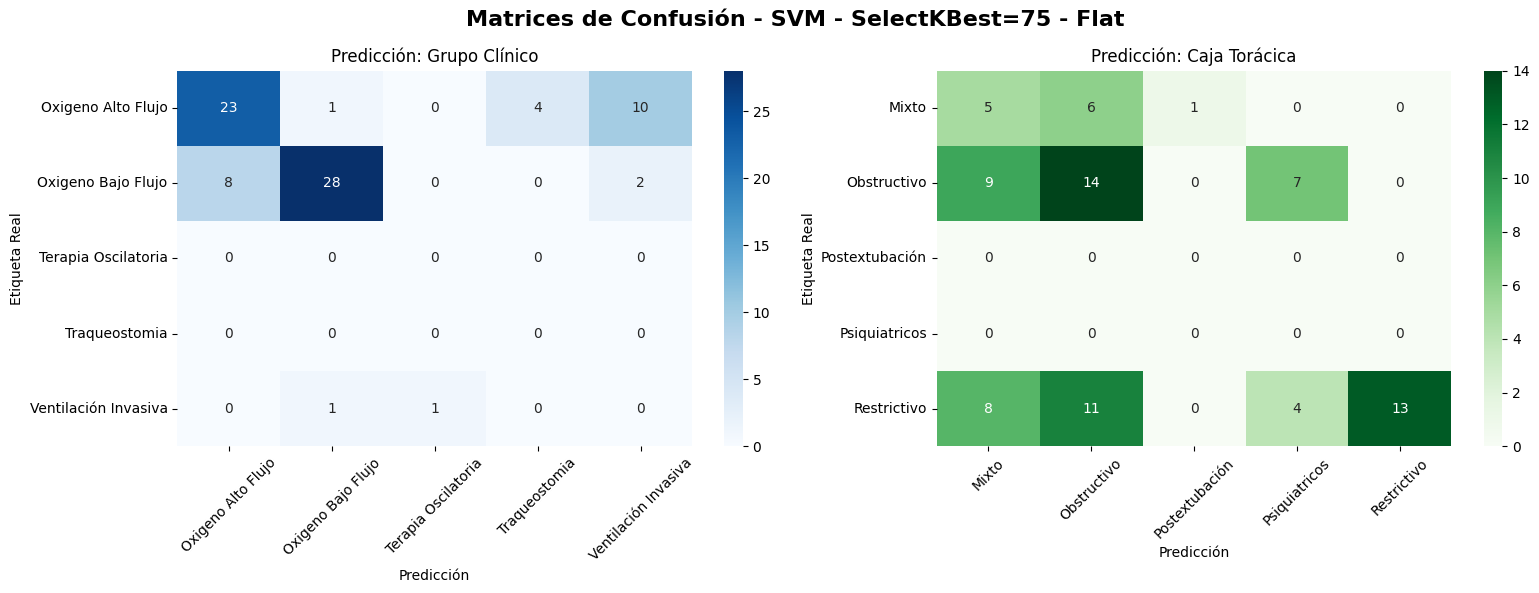

In [136]:
param_grid_svm_2_kbest = {
    'C': [1.5, 2.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_2_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_2_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_svm_grupo, 
    grid_caja=grid_svm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="SVM - SelectKBest=75 - Flat"
)

Mejores Hiperparámetros para Grupo Clínico: {'C': 3.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 3.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 69.23% | F1-Score (Macro): 29.84%
CAJA TORÁCICA -> Accuracy: 41.03% | F1-Score (Macro): 31.42%


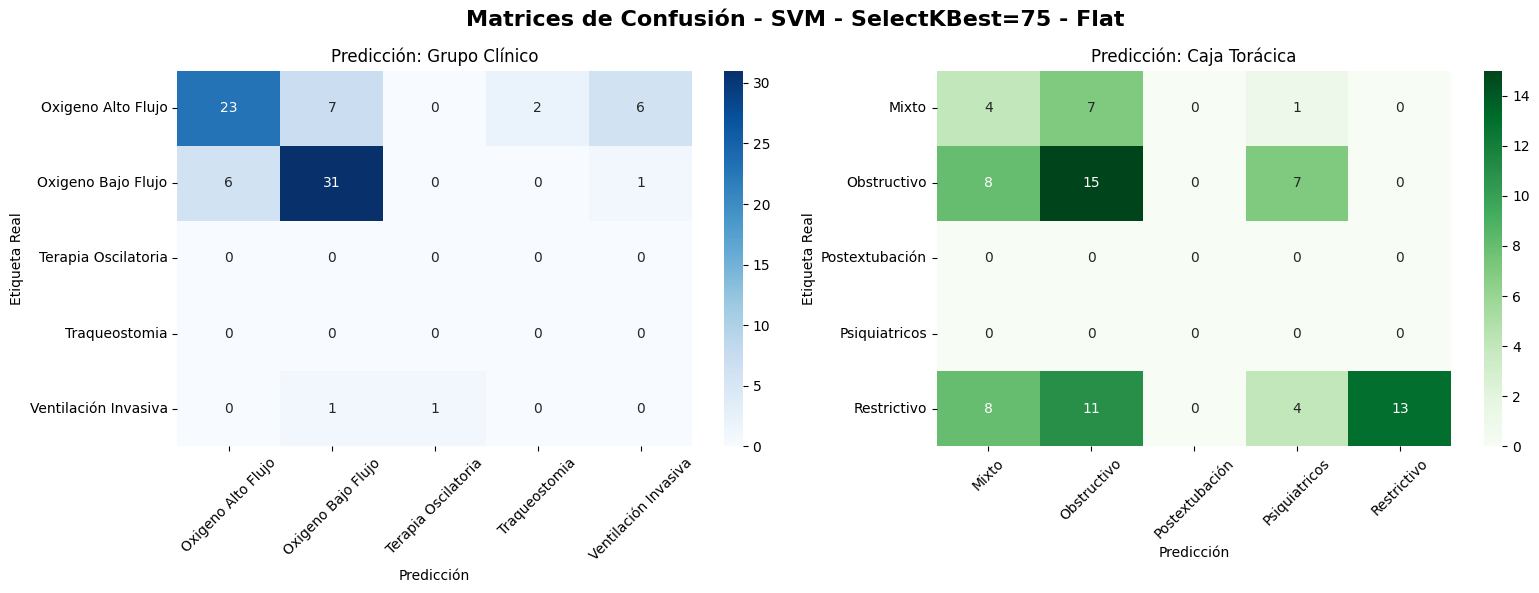

In [138]:
param_grid_svm_3_kbest = {
    'C': [1.5, 3.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_3_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_3_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_svm_grupo, 
    grid_caja=grid_svm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="SVM - SelectKBest=75 - Flat"
)

Mejores Hiperparámetros para Grupo Clínico: {'C': 3.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 3.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 69.23% | F1-Score (Macro): 29.84%
CAJA TORÁCICA -> Accuracy: 46.15% | F1-Score (Macro): 35.90%


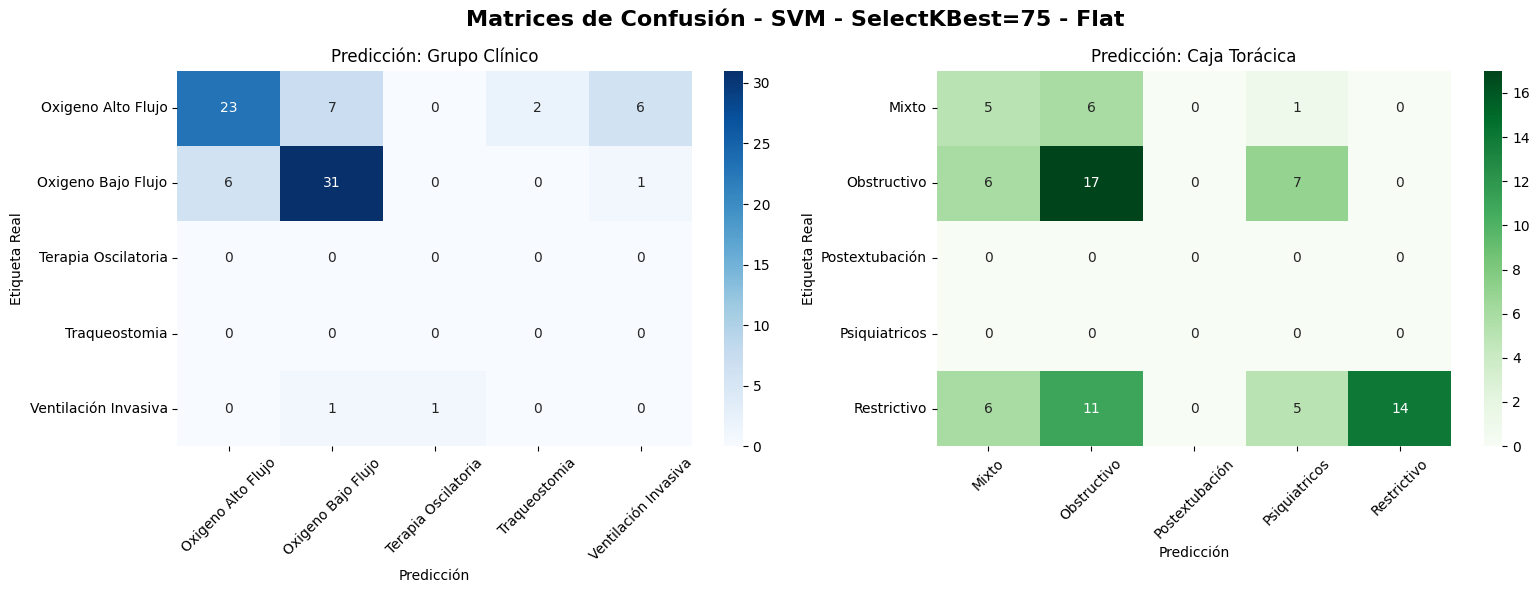

In [146]:
param_grid_svm_4_kbest = {
    'C': [3.0, 3.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_4_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_4_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_svm_grupo, 
    grid_caja=grid_svm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="SVM - SelectKBest=75 - Flat"
)

Mejores Hiperparámetros para Grupo Clínico: {'C': 3.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 3.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 69.23% | F1-Score (Macro): 29.84%
CAJA TORÁCICA -> Accuracy: 46.15% | F1-Score (Macro): 35.90%


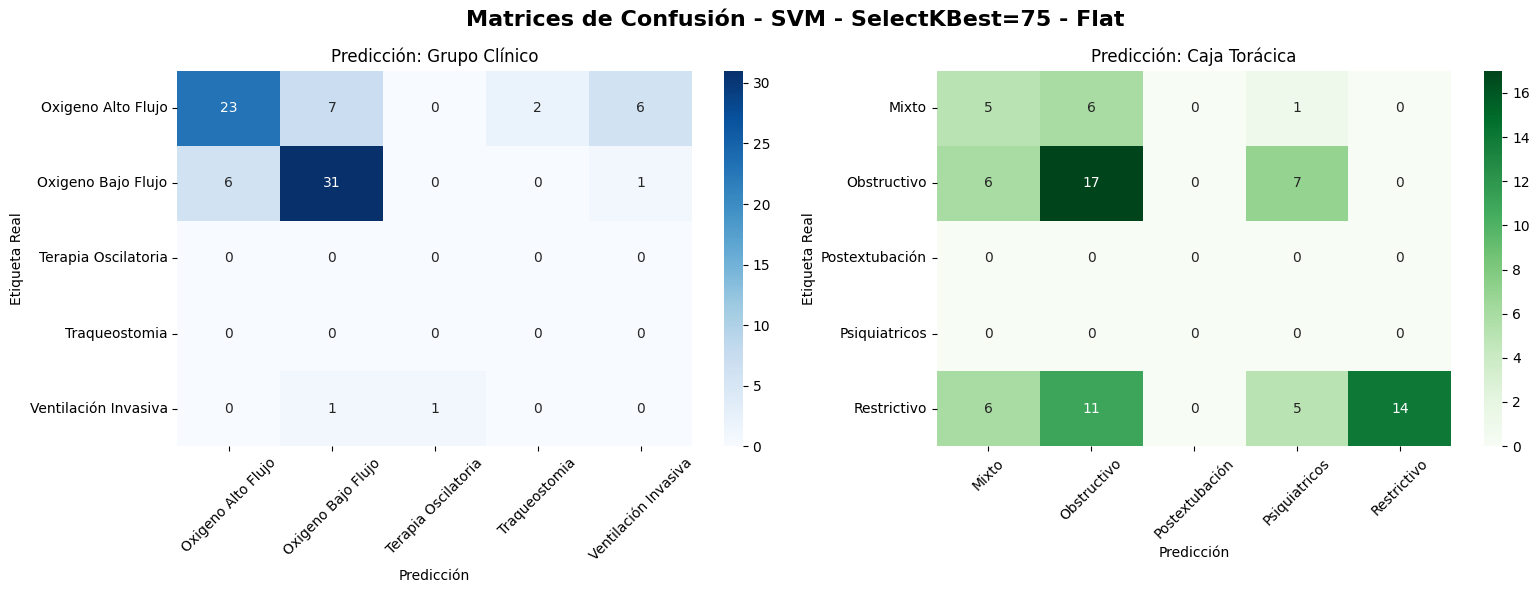

In [148]:
param_grid_svm_final_grupo_kbest = {
    'C': [3.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_final_caja_kbest = {
    'C': [3.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_final_grupo_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_final_caja_kbest, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_svm_grupo, 
    grid_caja=grid_svm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="SVM - SelectKBest=75 - Flat"
)

##### LightGBM

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 56.41% | F1-Score (Macro): 35.26%
CAJA TORÁCICA -> Accuracy: 48.72% | F1-Score (Macro): 39.71%


C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


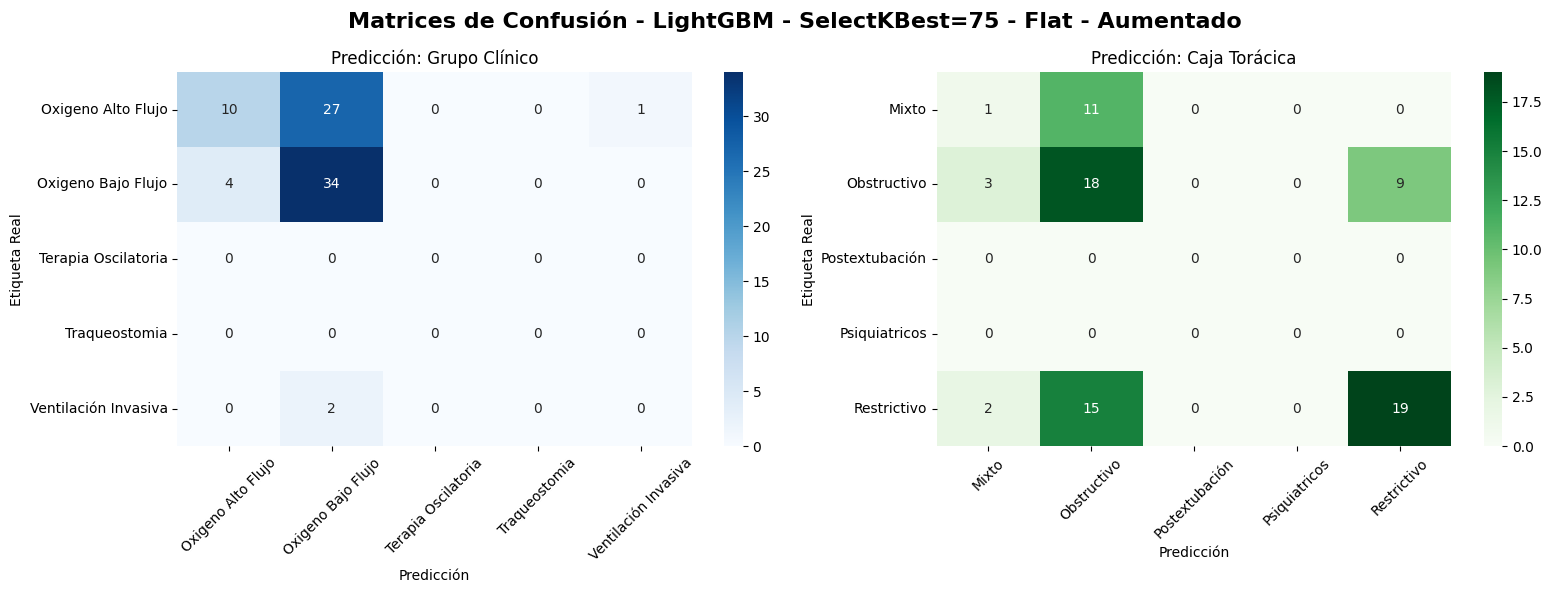

In [150]:
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_grupo_selected, y_train_grupo)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(grid_lgbm_grupo, grid_lgbm_caja,
    X_test_grupo_selected, X_test_caja_selected,
    "LightGBM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
GRUPOS -> Accuracy: 60.26% | F1-Score (Macro): 38.43%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 30.64%


C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


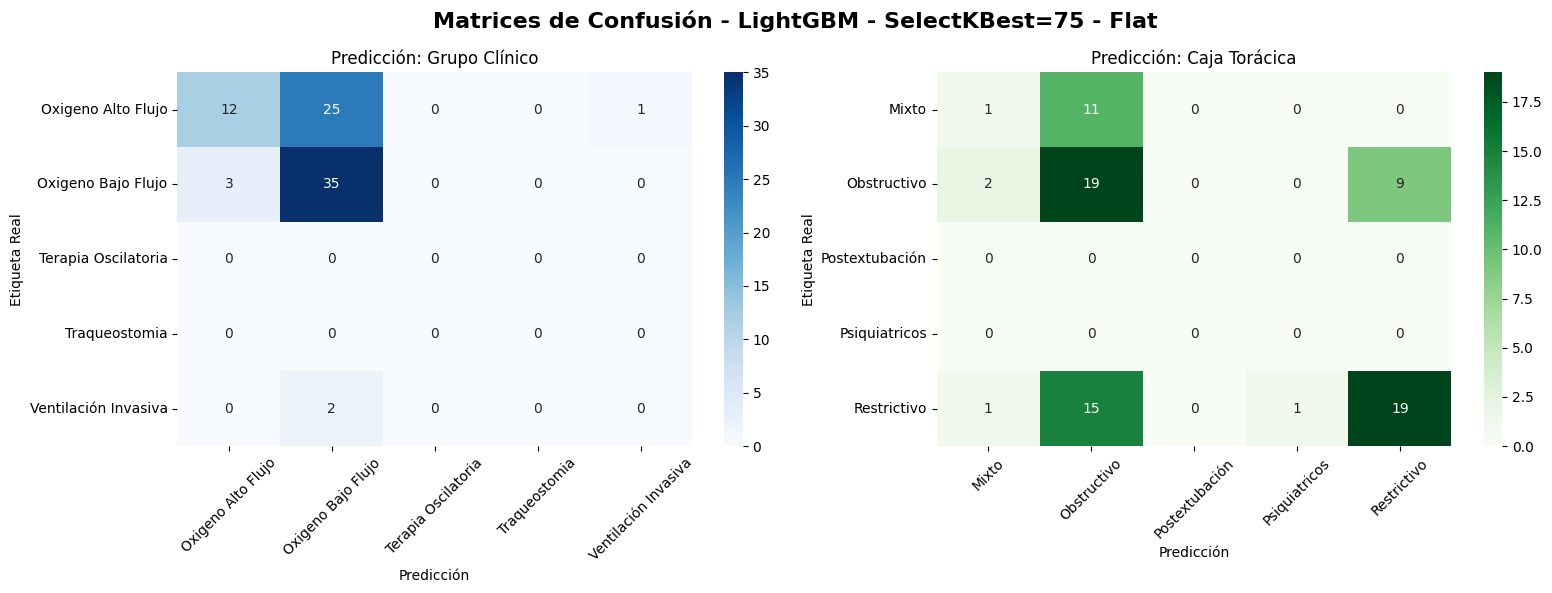

In [151]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_grupo_selected, y_train_grupo)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_lgbm_grupo, 
    grid_caja=grid_lgbm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="LightGBM - SelectKBest=75 - Flat"
)

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.15, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.15, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}
GRUPOS -> Accuracy: 60.26% | F1-Score (Macro): 37.91%
CAJA TORÁCICA -> Accuracy: 48.72% | F1-Score (Macro): 30.12%


C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


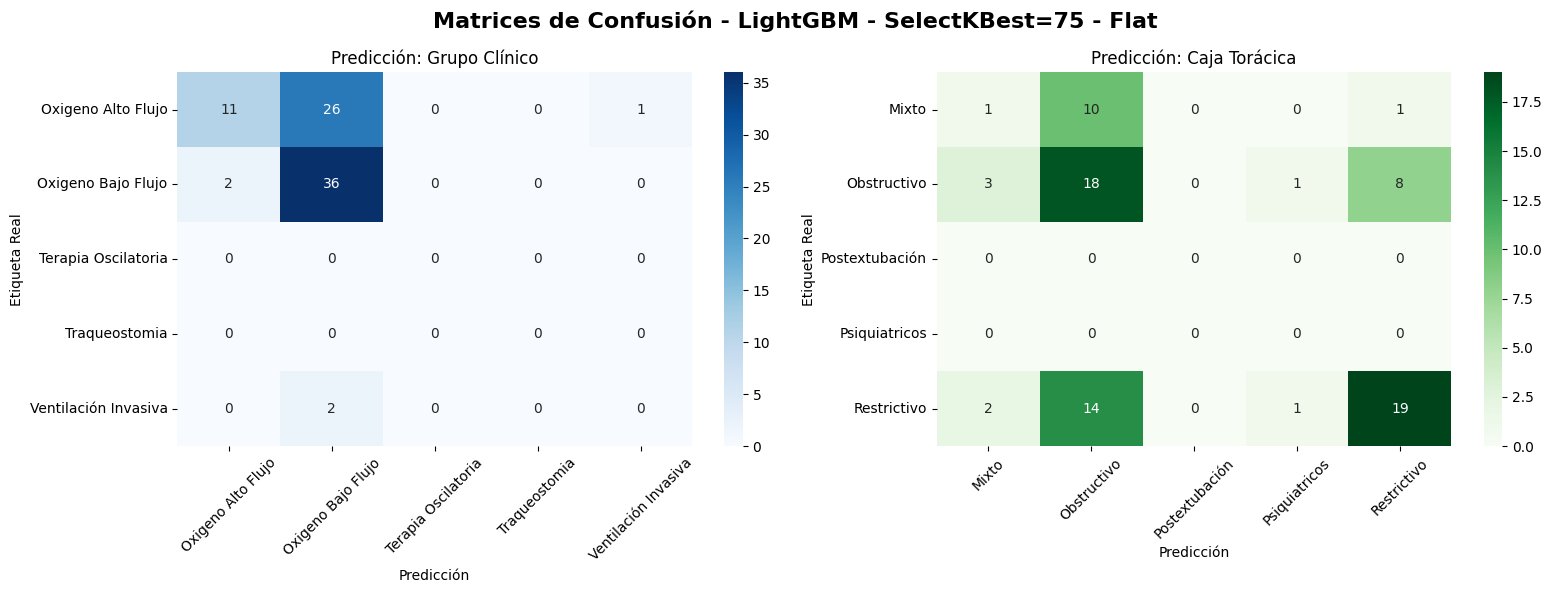

In [155]:
param_grid_lgbm_2_grupo_kbest_flat = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20, 50]
}

param_grid_lgbm_2_caja_kbest_flat = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}


lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_grupo_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_grupo_selected, y_train_grupo)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_caja_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_lgbm_grupo, 
    grid_caja=grid_lgbm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="LightGBM - SelectKBest=75 - Flat"
)

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
GRUPOS -> Accuracy: 60.26% | F1-Score (Macro): 38.43%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 30.64%


C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


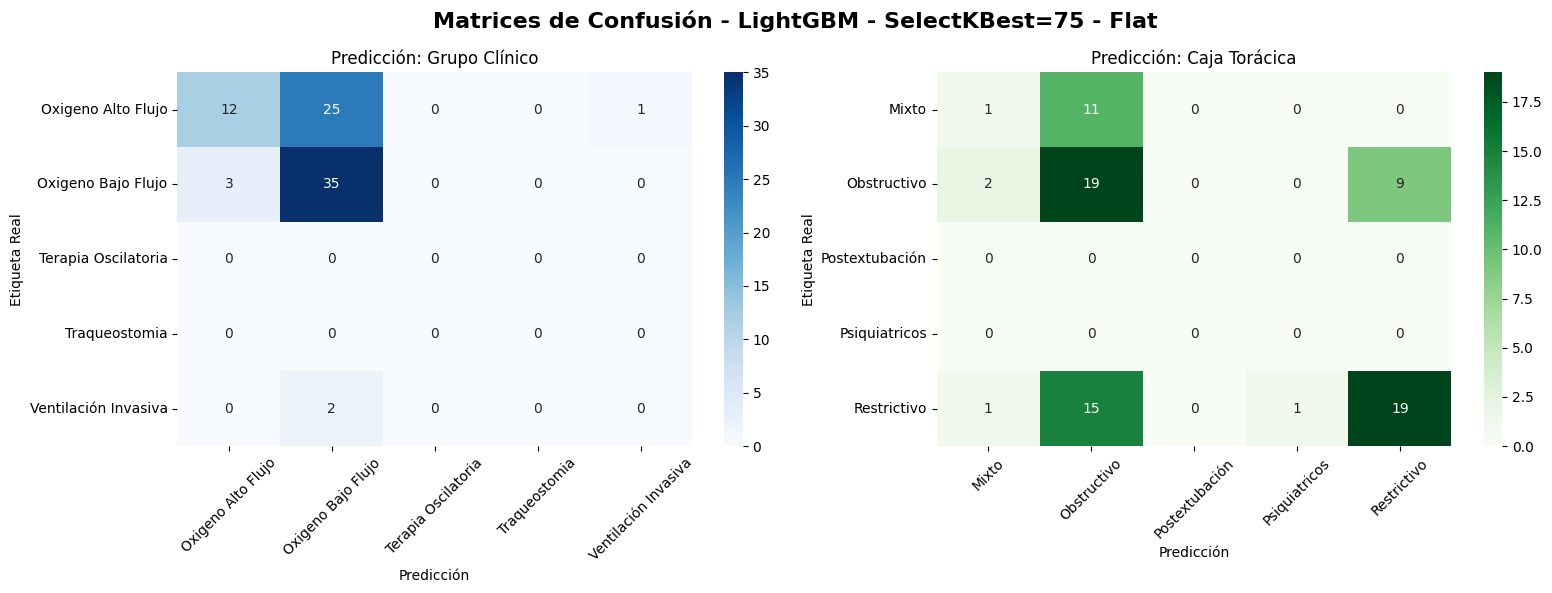

In [159]:
param_grid_lgbm_final_grupo_kbest_flat = {
    'n_estimators': [200],
    'learning_rate': [0.05],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [50]
}

param_grid_lgbm_final_caja_kbest_flat = {
    'n_estimators': [200],
    'learning_rate': [0.05],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}


lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_grupo_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_grupo_selected, y_train_grupo)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_caja_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest_flat(
    grid_grupo=grid_lgbm_grupo, 
    grid_caja=grid_lgbm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="LightGBM - SelectKBest=75 - Flat"
)

##### KNN

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 56.41% | F1-Score (Macro): 36.05%
CAJA TORÁCICA -> Accuracy: 53.85% | F1-Score (Macro): 33.27%


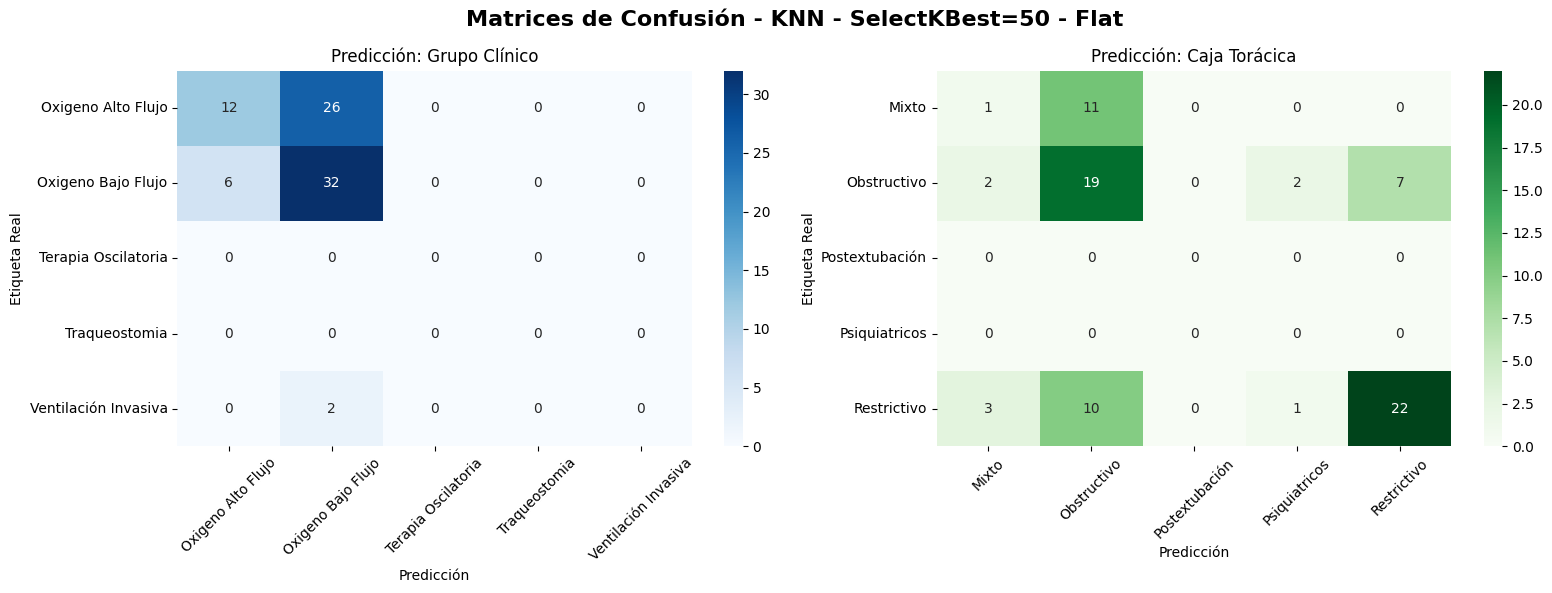

In [164]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_caja_selected, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_kbest_flat(
    grid_grupo=grid_knn_grupo, 
    grid_caja=grid_knn_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="KNN - SelectKBest=50 - Flat"
)

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.2238203  0.20938124 0.22941758 0.21842656 0.25001894 0.23139222
        nan 0.19585265        nan 0.22118209        nan 0.23961835
 0.23761928 0.21280166 0.26612697 0.23609011 0.2769925  0.27869959]
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.24031859 0.23200039 0.25729456 0.24129955 0.2508432  0.24937515
        nan 0.25135988        nan 0.26784082        nan 0.24133132
 0.24149266 0.22875423 0.23521028 0.24659264 0.25579893 0.25985267]
  warnings.warn(


Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 9, 'weights': 'distance'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
GRUPOS -> Accuracy: 67.95% | F1-Score (Macro): 45.14%
CAJA TORÁCICA -> Accuracy: 48.72% | F1-Score (Macro): 30.02%


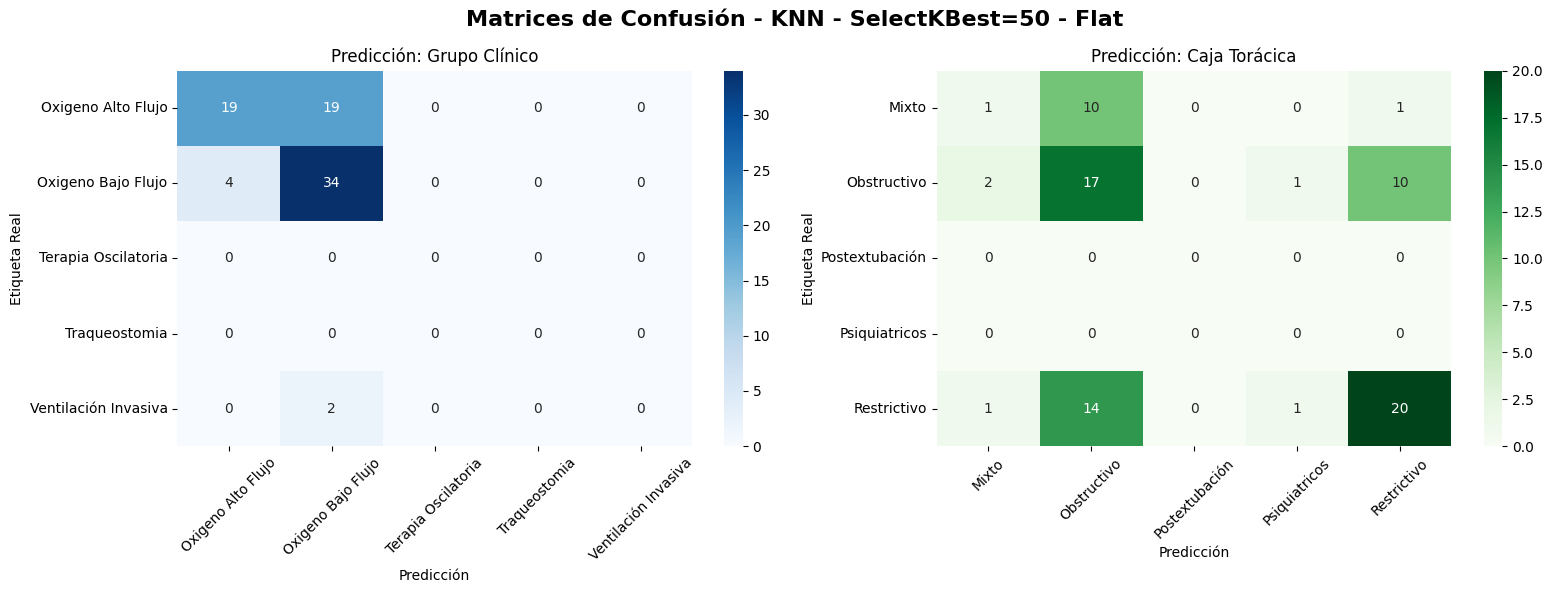

In [167]:
param_grid_knn_2 = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_caja_selected, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_kbest_flat(
    grid_grupo=grid_knn_grupo, 
    grid_caja=grid_knn_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="KNN - SelectKBest=50 - Flat"
)

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan 0.19585265 0.2238203  0.20938124        nan 0.20499206
        nan 0.22118209 0.22941758 0.21842656        nan 0.21786557
        nan 0.23961835 0.25001894 0.23139222        nan 0.22512519]
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan 0.25135988 0.24031859 0.23200039        nan 0.22749673
        nan 0.26784082 0.25729456 0.24129955        nan 0.22982037
        nan 0.24133132 0.2508432  0.24937515        nan 0.25466571]
  warnings.warn(


Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
GRUPOS -> Accuracy: 55.13% | F1-Score (Macro): 33.77%
CAJA TORÁCICA -> Accuracy: 48.72% | F1-Score (Macro): 30.02%


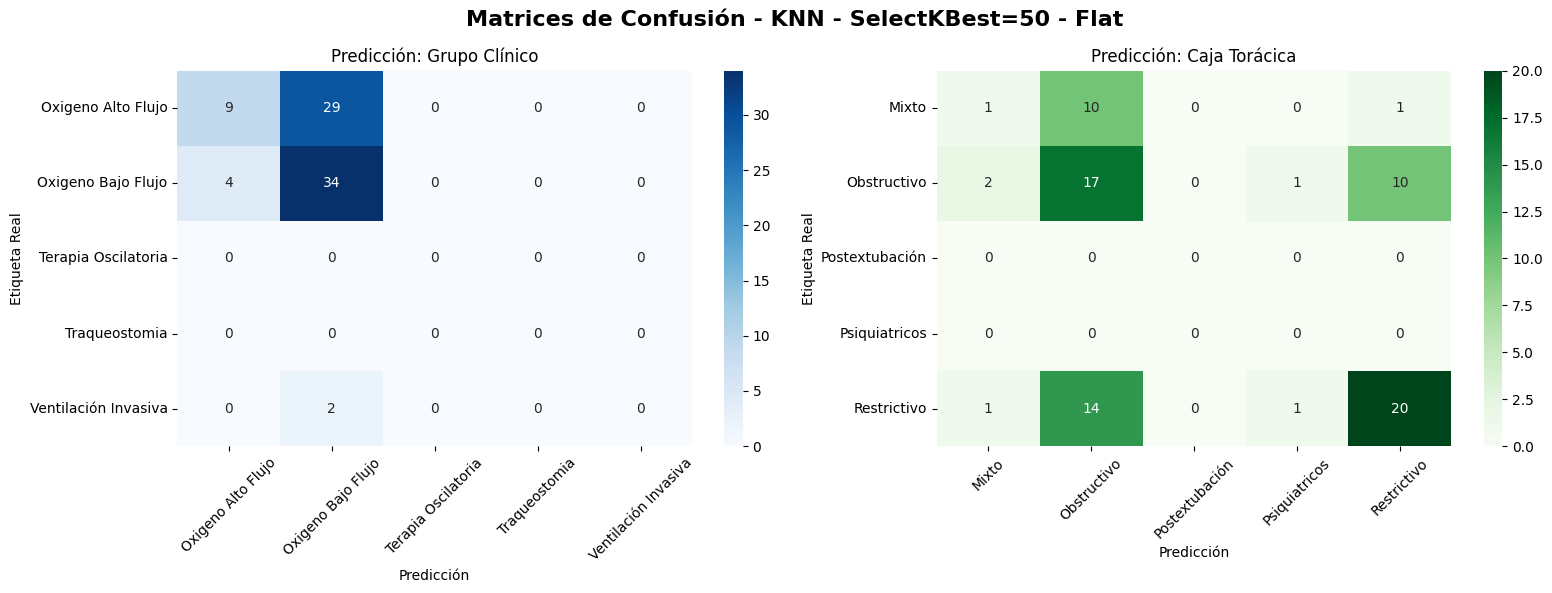

In [170]:
param_grid_knn_2_minkowski = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'p': [1, 2, 3],
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_minkowski, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_minkowski, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_caja_selected, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_kbest_flat(
    grid_grupo=grid_knn_grupo, 
    grid_caja=grid_knn_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="KNN - SelectKBest=50 - Flat"
)

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.25001894 0.26670744 0.26672641        nan        nan        nan
 0.2769925  0.28652522 0.29339023]
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.2508432  0.24853338 0.24635484        nan        nan        nan
 0.25579893 0.26040815 0.26913682]
  warnings.warn(


Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 13, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 13, 'weights': 'uniform'}
GRUPOS -> Accuracy: 65.38% | F1-Score (Macro): 43.33%
CAJA TORÁCICA -> Accuracy: 52.56% | F1-Score (Macro): 32.14%


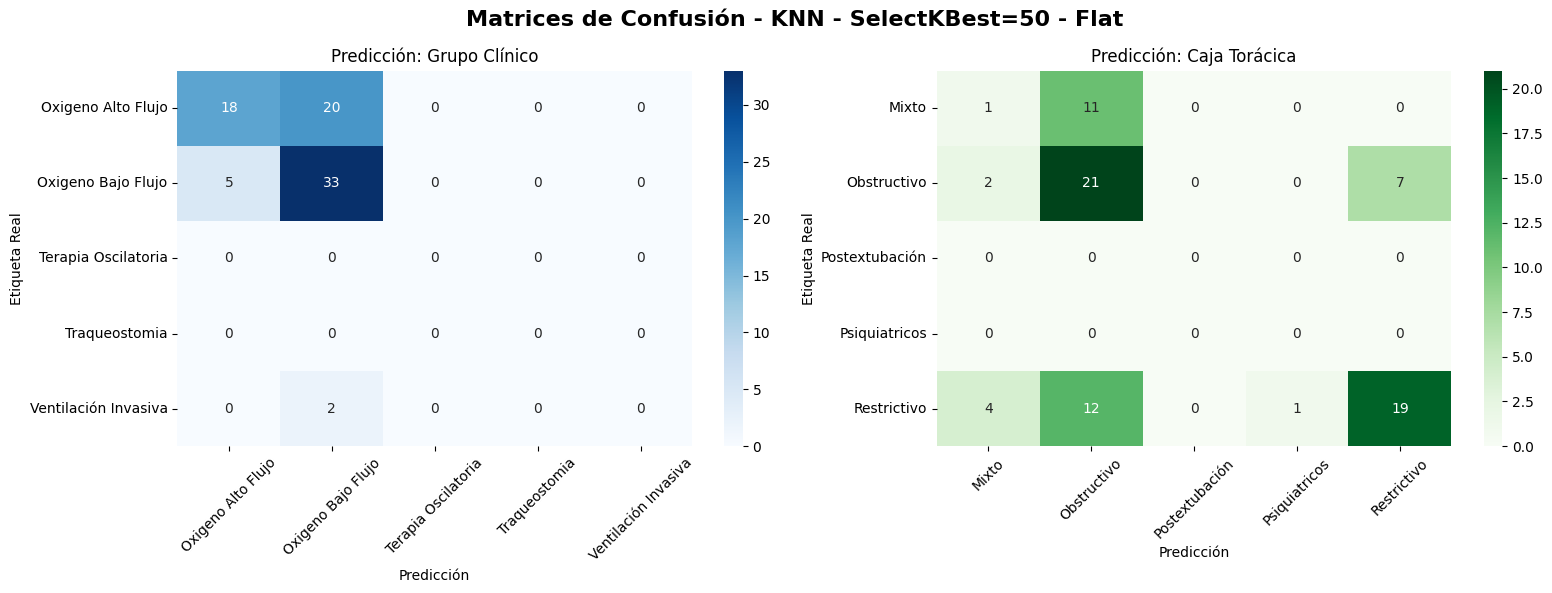

In [173]:
param_grid_knn_3_kbest_flat = {
    'n_neighbors': [9, 11, 13],   
    'weights': ['uniform'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_3_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_3_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_caja_selected, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_kbest_flat(
    grid_grupo=grid_knn_grupo, 
    grid_caja=grid_knn_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="KNN - SelectKBest=50 - Flat"
)

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.26672641 0.28836291 0.28342756        nan        nan        nan
 0.29339023 0.30102168 0.33351392]
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.24635484 0.25516078 0.26020853        nan        nan        nan
 0.26913682 0.3073109  0.30407758]
  warnings.warn(


Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 17, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 15, 'weights': 'uniform'}
GRUPOS -> Accuracy: 67.95% | F1-Score (Macro): 45.14%
CAJA TORÁCICA -> Accuracy: 57.69% | F1-Score (Macro): 46.22%


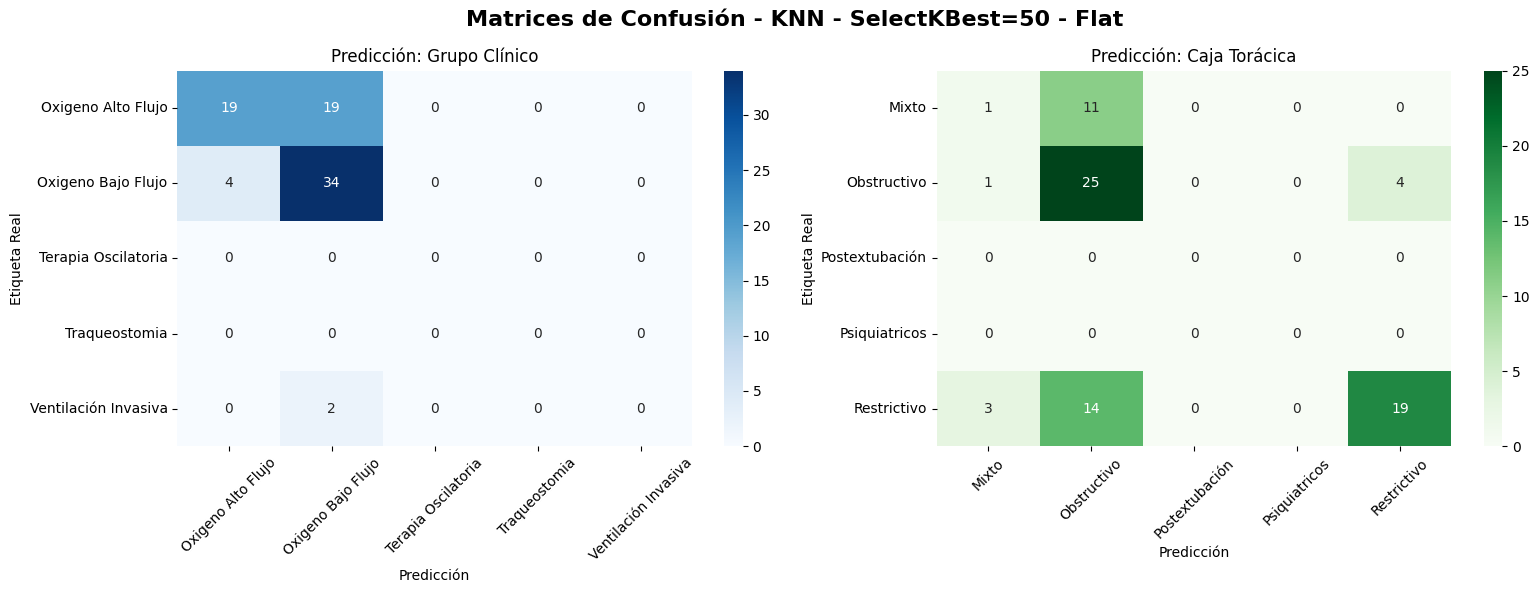

In [177]:
param_grid_knn_4_kbest_flat = {
    'n_neighbors': [13, 15, 17],   
    'weights': ['uniform'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_4_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_4_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_caja_selected, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_kbest_flat(
    grid_grupo=grid_knn_grupo, 
    grid_caja=grid_knn_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="KNN - SelectKBest=50 - Flat"
)

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.28836291 0.28342756 0.26584893        nan        nan        nan
 0.30102168 0.33351392 0.29950315]
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.25516078 0.26020853 0.26296935        nan        nan        nan
 0.3073109  0.30407758 0.29744722]
  warnings.warn(


Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 17, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 15, 'weights': 'uniform'}
GRUPOS -> Accuracy: 67.95% | F1-Score (Macro): 45.14%
CAJA TORÁCICA -> Accuracy: 57.69% | F1-Score (Macro): 46.22%


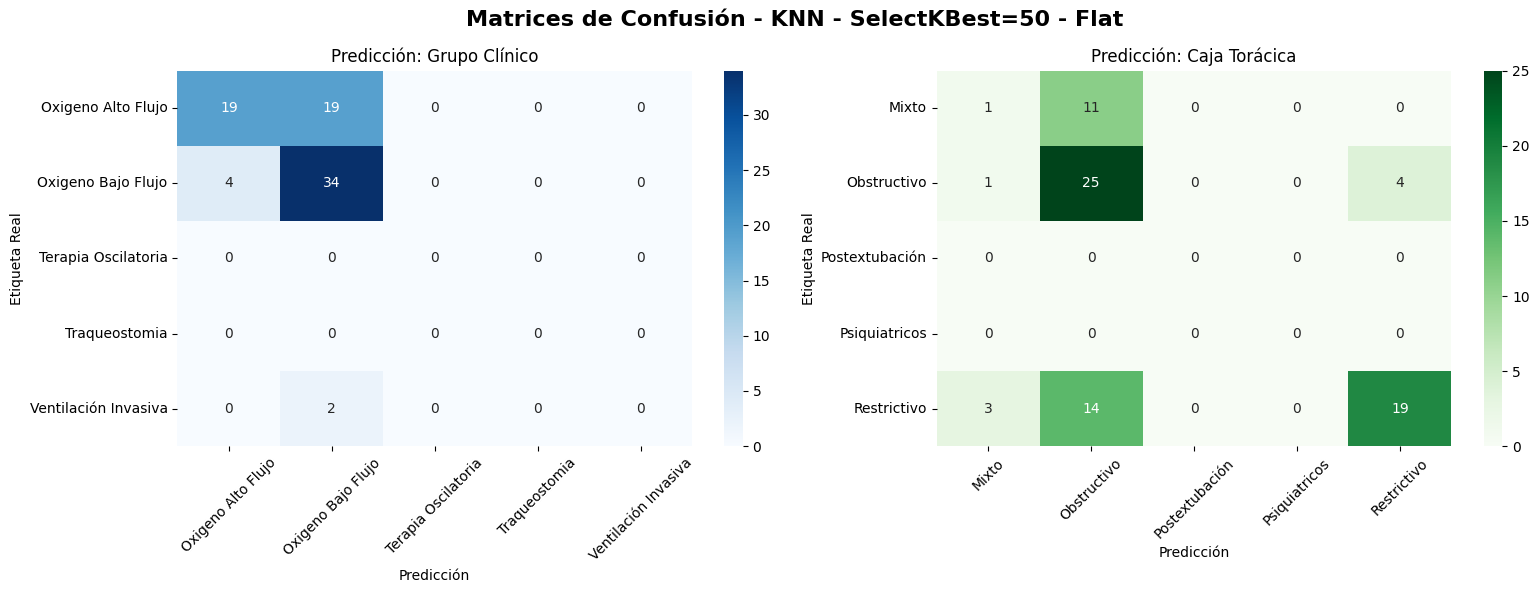

In [179]:
param_grid_knn_5_kbest_flat = {
    'n_neighbors': [15, 17, 19],   
    'weights': ['uniform'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_5_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_5_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_caja_selected, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_kbest_flat(
    grid_grupo=grid_knn_grupo, 
    grid_caja=grid_knn_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="KNN - SelectKBest=50 - Flat"
)

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 17, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 15, 'weights': 'uniform'}
GRUPOS -> Accuracy: 67.95% | F1-Score (Macro): 45.14%
CAJA TORÁCICA -> Accuracy: 57.69% | F1-Score (Macro): 46.22%


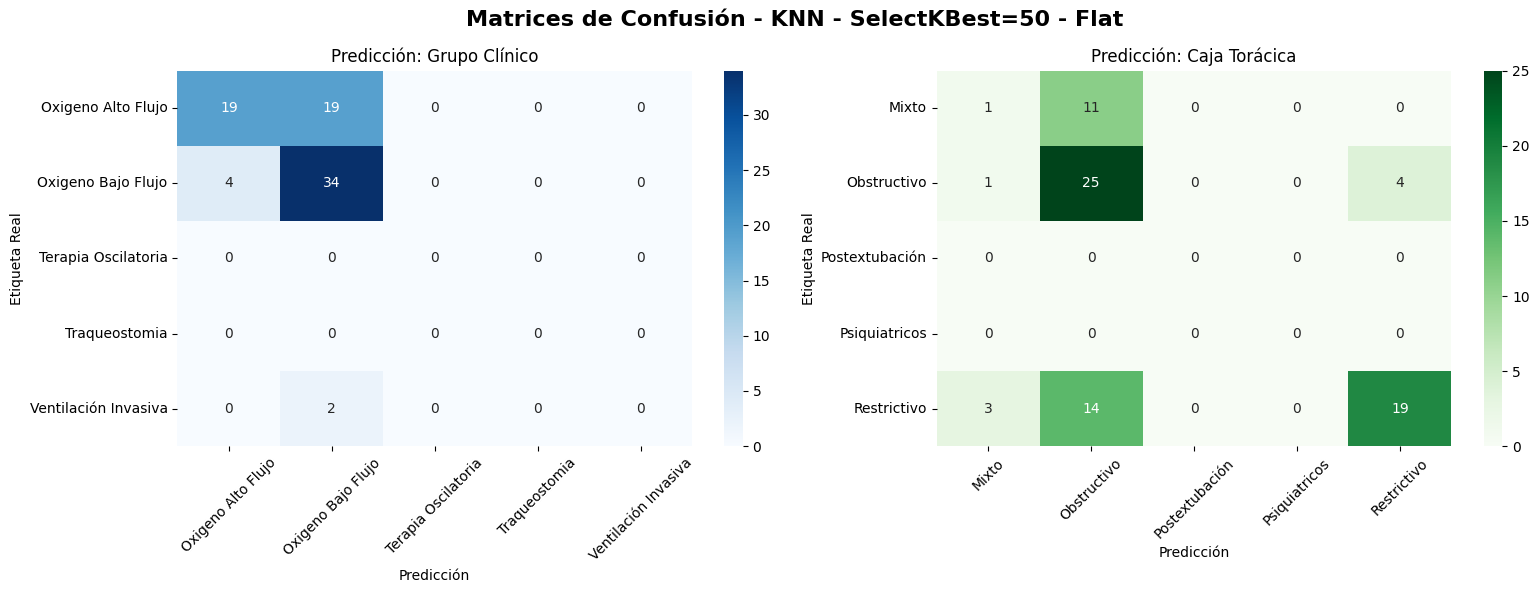

In [181]:
param_grid_knn_final_grupo_kbest_flat = {
    'n_neighbors': [17],   
    'weights': ['uniform'],     
    'metric': ['cosine'], 
    'algorithm': ['auto']                   
}

param_grid_knn_final_caja_kbest_flat = {
    'n_neighbors': [15],   
    'weights': ['uniform'],     
    'metric': ['cosine'], 
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_final_grupo_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_final_caja_kbest_flat, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_caja_selected, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_kbest_flat(
    grid_grupo=grid_knn_grupo, 
    grid_caja=grid_knn_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="KNN - SelectKBest=50 - Flat"
)

### Extracción Características + Modelos DF_POOL

El dataset pooleado (mean+std) tiene 60 características por muestra. Con 4296 muestras de entrenamiento, la relación 4296/60 ≈ 72:1 es excelente. Aplicamos el mismo análisis de correlación que en el notebook anterior para eliminar características redundantes antes del entrenamiento.

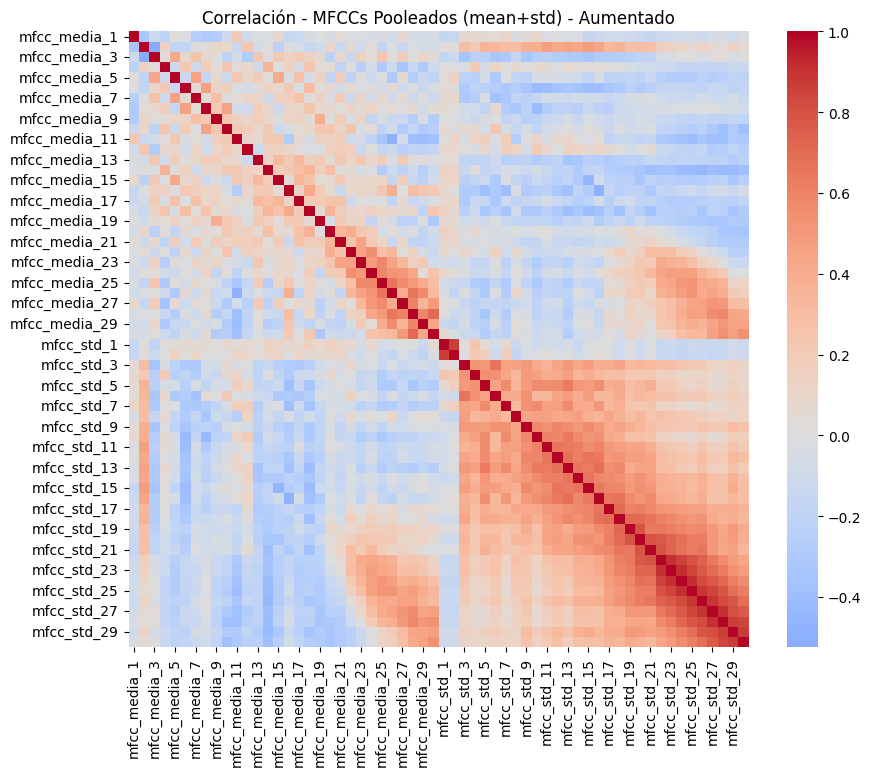

In [184]:
columnas_a_quitar = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

X_train = df_train_pool.drop(columns=columnas_a_quitar)

corr_matrix = X_train.corr()

def plot_corr(df, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), cmap='coolwarm', center=0)
    plt.title(f"Correlación - {title}")
    plt.show()

plot_corr(X_train, "MFCCs Pooleados (mean+std) - Aumentado")

In [186]:
columnas_correlacionadas = [f'mfcc_std_{i}' for i in range(1, 31)]
X_correlacionado = X_train[columnas_correlacionadas]

umbral = 0.8
matriz_corr_sub = X_correlacionado.corr()
for i in range(len(matriz_corr_sub.columns)):
    for j in range(i):
        col1 = matriz_corr_sub.columns[i]
        col2 = matriz_corr_sub.columns[j]
        correlacion = matriz_corr_sub.iloc[i, j]
        if correlacion >= umbral:
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")

mfcc_std_2 y mfcc_std_1 -> Correlación: 0.871
mfcc_std_23 y mfcc_std_22 -> Correlación: 0.910
mfcc_std_24 y mfcc_std_22 -> Correlación: 0.855
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.911
mfcc_std_25 y mfcc_std_22 -> Correlación: 0.803
mfcc_std_25 y mfcc_std_23 -> Correlación: 0.842
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.912
mfcc_std_26 y mfcc_std_24 -> Correlación: 0.829
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.896
mfcc_std_27 y mfcc_std_25 -> Correlación: 0.845
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.904
mfcc_std_28 y mfcc_std_26 -> Correlación: 0.824
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.910
mfcc_std_29 y mfcc_std_27 -> Correlación: 0.804
mfcc_std_29 y mfcc_std_28 -> Correlación: 0.865
mfcc_std_30 y mfcc_std_28 -> Correlación: 0.841
mfcc_std_30 y mfcc_std_29 -> Correlación: 0.876


Con esto podemos ver que hay muchas características que tienen más del 80% de correlación, sin embargo, muy pocas son las que superan el 85% y solo una pareja supera el 90%. En este caso, vamos a eliminar aquellas características que superen el 88% de correlación, tratándose de un valor elevado que nos permite reducir la redundancia entre características altamente correlacionadas sin perder información relevante. De este modo, mantenemos la mayor parte de la varianza del espacio original mientras eliminamos únicamente aquellos pares de características que aportan información prácticamente idéntica al modelo.

In [189]:
umbral = 0.88
pares_a_eliminar = set()

matriz_correlacion = X_train.corr()
for i in range(len(matriz_correlacion.columns)):
    for j in range(i):
        if abs(matriz_correlacion.iloc[i, j]) > umbral:
            col1 = matriz_correlacion.columns[i]
            col2 = matriz_correlacion.columns[j]
            correlacion = matriz_correlacion.iloc[i, j]
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")
            pares_a_eliminar.add(col1)

print("Columnas a eliminar: ")
print(f"{list(pares_a_eliminar)}. Número total = {len(pares_a_eliminar)}")

X_pool_reducido_train = df_train_pool.drop(columns=pares_a_eliminar)
X_pool_reducido_test = df_test_pool.drop(columns=pares_a_eliminar)

mfcc_std_23 y mfcc_std_22 -> Correlación: 0.910
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.911
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.912
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.896
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.904
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.910
Columnas a eliminar: 
['mfcc_std_25', 'mfcc_std_23', 'mfcc_std_27', 'mfcc_std_28', 'mfcc_std_24', 'mfcc_std_26']. Número total = 6


In [191]:
X_pool_reducido_train.head()

,nombre_archivo,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_29,mfcc_std_30
0,Nueva grabación 35_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,4,-395.698486,128.222198,14.744736,22.322180,-2.179186,-0.845055,...,8.078905,8.287786,8.140413,7.223814,7.031062,7.511176,7.103552,6.590400,6.290308,6.236594
1,Nueva grabación 35_chunk000_noise.wav,Oxigeno Bajo Flujo,Mixto,4,-349.371521,82.583366,32.257183,14.513069,2.653023,-2.802412,...,7.244800,7.846448,7.430649,6.574059,6.613079,7.107586,6.699980,6.439157,5.912968,5.922698
2,Nueva grabación 35_chunk000_pitch.wav,Oxigeno Bajo Flujo,Mixto,4,-418.692780,125.661049,12.638062,17.953672,-5.898654,-0.409212,...,8.740737,7.726729,7.640764,8.078515,7.727838,7.607847,6.740312,6.876270,6.572535,6.298157
3,Nueva grabación 35_chunk000_stretch.wav,Oxigeno Bajo Flujo,Mixto,4,-371.298523,112.905235,12.231887,20.830603,-1.896685,0.429273,...,7.918422,8.512799,7.500462,6.699999,6.781077,7.336614,7.273946,6.445476,6.100350,5.932369
4,Nueva grabación 35_chunk001_original.wav,Oxigeno Bajo Flujo,Mixto,4,-428.804565,153.596039,17.333982,19.624706,-11.297787,-2.113888,...,9.049528,8.386795,7.746877,7.247444,7.059894,7.692535,7.388308,7.013628,6.780205,6.246458


In [193]:
X_pool_reducido_test.head()

,nombre_archivo,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_29,mfcc_std_30
0,Asma obesidad grave vni planta_chunk000_origin...,Ventilación Invasiva,Obstructivo,-1,-347.397400,152.618591,-4.039340,15.344688,-7.147709,-0.646219,...,7.605196,7.272064,7.821987,7.489258,7.761950,8.026981,7.296615,7.711065,6.994778,7.767835
1,Asma obesidad grave vni planta_chunk001_origin...,Ventilación Invasiva,Obstructivo,-1,-332.255371,150.329376,-3.941954,21.230312,2.013347,1.089637,...,7.324610,7.708803,7.714882,7.541342,7.457639,7.277525,6.670105,7.070155,6.256960,6.571887
2,Epoc como respira_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,-1,-358.504883,134.448807,0.406959,16.095858,-2.650892,-0.984858,...,8.725971,9.953801,8.566394,7.991263,7.648769,7.963384,8.086514,7.624754,9.800405,9.690110
3,Nueva grabación 76_chunk000_original.wav,Oxigeno Bajo Flujo,Obstructivo,-1,-366.050720,158.790939,-11.541658,14.499003,-0.010558,-12.866081,...,9.663675,10.773755,8.581936,8.412956,9.595214,8.443722,7.737652,7.865307,7.661274,6.637980
4,Nueva grabación 76_chunk001_original.wav,Oxigeno Bajo Flujo,Obstructivo,-1,-369.023071,180.118225,-6.522571,16.260241,-2.599682,-12.724264,...,9.664040,11.854156,9.160444,9.561069,9.515260,8.416350,7.832928,8.284902,6.356392,6.561508


En este caso, contamos con un número reducido de características con el que trabajar directamente, por lo que pasaremos al entrenamiento de modelos sin reducción adicional.

#### Entrenamiento de Modelos.

In [197]:
columnas_num = [col for col in X_pool_reducido_train.columns if 'mfcc' in col]

X_train_model = X_pool_reducido_train[columnas_num]
X_test_model = X_pool_reducido_test[columnas_num]

y_train_grupo = df_train_pool['grupo']
y_test_grupo = df_test_pool['grupo']

y_train_caja = df_train_pool['caja_toracica']
y_test_caja = df_test_pool['caja_toracica']

folds_oficiales = df_train_pool['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

def evaluar_modelo_pool(grid_grupo, grid_caja, nombre_modelo):
    print(f"Mejores Hiperparámetros para Grupo Clínico: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros para Torácica: {grid_caja.best_params_}")

    pred_grupo = grid_grupo.predict(X_test_model)
    pred_caja = grid_caja.predict(X_test_model)

    acc_grupo = accuracy_score(y_test_grupo, pred_grupo)
    f1_grupo = f1_score(y_test_grupo, pred_grupo, average='macro', zero_division=0)
    print(f"GRUPOS -> Accuracy: {acc_grupo*100:.2f}% | F1-Score (Macro): {f1_grupo*100:.2f}%")

    acc_caja = accuracy_score(y_test_caja, pred_caja)
    f1_caja = f1_score(y_test_caja, pred_caja, average='macro', zero_division=0)
    print(f"CAJA TORÁCICA -> Accuracy: {acc_caja*100:.2f}% | F1-Score (Macro): {f1_caja*100:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Matrices de Confusión - {nombre_modelo}', fontsize=16, fontweight='bold')

    cm_grupo = confusion_matrix(y_test_grupo, pred_grupo, labels=grid_grupo.classes_)
    sns.heatmap(cm_grupo, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=grid_grupo.classes_, yticklabels=grid_grupo.classes_)
    axes[0].set_title('Predicción: Grupo Clínico')
    axes[0].set_ylabel('Etiqueta Real')
    axes[0].set_xlabel('Predicción')
    axes[0].tick_params(axis='x', rotation=45)

    cm_caja = confusion_matrix(y_test_caja, pred_caja, labels=grid_caja.classes_)
    sns.heatmap(cm_caja, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=grid_caja.classes_, yticklabels=grid_caja.classes_)
    axes[1].set_title('Predicción: Caja Torácica')
    axes[1].set_ylabel('Etiqueta Real')
    axes[1].set_xlabel('Predicción')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

##### Random Forest

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 46.15% | F1-Score (Macro): 21.05%
CAJA TORÁCICA -> Accuracy: 37.18% | F1-Score (Macro): 26.40%


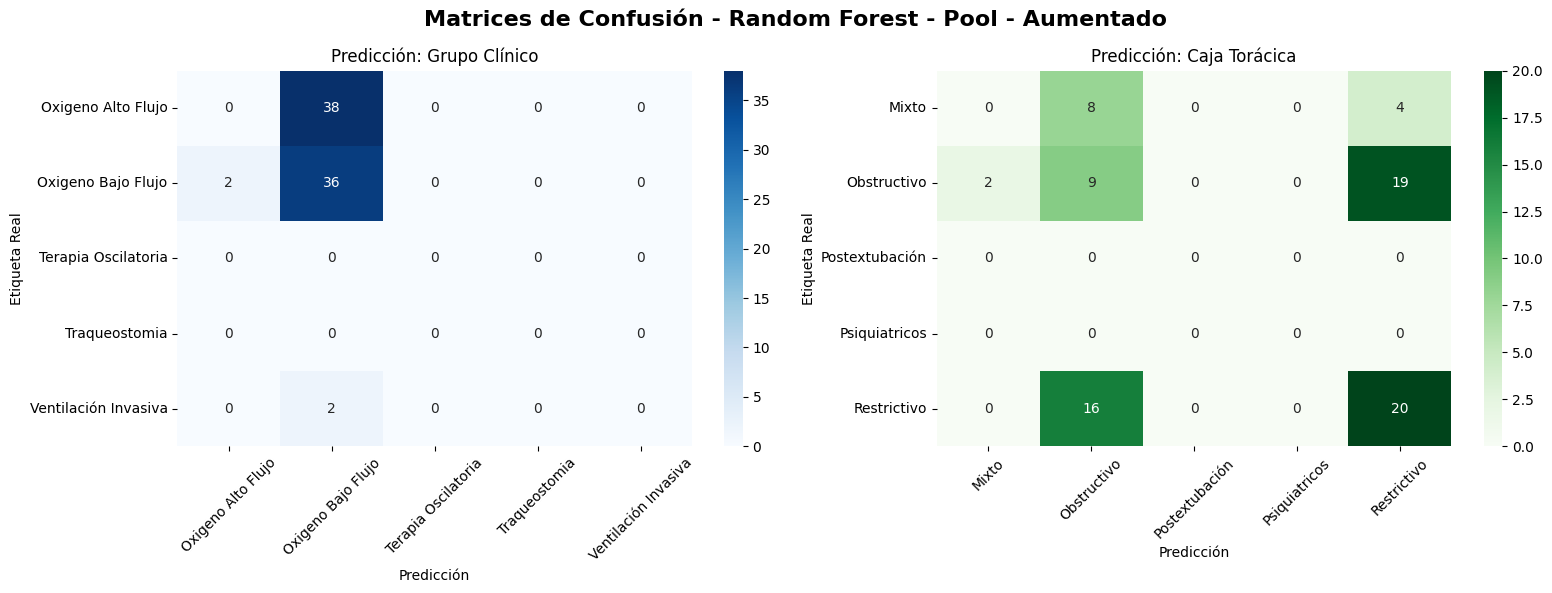

In [200]:
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
GRUPOS -> Accuracy: 50.00% | F1-Score (Macro): 26.27%
CAJA TORÁCICA -> Accuracy: 34.62% | F1-Score (Macro): 24.92%


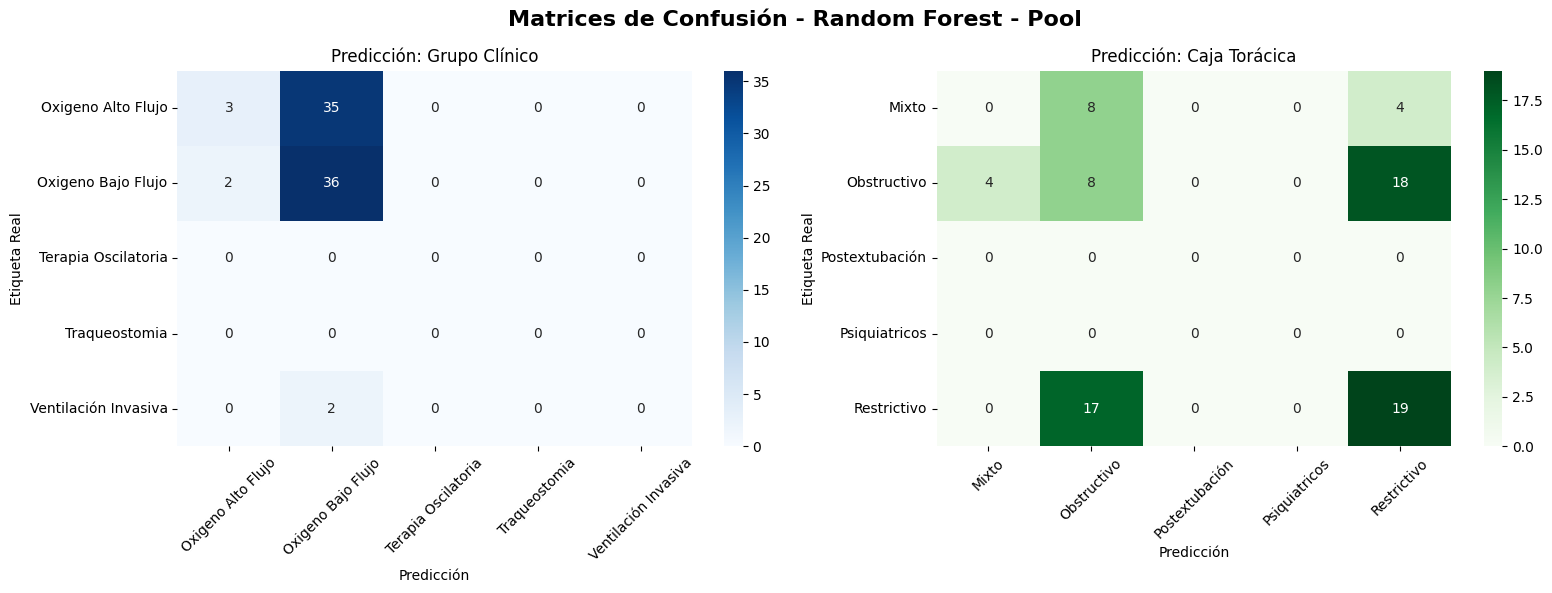

In [201]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
GRUPOS -> Accuracy: 50.00% | F1-Score (Macro): 26.27%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 23.72%


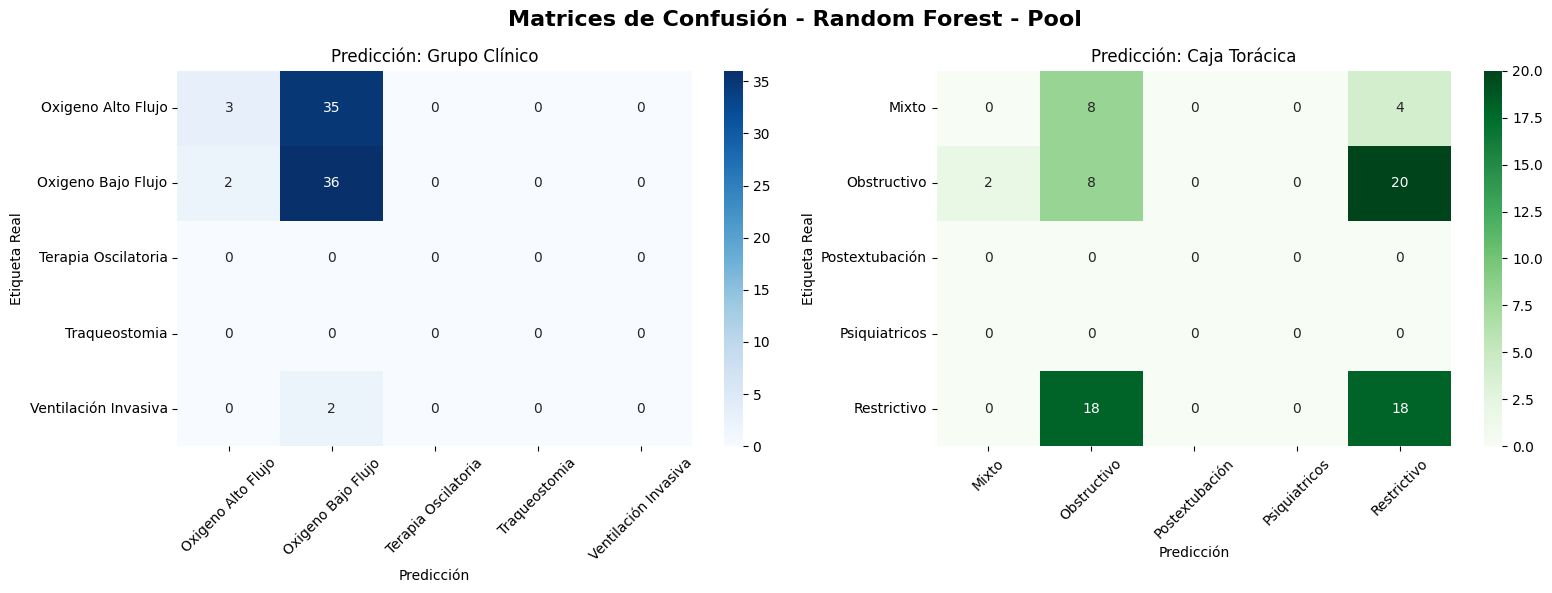

In [204]:
param_grid_rf_2 = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
GRUPOS -> Accuracy: 50.00% | F1-Score (Macro): 26.27%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 23.72%


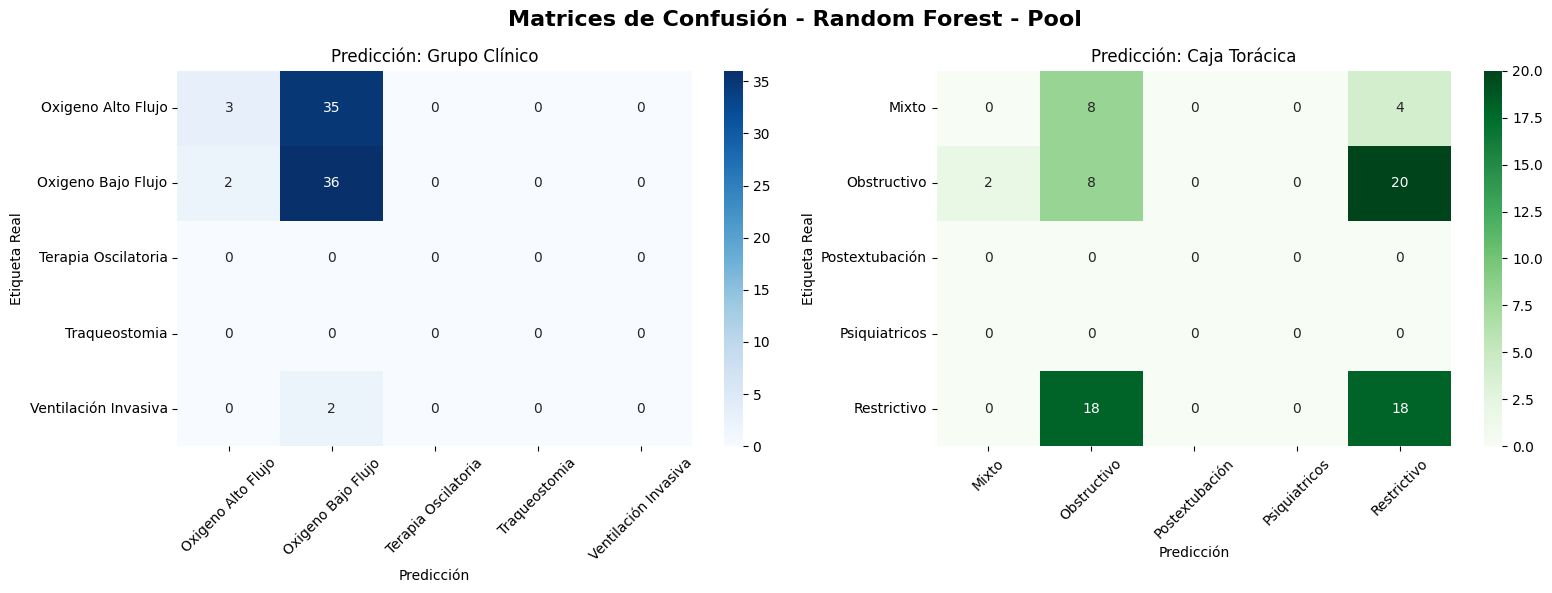

In [206]:
param_grid_rf_3_grupo_pool = {
    'n_estimators': [100, 200, 300],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [2, 8],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_3_caja_pool = {
    'n_estimators': [100, 200, 300],      
    'max_depth': [None],        
    'min_samples_split': [5, 8],   
    'min_samples_leaf': [2, 8],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_3_grupo_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_3_caja_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 50.00% | F1-Score (Macro): 26.27%
CAJA TORÁCICA -> Accuracy: 37.18% | F1-Score (Macro): 26.40%


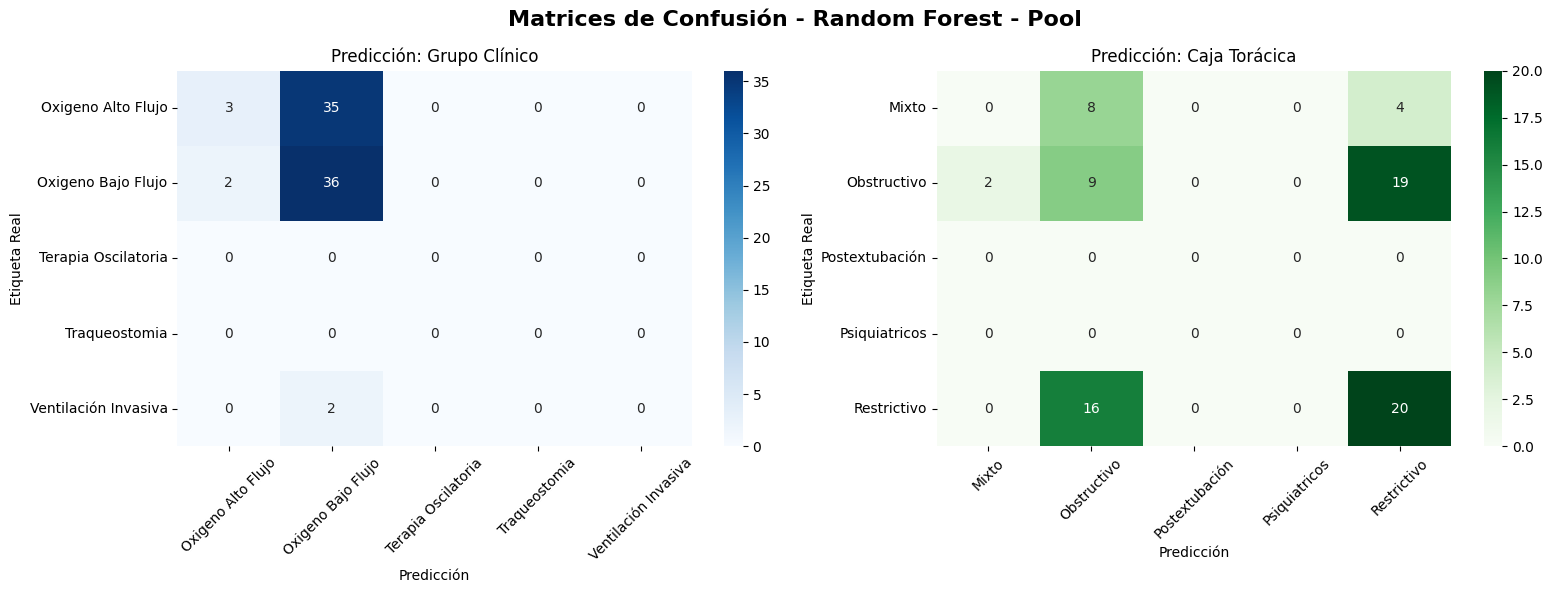

In [208]:
param_grid_rf_final_grupo_pool = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_final_caja_pool = {
     'n_estimators': [100],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'bootstrap': [True]  
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool")

##### SVM

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 12.82% | F1-Score (Macro): 8.11%
CAJA TORÁCICA -> Accuracy: 44.87% | F1-Score (Macro): 32.28%


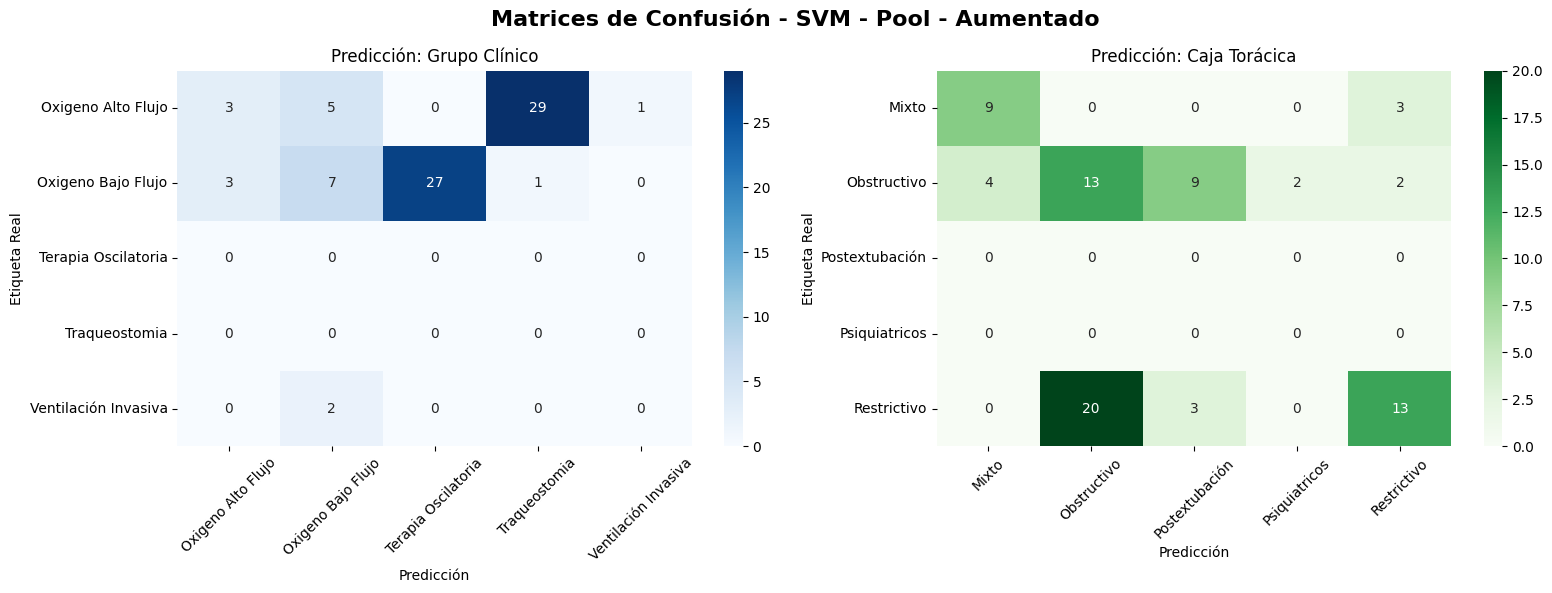

In [211]:
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_model, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 15.38% | F1-Score (Macro): 9.54%
CAJA TORÁCICA -> Accuracy: 43.59% | F1-Score (Macro): 31.49%


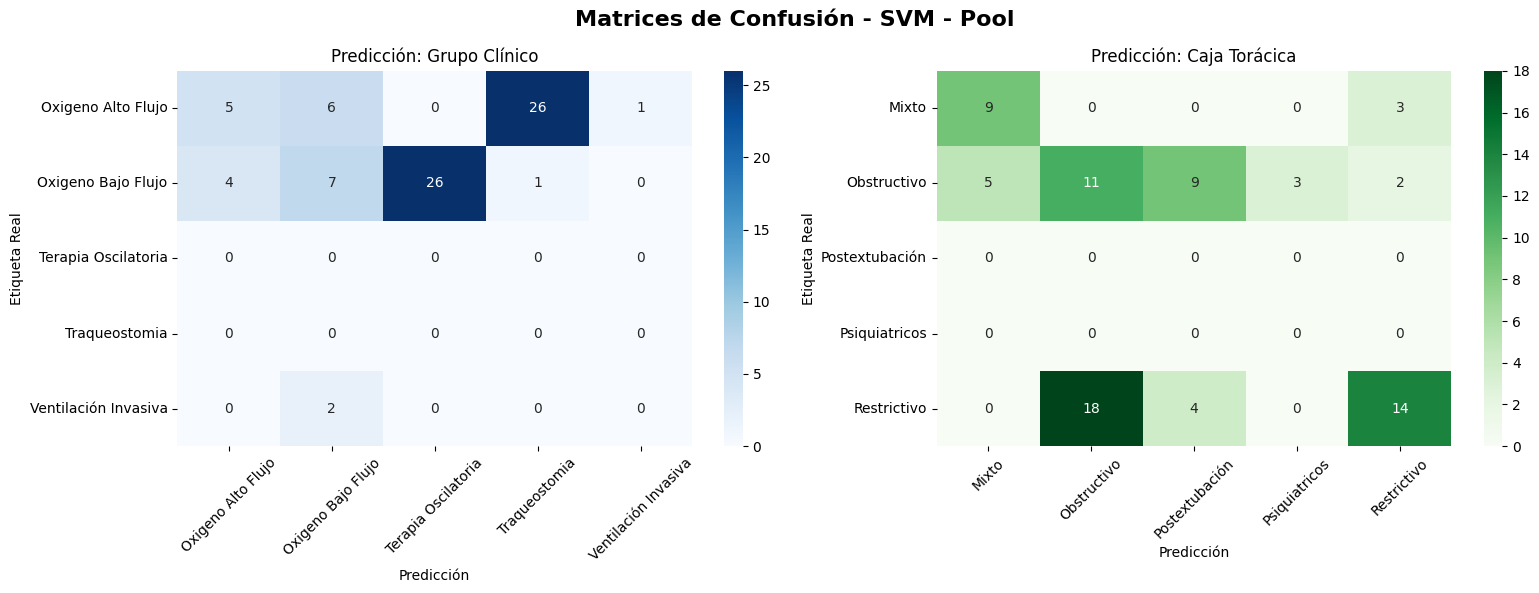

In [212]:
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_model, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool")

Rendimiento malo con svm, pasamos directamente a LGBM

##### LightGBM

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 53.85% | F1-Score (Macro): 19.42%
CAJA TORÁCICA -> Accuracy: 34.62% | F1-Score (Macro): 19.54%


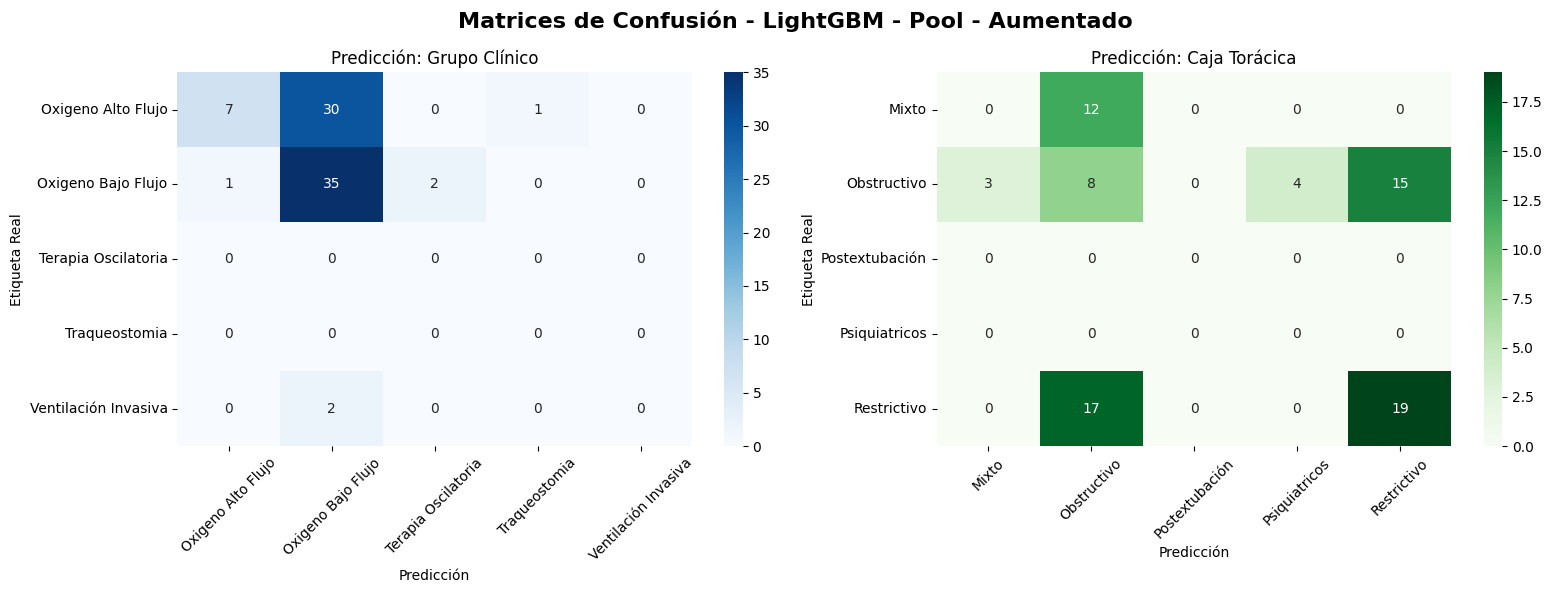

In [215]:
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_model, y_train_grupo)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.05, 'max_depth': 10, 'min_child_samples': 50, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 51.28% | F1-Score (Macro): 18.77%
CAJA TORÁCICA -> Accuracy: 34.62% | F1-Score (Macro): 15.86%


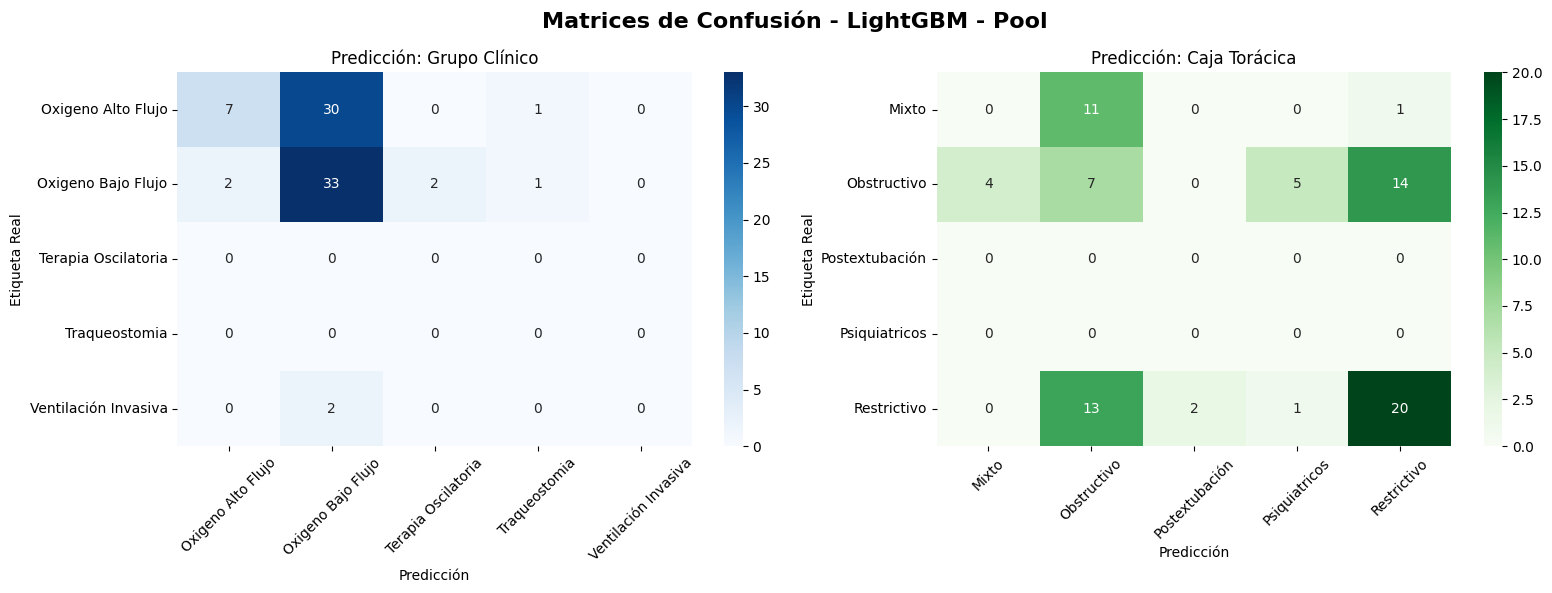

In [216]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_model, y_train_grupo)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 51.28% | F1-Score (Macro): 18.77%
CAJA TORÁCICA -> Accuracy: 35.90% | F1-Score (Macro): 20.74%


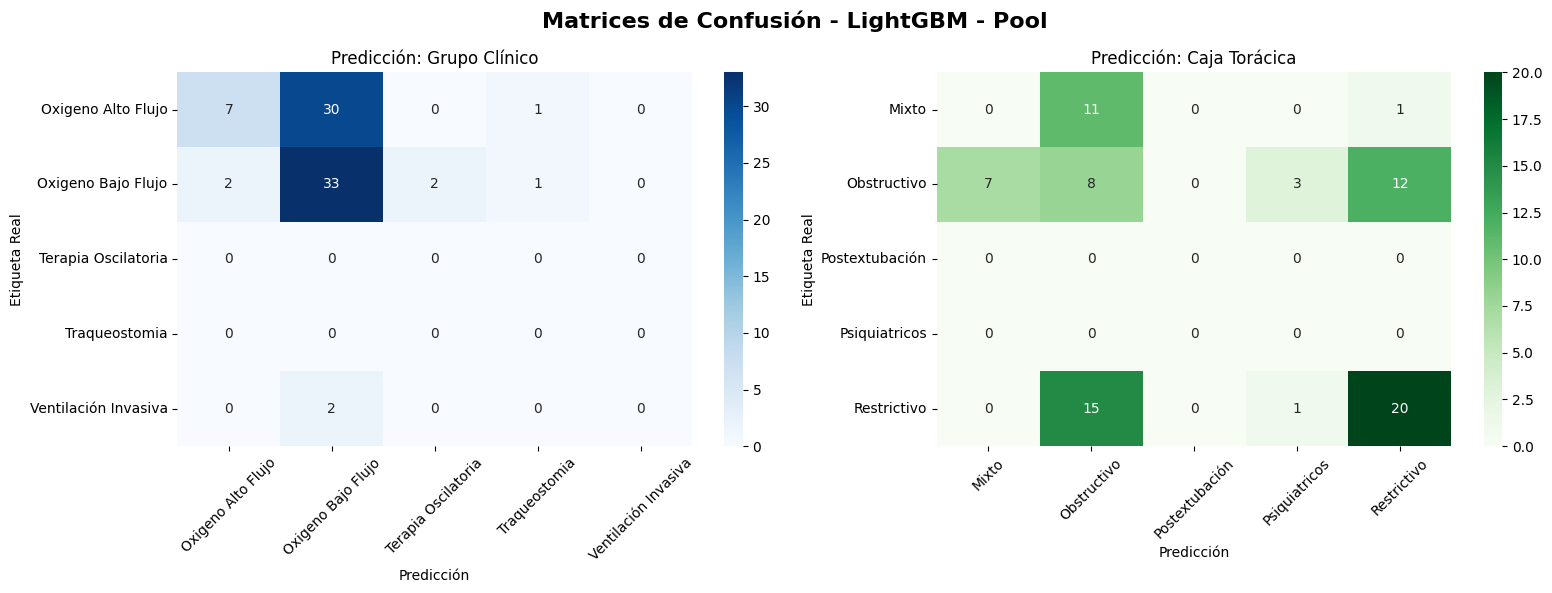

In [219]:
param_grid_lgbm_2 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1],
    'min_child_samples': [20, 50]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_model, y_train_grupo)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 53.85% | F1-Score (Macro): 19.42%
CAJA TORÁCICA -> Accuracy: 35.90% | F1-Score (Macro): 20.74%


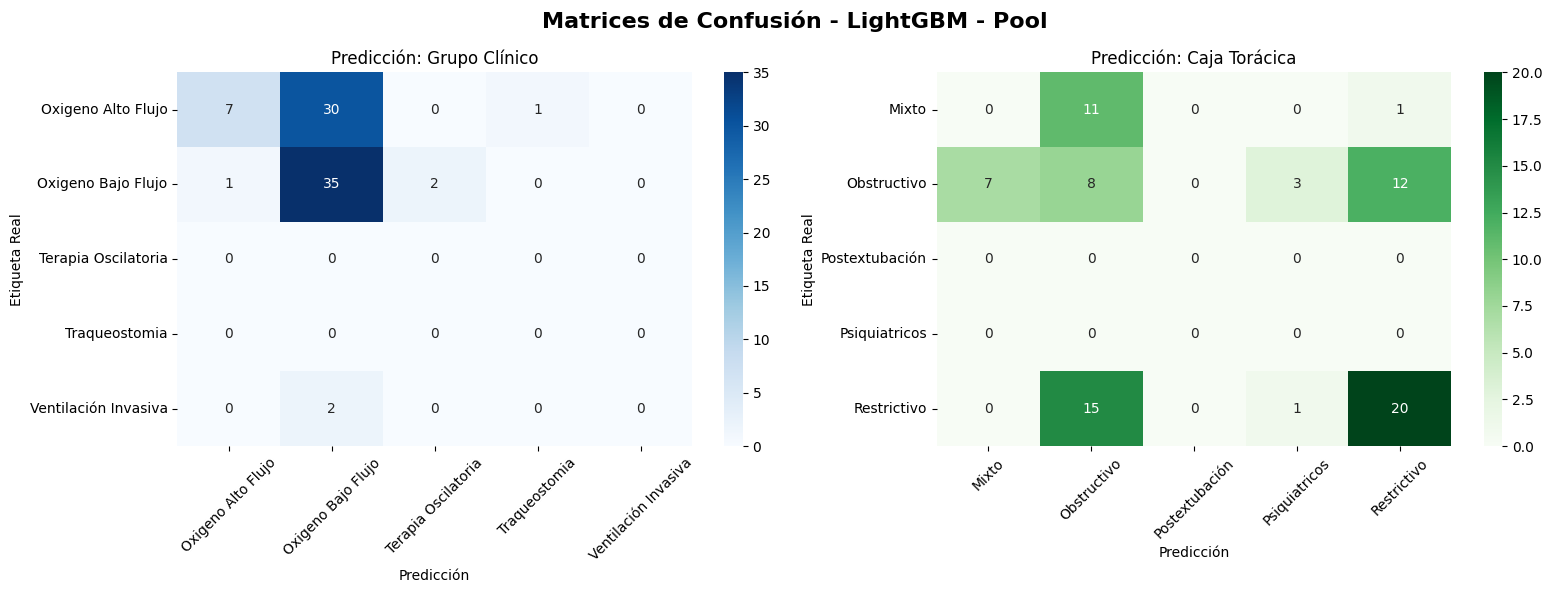

In [221]:
param_grid_lgbm_final_grupo_pool = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

param_grid_lgbm_final_caja_pool = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [50]
}

lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_grupo_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_grupo.fit(X_train_model, y_train_grupo)

lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_caja_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_lgbm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool")

##### KNN

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 66.67% | F1-Score (Macro): 43.85%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 21.63%


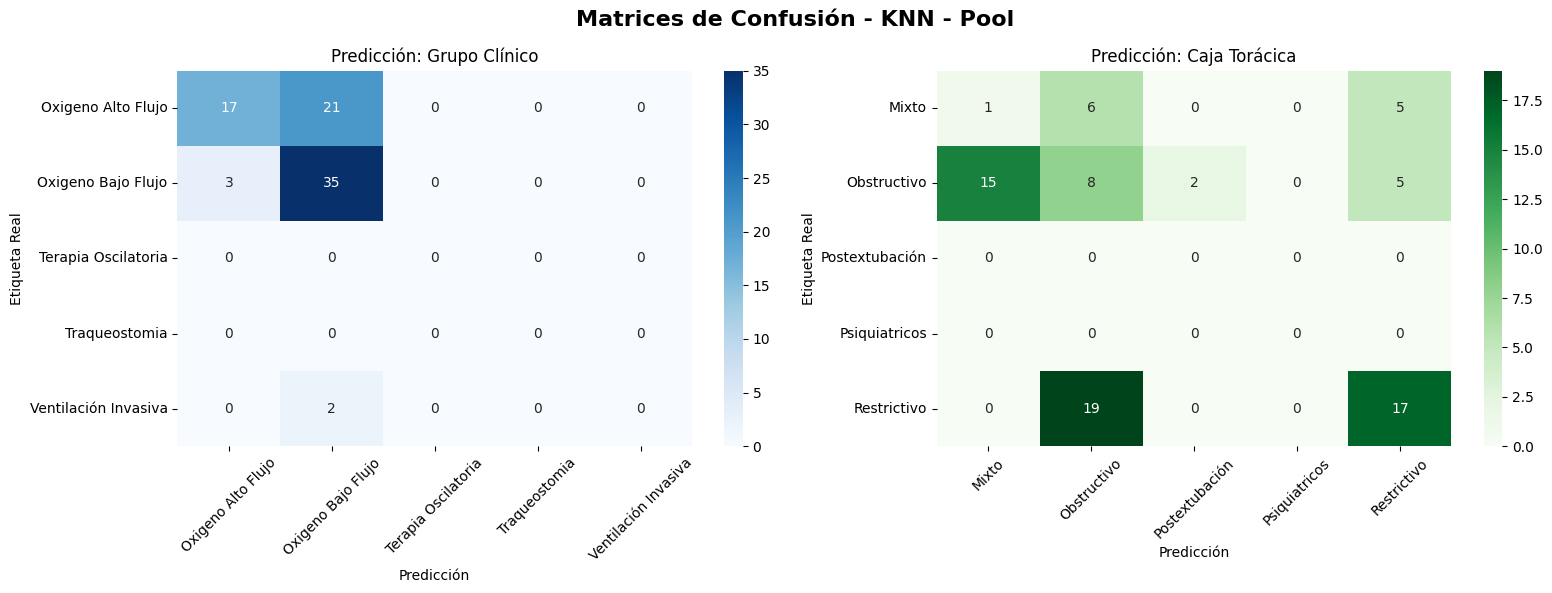

In [224]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_model, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_model, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 9, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
GRUPOS -> Accuracy: 51.28% | F1-Score (Macro): 23.01%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 19.88%


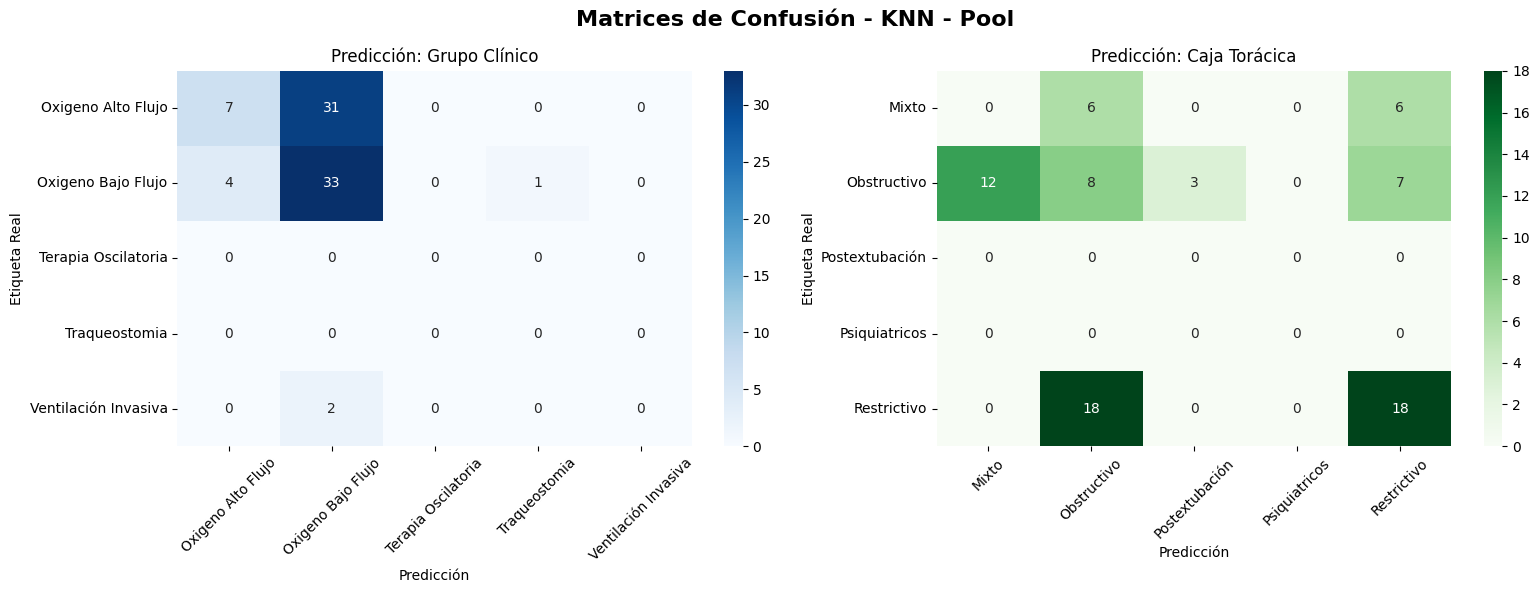

In [227]:
param_grid_knn_2_pool = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_model, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_model, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 3, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 2, 'weights': 'distance'}
GRUPOS -> Accuracy: 62.82% | F1-Score (Macro): 40.54%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 19.88%


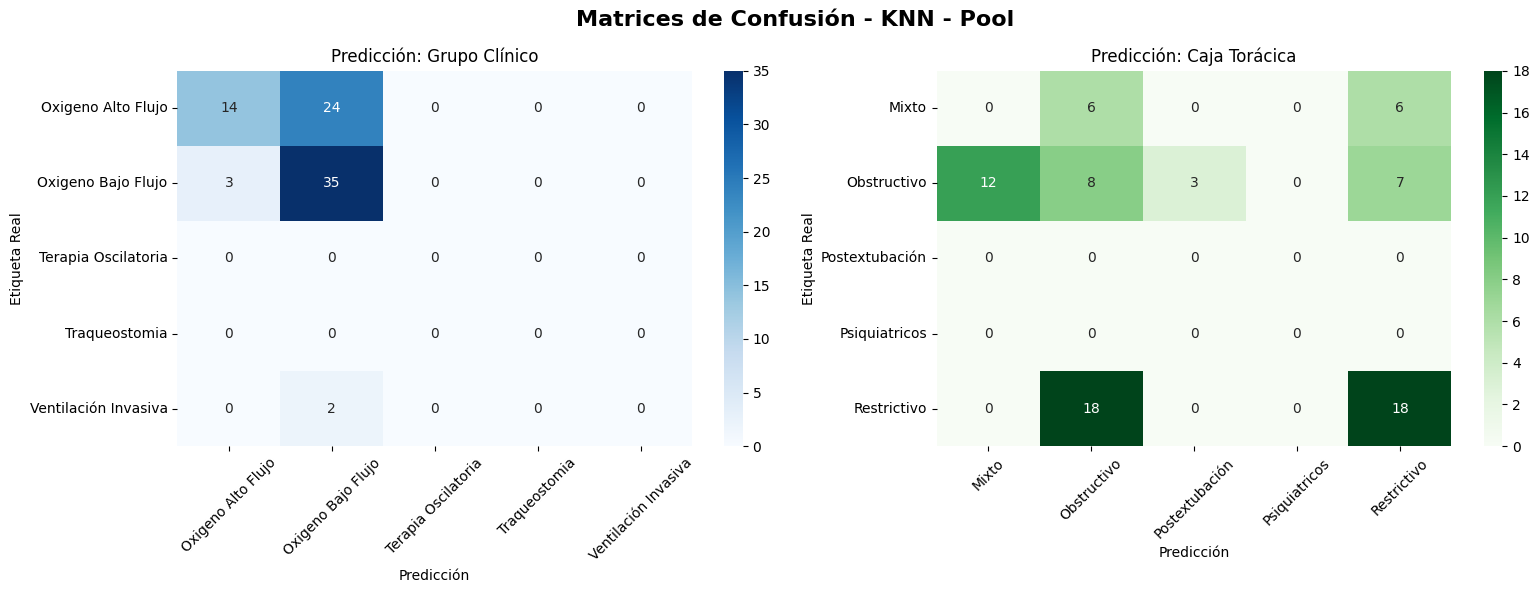

In [229]:
param_grid_knn_2_minkowski_pool = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'p': [1, 2, 3],
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_minkowski_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_model, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_minkowski_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_model, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 11, 'p': 3, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 61.54% | F1-Score (Macro): 39.38%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 21.63%


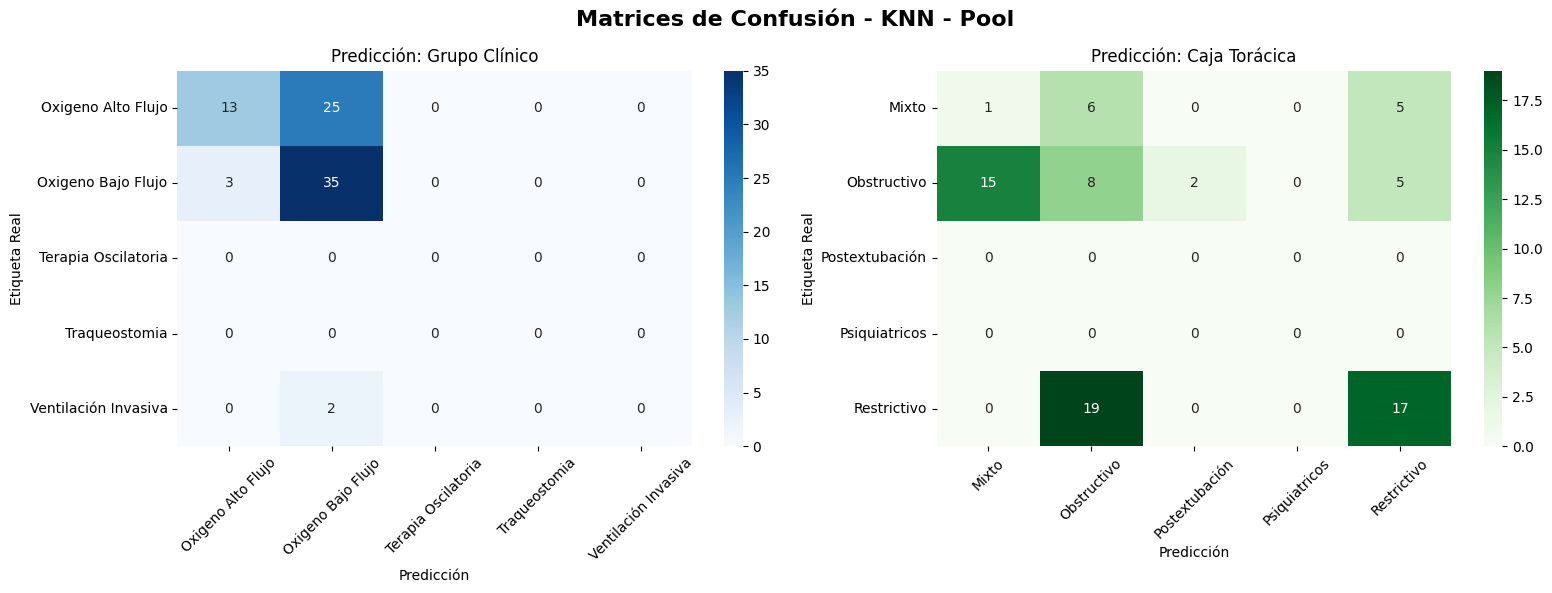

In [233]:
param_grid_knn_3_grupo_pool = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [9, 11],   
    'weights': ['uniform', 'distance'],     
    'p': [2, 3],
    'algorithm': ['auto']                   
}

param_grid_knn_final_caja_pool = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_3_grupo_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_model, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_final_caja_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_model, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 3, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 62.82% | F1-Score (Macro): 40.54%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 21.63%


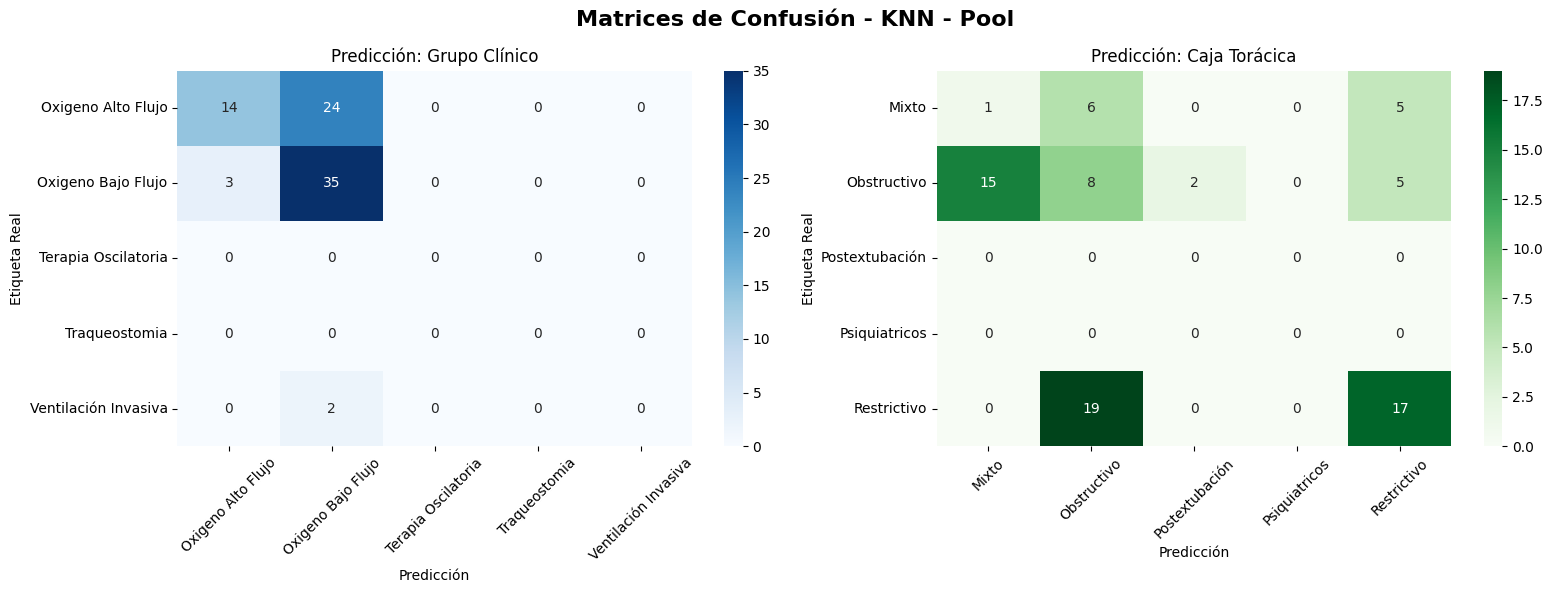

In [236]:
param_grid_knn_final_grupo_pool = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [9],   
    'weights': ['uniform'],     
    'p': [3],
    'algorithm': ['auto']                   
}

param_grid_knn_final_caja_pool = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

# Entrenamos para el objetivo de Grupo Clínico
knn_base_grupo = KNeighborsClassifier()
grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_final_grupo_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_grupo.fit(X_train_model, y_train_grupo)

# Entrenamos para el objetivo de Caja Torácica
knn_base_caja = KNeighborsClassifier()
grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_final_caja_pool, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_knn_caja.fit(X_train_model, y_train_caja)

# Evaluamos usando tu función personalizada
evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool")